## Introduction

General remarks on executing the code below:
- Section "data acquisition":
    - Requires an API key for the Manifesto project database. It can be obtained here: https://manifesto-project.wzb.eu/signup
    - Alternatively, this section can be skipped and the resulting data can be loaded from a local copy in the subsequent sections (in "data preparation" or "data exploration")
- Section "data preparation":
    - Requires a functional installation of spaCy and one of its NLP models (see imports below for instructions)
    - Alternatively, this section, too, can be skipped and the resulting data can be loaded from a local copy in the subsequent section ("data exploration")

### Imports

#### Standard imports

In [ ]:
# to analyse & visualise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import hyperscan # to speed up scanning for batches of patterns
from tqdm.notebook import tqdm # for progress tracking - we use the notebook version to allow for nested progress bars (outer + inner loops)
#
# to load/import external data
import os
from dotenv import load_dotenv
import requests
# import json
import rdata
import pickle

#### NLP imports

You can skip this if you want to load the pre-processed local copy of the manifesto texts

In [ ]:
# spaCy
import spacy # might need to check Python version
# the spaCy package comes without a model, it must be installed separately
# we focus on the german models (de) trained on news data (news), in the small (sm) and the large (lg) version
# !python -m spacy download de_core_news_sm 
# !python -m spacy download de_core_news_lg
#
# load spacy model
nlp_spacy_small = spacy.load("de_core_news_sm")
nlp_spacy_large = spacy.load("de_core_news_lg")
#
# transformer-based models
#
# german-sentiment-bert
# obtained either via `pip install germansentiment`; see https://github.com/oliverguhr/german-sentiment-lib?tab=readme-ov-file
# or via huggingface: https://huggingface.co/oliverguhr/german-sentiment-bert -> "use this model"
from germansentiment import SentimentModel
# throws got the following error: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html from .autonotebook import tqdm as notebook_tqdm
# tried: pip install ipywidgets and restarted the kernel -> solved the issue
from types import MethodType # to patch SentimentModel to use MPS instead of CPU on macOS
# for further transformer models from huggingface:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
import torch

#### Further setup notes

In [3]:
# run `pip install openpyxl` once in order to read in xlsx (Excel) files, such as the BAWL-R below

## Data acquisition: exploring the Manifesto project

### About the data source

We will use the [Manifesto projekt](https://manifesto-project.wzb.eu/) to obtain manifestos of different parties for different years. Other sources would be i) the parties themselves or ii) the Bundes-/Landeszentralen für politische Bildung. However, these often only provide formatted PDF documents. The Manifesto project, on the other hand, provides raw text versions with which we can work more easily.

Obtaining a specific manifesto requires some preparatory work. In particular, we first need to understand the structure of the Manifesto project database. Below, we use the following steps:

1) Version specification: for our queries, we will need to specify which version of the Manifesto project we want to access

    a) Get the version numbers of the core dataset

    b) Get the version numbers of the metadata (more on this below)

2) Core dataset: see which manifestos are available by party & election
3) Metadata dataset: for a party-election combination, get the manifesto ID by which we can then retreive the actual manifesto
4) Retreive the manifesto text

### Setup

In [7]:
# your .env file should have a line like this: manifesto_api_key="..."
api_manifesto = os.getenv('manifesto_api_key') # if dotenv does not work for you, replace this line with api_manifesto = "7a93a87b83fcaae8a3ae59590373696a" until it gets blocked...
url_manifesto_base = "https://manifesto-project.wzb.eu/api/v1/"
# for an overview of the different queries that we can append to this base, see: for an overview of the different queries, see: https://manifesto-project.wzb.eu/information/documents/api

### 1. a) Versioning of the core dataset

In [8]:
# we start with getting the versions of the manifesto, because specific requests will ask for naming the version
query = "list_core_versions" 
url = url_manifesto_base + query + "?api_key=" + api_manifesto
# submit the request & save the return
r = requests.get(url)
r # check whether we got a valid request, i.e. a response 200

<Response [200]>

In [9]:
# a look at the return
r.json()
# this lists the different manifesto versions. We are interested in the latest one, which we will use in our future requests

{'datasets': [{'id': 'MPDS2012a',
   'name': 'Manifesto Project Dataset (version 2012a)'},
  {'id': 'MPDS2012b', 'name': 'Manifesto Project Dataset (version 2012b)'},
  {'id': 'MPDS2013a', 'name': 'Manifesto Project Dataset (version 2013a)'},
  {'id': 'MPDS2013b', 'name': 'Manifesto Project Dataset (version 2013b)'},
  {'id': 'MPDS2014a', 'name': 'Manifesto Project Dataset (version 2014a)'},
  {'id': 'MPDS2014b', 'name': 'Manifesto Project Dataset (version 2014b)'},
  {'id': 'MPDS2015a', 'name': 'Manifesto Project Dataset (version 2015a)'},
  {'id': 'MPDS2016a', 'name': 'Manifesto Project Dataset (version 2016a)'},
  {'id': 'MPDS2016b', 'name': 'Manifesto Project Dataset (version 2016b)'},
  {'id': 'MPDS2017a', 'name': 'Manifesto Project Dataset (version 2017a)'},
  {'id': 'MPDS2017b', 'name': 'Manifesto Project Dataset (version 2017b)'},
  {'id': 'MPDS2018a', 'name': 'Manifesto Project Dataset (version 2018a)'},
  {'id': 'MPDS2018b', 'name': 'Manifesto Project Dataset (version 2018b)'

In [10]:
version_id_core = r.json()["datasets"][-1]["id"] # get the ID of the last item
version_id_core

'MPDS2025a'

### 1. b) Versioning of the metadata dataset

In [11]:
# the actual manifesto texts are stored in the metadata dataset, not in the core dataset
# hence, we will also need to specify the version of the metadata dataset we are interested in
# let's get a list of the different versions
query = "list_metadata_versions"
url = url_manifesto_base + query + "?api_key=" + api_manifesto
# in the next steps, we follow the procedure used to explore the CORE dataset versions
# we are only really interested in getting the correct version/id of the most recent metadata set
r = requests.get(url)
r.json()

{'versions': ['2015-1',
  '20150603140744',
  '20150603144655',
  '2015-2',
  '20150619183523',
  '20150708095326',
  '20150708102056',
  '2015-3',
  '20150716220651',
  '20150727144348',
  '20150914183516',
  '2015-4',
  '2015-5',
  '20151207125518',
  '20160205170254',
  '20160205171117',
  '20160205184152',
  '2016-1',
  '2016-2',
  '20160520191208',
  '20160524112135',
  '2016-3',
  '20160817112523',
  '20160817115608',
  '20160823133322',
  '2016-4',
  '2016-5',
  '20161128161012',
  '2016-6',
  '20170720161359',
  '2017-1',
  '20170815135004',
  '20171211135550',
  '2017-2',
  '2018-1',
  '2018-2',
  '2019-1',
  '2019-2',
  '2020-1',
  '2020-2',
  '2021-1',
  '2022-1',
  '2023-1',
  '2024-1',
  '2025-1']}

In [12]:
# get the latest version, i.e. the last element
metadata_versions = list(r.json().values())
version_id_metadata = metadata_versions[0][-1]
version_id_metadata

'2025-1'

### 2. The core dataset

#### Retreiving & exploring the core dataset

In [13]:
# from the API documentation, we learn that "get_core" is the command to explore the core dataset
query = "get_core"
url = url_manifesto_base + query + "?api_key=" + api_manifesto + "&key=" + version_id_core
r = requests.get(url)
r

<Response [200]>

In [14]:
# the core_data is a nested list of lists. we get a better idea by turning it into a dataframe
core_data = r.json()
# the first row contains the column names, so we use it accordingly
df_core = pd.DataFrame(core_data[1:], columns = core_data[0])
df_core

,country,countryname,oecdmember,eumember,edate,date,party,partyname,partyabbrev,parfam,...,per608_3,per703_1,per703_2,rile,planeco,markeco,welfare,intpeace,datasetversion,id_perm
0,11,Sweden,0,0,17/09/1944,194409,11220,Communist Party of Sweden,SKP,20,...,NA,NA,NA,9.6,1.9,1.9,0,1.9,2025a,JN1LZH
1,11,Sweden,0,0,17/09/1944,194409,11320,Social Democratic Labour Party,SAP,30,...,NA,NA,NA,-37.8,3.3,2.2,33.4,5.6,2025a,CMR7F6
2,11,Sweden,0,0,17/09/1944,194409,11420,People’s Party,FP,40,...,NA,NA,NA,9.5,3.2,6.4,14.3,1.6,2025a,Z6OL6C
3,11,Sweden,0,0,17/09/1944,194409,11620,Right Party,,60,...,NA,NA,NA,28,1.8,22.8,10.6,0,2025a,YMKVN2
4,11,Sweden,0,0,17/09/1944,194409,11810,Agrarian Party,,80,...,NA,NA,NA,23.81,0,19.048,0,4.762,2025a,U4SCRD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5280,181,South Africa,0,0,08/05/2019,201905,181510,African Christian Democratic Party,ACDP,50,...,0,5,0,12.5,0.833,7.5,14.167,0,2025a,HSQT6Y
5281,181,South Africa,0,0,08/05/2019,201905,181520,African Transformation Movement,ATM,50,...,0,1.042,0,-6.771,3.385,1.042,22.135,1.562,2025a,B6QCSE
5282,181,South Africa,0,0,08/05/2019,201905,181710,Freedom Front Plus,FF+,70,...,0,3.497,0,19.58,0.699,10.664,11.364,0,2025a,OS725O
5283,181,South Africa,0,0,08/05/2019,201905,181910,Inkatha Freedom Party,IFP,90,...,0,3.289,0,-6.579,0.658,0.658,28.947,0,2025a,XKM7J7


In [15]:
# there are MANY columns. Their full description is documented here: https://manifesto-project.wzb.eu/down/data/2024a/codebooks/codebook_MPDataset_MPDS2024a.pdf
# for the moment, we focus on country(name), party(name)/abbreviation, and the election date (edate).
print(df_core.columns.to_list())

['country', 'countryname', 'oecdmember', 'eumember', 'edate', 'date', 'party', 'partyname', 'partyabbrev', 'parfam', 'candidatename', 'coderid', 'manual', 'coderyear', 'testresult', 'testeditsim', 'pervote', 'voteest', 'presvote', 'absseat', 'totseats', 'progtype', 'datasetorigin', 'corpusversion', 'total', 'peruncod', 'per101', 'per102', 'per103', 'per104', 'per105', 'per106', 'per107', 'per108', 'per109', 'per110', 'per201', 'per202', 'per203', 'per204', 'per301', 'per302', 'per303', 'per304', 'per305', 'per401', 'per402', 'per403', 'per404', 'per405', 'per406', 'per407', 'per408', 'per409', 'per410', 'per411', 'per412', 'per413', 'per414', 'per415', 'per416', 'per501', 'per502', 'per503', 'per504', 'per505', 'per506', 'per507', 'per601', 'per602', 'per603', 'per604', 'per605', 'per606', 'per607', 'per608', 'per701', 'per702', 'per703', 'per704', 'per705', 'per706', 'per1011', 'per1012', 'per1013', 'per1014', 'per1015', 'per1016', 'per1021', 'per1022', 'per1023', 'per1024', 'per1025'

In [16]:
# which German parties are in the dataset?
df_core[df_core.countryname == "Germany"].partyabbrev.unique()
# note that this only means the respective party is listed at SOME point, i.e. for SOME election

array(['KPD', 'SPD', 'FDP', 'CDU/CSU', 'DZ', 'DP', 'WAV', 'DRP', 'BP',
       'SSW', 'GB/BHE', '', 'Greens/90', 'PDS', '90/Greens', 'L-PDS',
       'LINKE', 'AfD', 'BSW'], dtype=object)

In [17]:
# which German elections are in the dataset?
df_core[df_core.countryname == "Germany"].edate.unique()
# note these are Bundestag elections.
# also note those dates are do not yet have the correct dtype

array(['14/08/1949', '06/09/1953', '15/09/1957', '17/09/1961',
       '19/09/1965', '28/09/1969', '19/11/1972', '03/10/1976',
       '05/10/1980', '06/03/1983', '25/01/1987', '02/12/1990',
       '16/10/1994', '27/09/1998', '22/09/2002', '18/09/2005',
       '27/09/2009', '22/09/2013', '24/09/2017', '26/09/2021',
       '23/02/2025'], dtype=object)

In [18]:
# change date to dtime object 
df_core["edate"] = pd.to_datetime(df_core.edate, format = "%d/%m/%Y")

In [19]:
# for each election, get the parties that are part of the manifesto
# sort the by election date
df_core[df_core.countryname == "Germany"].sort_values("edate").groupby("edate").partyabbrev.unique()

edate
1949-08-14    [KPD, SPD, FDP, CDU/CSU, DZ, DP, WAV, DRP, BP,...
1953-09-06                  [GB/BHE, DP, DZ, FDP, SPD, CDU/CSU]
1957-09-15                              [SPD, FDP, CDU/CSU, DP]
1961-09-17                                  [SPD, FDP, CDU/CSU]
1965-09-19                                  [CDU/CSU, SPD, FDP]
1969-09-28                                  [CDU/CSU, SPD, FDP]
1972-11-19                                  [SPD, FDP, CDU/CSU]
1976-10-03                                  [SPD, FDP, CDU/CSU]
1980-10-05                                  [SPD, FDP, CDU/CSU]
1983-03-06                                [FDP, CDU/CSU, SPD, ]
1987-01-25                                [, SPD, FDP, CDU/CSU]
1990-12-02                  [Greens/90, PDS, SPD, FDP, CDU/CSU]
1994-10-16                  [CDU/CSU, FDP, 90/Greens, PDS, SPD]
1998-09-27                  [90/Greens, PDS, SPD, FDP, CDU/CSU]
2002-09-22                  [90/Greens, PDS, SPD, FDP, CDU/CSU]
2005-09-18                [CDU/CSU

In [20]:
# note in the output above that  are "empty" party names for 1983, 1987, and 2013.
# we have a closer look at those:
df_core[(df_core.countryname == "Germany") & (df_core.partyabbrev == "")][["edate", "partyname", "partyabbrev"]]

,edate,partyname,partyabbrev
2018,1983-03-06,The Greens,
2022,1987-01-25,The Greens,
2061,2013-09-22,Pirates,


In [21]:
# since we will mostly work with party abbreviations (to avoid lengthy full name notation), we copy the full party names to to party abbreviations in these three cases:
df_core.loc[(df_core.countryname == "Germany") & (df_core.partyabbrev == ""), "partyabbrev"] = df_core["partyname"]
# re-check the party-election overview:
df_core[df_core.countryname == "Germany"].sort_values("edate").groupby("edate").partyabbrev.unique()

edate
1949-08-14    [KPD, SPD, FDP, CDU/CSU, DZ, DP, WAV, DRP, BP,...
1953-09-06                  [GB/BHE, DP, DZ, FDP, SPD, CDU/CSU]
1957-09-15                              [SPD, FDP, CDU/CSU, DP]
1961-09-17                                  [SPD, FDP, CDU/CSU]
1965-09-19                                  [CDU/CSU, SPD, FDP]
1969-09-28                                  [CDU/CSU, SPD, FDP]
1972-11-19                                  [SPD, FDP, CDU/CSU]
1976-10-03                                  [SPD, FDP, CDU/CSU]
1980-10-05                                  [SPD, FDP, CDU/CSU]
1983-03-06                      [FDP, CDU/CSU, SPD, The Greens]
1987-01-25                      [The Greens, SPD, FDP, CDU/CSU]
1990-12-02                  [Greens/90, PDS, SPD, FDP, CDU/CSU]
1994-10-16                  [CDU/CSU, FDP, 90/Greens, PDS, SPD]
1998-09-27                  [90/Greens, PDS, SPD, FDP, CDU/CSU]
2002-09-22                  [90/Greens, PDS, SPD, FDP, CDU/CSU]
2005-09-18                [CDU/CSU

#### A closer look at the core dataset

We will later want to retrieve manifestos by simply specifying an election (year) and a party. However, some parties have changed names over the years (PDS/Linke, Greens/90).

We therefore create a unified naming convention for the parties of interest. In the end, we want to be able map our notation (unified party name & year of the election) to the Manifesto project notation (party ID at the time of election & election ID). This will then allow us to retrieve manifestos.

In [22]:
# get elections (years) of the Bundestag
# (note: there is no year with TWO elections, as we see from the table above)
elections_list = df_core[df_core.countryname == "Germany"].edate.dt.year.unique().tolist()
print(elections_list)

[1949, 1953, 1957, 1961, 1965, 1969, 1972, 1976, 1980, 1983, 1987, 1990, 1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]


In [23]:
# get Bundestag parties and explore the different names
parties_list_all = df_core[df_core.countryname == "Germany"].partyabbrev.unique().tolist()
parties_list_all
# note:
# 1) there are "PDS", "L-PDS", and "LINKE" as separate parties
# 2) there are "Greens/90" and "90Greens" as separate parties

['KPD',
 'SPD',
 'FDP',
 'CDU/CSU',
 'DZ',
 'DP',
 'WAV',
 'DRP',
 'BP',
 'SSW',
 'GB/BHE',
 'The Greens',
 'Greens/90',
 'PDS',
 '90/Greens',
 'L-PDS',
 'LINKE',
 'Pirates',
 'AfD',
 'BSW']

In [24]:
# get elections per party
for party in parties_list_all:
    elections_by_party = (df_core[(df_core.countryname == "Germany") # only German Bundestag
                             & (df_core.partyabbrev == party)] # only respective party
                          ["edate"].dt.year # get the election date column and extract the year
                          .to_list() # get the values as a list (ignoring indices etc.)
                          )
    print(party, ":", elections_by_party)

KPD : [1949]
SPD : [1949, 1953, 1957, 1961, 1965, 1969, 1972, 1976, 1980, 1983, 1987, 1990, 1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]
FDP : [1949, 1953, 1957, 1961, 1965, 1969, 1972, 1976, 1980, 1983, 1987, 1990, 1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]
CDU/CSU : [1949, 1953, 1957, 1961, 1965, 1969, 1972, 1976, 1980, 1983, 1987, 1990, 1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]
DZ : [1949, 1953]
DP : [1949, 1953, 1957]
WAV : [1949]
DRP : [1949]
BP : [1949]
SSW : [1949, 2021, 2025]
GB/BHE : [1953]
The Greens : [1983, 1987]
Greens/90 : [1990]
PDS : [1990, 1994, 1998, 2002]
90/Greens : [1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]
L-PDS : [2005]
LINKE : [2009, 2013, 2017, 2021, 2025]
Pirates : [2013]
AfD : [2013, 2017, 2021, 2025]
BSW : [2025]


In [25]:
# we proceed as follows:
# 1) we focus on parties that are still of relevance, i.e. we will drop parties such as KPD, DZ DRP, etc.
# 2) we merge parties that were renamed, in particular:
# 2a): "PDS", "L-PDS", and "LINKE"
# 2b): "Greens/90", "90Greens", and "The Greens"
# NOTE
# 1) we should look into the rows for the "empty" party: what is the party ID, what is the metadata behind it - DONE, see above
# 2) we should check whether CDU and CSU have a shared manifesto for the Bundestag or whether we should distinguish them - DONE, they usually have a shared Wahlprogramm: https://www.cdu.de/aktuelles/cdu-deutschlands/gemeinsames-wahlprogramm-von-cdu-und-csu/
# 3) PDS has entries both for elections in Germany (BRD) AND for DDR! - DONE, we focus on Germany post reunification (and in the tables on BRD pre-reunification)

In [46]:
# define the parties of interest in our OWN notation
parties_list = ["BSW", "Linke", "Grüne", "SPD", "Union", "FDP", "AfD"]
# map our notation to the one of the manifesto database
parties_map = {"BSW": ["BSW"],
               "Linke": ["PDS", "L-PDS", "LINKE"],
               "Grüne": ["Greens/90", "90/Greens", "The Greens"],
               "SPD": ["SPD"],
               "Union": ["CDU/CSU"],
               "FDP": ["FDP"],
               "AfD": ["AfD"]
               }
# get all elections for all naming variations of a party in our notation
def get_elections(party):
    elections = []
    for party_variant in parties_map[party]:
        elections_variant = (df_core[(df_core.countryname == "Germany") # only German Bundestag
                                        & (df_core.partyabbrev == party_variant)] # only respective party
                                ["edate"].dt.year # get the election date column and extract the year
                                .to_list() # get the values as a list (ignoring indices etc.)
                            )
        elections += elections_variant
    return sorted(elections)
# We create a dataframe which gives us, for each party, the elections (years) for which we have a manifesto for that party
df_parties_elections = pd.DataFrame(index = elections_list, columns = parties_list)
#
for party in parties_list:
    elections = get_elections(party)
    df_parties_elections.loc[elections, party] = "x"
#
df_parties_elections.replace(np.nan, "", inplace = True)
df_parties_elections

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1949,,,,x,x,x,
1953,,,,x,x,x,
1957,,,,x,x,x,
1961,,,,x,x,x,
1965,,,,x,x,x,
1969,,,,x,x,x,
1972,,,,x,x,x,
1976,,,,x,x,x,
1980,,,,x,x,x,
1983,,,x,x,x,x,


In [47]:
df_parties_elections.T

,1949,1953,1957,1961,1965,1969,1972,1976,1980,1983,...,1990,1994,1998,2002,2005,2009,2013,2017,2021,2025
BSW,,,,,,,,,,,...,,,,,,,,,,x
Linke,,,,,,,,,,,...,x,x,x,x,x,x,x,x,x,x
Grüne,,,,,,,,,,x,...,x,x,x,x,x,x,x,x,x,x
SPD,x,x,x,x,x,x,x,x,x,x,...,x,x,x,x,x,x,x,x,x,x
Union,x,x,x,x,x,x,x,x,x,x,...,x,x,x,x,x,x,x,x,x,x
FDP,x,x,x,x,x,x,x,x,x,x,...,x,x,x,x,x,x,x,x,x,x
AfD,,,,,,,,,,,...,,,,,,,x,x,x,x


In [48]:
# note: the above does NOT denote whether a party was present in the Bundestag that year
# BUT: whether it is included in the Manifesto dataset
# deviations: AfD was not in the 2013 Bundestag, BSW & FDP are not in the 2025 Bundestag

#### Retreiving party & election IDs

We now create the aforementioned map between our own notation
* parties: unified naming across the years
* elections: by years

... to the notation of the Manifesto project's notation
* parties: party ID, which may vary by year (PDS/Links, Greens/90, etc.)
* elections: election ID, usually involving year & month

In [49]:
parties_map

{'BSW': ['BSW'],
 'Linke': ['PDS', 'L-PDS', 'LINKE'],
 'Grüne': ['Greens/90', '90/Greens', 'The Greens'],
 'SPD': ['SPD'],
 'Union': ['CDU/CSU'],
 'FDP': ['FDP'],
 'AfD': ['AfD']}

In [50]:
def get_party_and_election_id(party, election):
    party_election_pairs_found = 0
    # loop over the different name which the party had:
    for party_name in parties_map[party]:
        # for each possible name, try to find this party in the core dataset in the given election year
        entry_core = df_core[(df_core["countryname"] == "Germany")
                             & (df_core["partyabbrev"] == party_name) 
                             & (df_core["edate"].dt.year == election)]
        if entry_core.shape[0] == 0: # party name for that year not found
            continue
        elif entry_core.shape[0] == 1: # party name found once for that year
            # read the respective columns in the core dataframe
            party_id = entry_core["party"].values[0]
            election_id = entry_core["date"].values[0]
            # as a sanity check, we make sure that only ONE naming form of the respective party is found
            party_election_pairs_found +=1
        else: # this should not occur!
            print(f"Error: found multiple instances for {party}'s variant {party_name}.")
            return
    if party_election_pairs_found == 0:
        print(f"Could not find IDs of party {party} and election year {election}.")
    elif party_election_pairs_found > 1:
        print(f"Error: found entries for multiple versions of the party!")
        return
    elif party_election_pairs_found == 1:
        return party_id, election_id

In [51]:
# we can now retrieve IDs for parties and elections. note how the ID for a given party may vary by year!
print(get_party_and_election_id("Linke", 1990),
      get_party_and_election_id("Linke", 2021), sep = "\n")

('41221', '199012')
('41223', '202109')


### 3. The metatada dataset

In [32]:
# using a party-election combination (by their IDs), we can now explore the metadata dataset
# in particular, we can get information on the manifesto of that party for that election (year)
def get_metadata(party, election):
    party_id, election_id = get_party_and_election_id(party, election)
    query = "metadata"
    url = url_manifesto_base + query + "?api_key=" + api_manifesto + "&keys[]=" + party_id + "_" + election_id + "&version=" + version_id_metadata
    r = requests.get(url)
    dict = r.json()["items"][0]
    dict = {"party": party, "election": election} | dict # allows us to update the dict with new keys at the BEGINNING
    df = pd.DataFrame.from_dict(dict, orient="index")
    return df
# sample use
get_metadata("Linke", 2002)

,0
party,Linke
election,2002
party_id,41221
election_date,200209
language,german
source,MARPOR
has_eu_code,False
is_primary_doc,True
may_contradict_core_dataset,False
manifesto_id,41221_200209


In [33]:
# we will now simplify this process by directly querying the manifesto ID given party & election information
def get_manifesto_id(party, election):
    try:
        party_id, election_id = get_party_and_election_id(party, election)
    except:
        print("Could not find this party-election combination.")
        return None
    query = "metadata"
    url = url_manifesto_base + query + "?api_key=" + api_manifesto + "&keys[]=" + party_id + "_" + election_id + "&version=" + version_id_metadata
    r = requests.get(url)
    manifesto_id = r.json()["items"][0]["manifesto_id"]
    return manifesto_id  
# sample use
get_manifesto_id("Linke", 2021)

'41223_202109'

In [52]:
# so far, we have queried the CORE dataset, which contains:
# 1) information on the elections, parties, etc.
# 2) evaluations of the manifesto topics in the many columns of the dataframe above
# however, we want to get the actual text/content of the manifestos
# this is stored in the METADATA dataset (not the core)
# to query it, we will again need to specify the respective version, BUT the version naming differs between core & metadata
# hence, we now look at the version naming of the METAdata datase

### 4. The Manifesto text data

#### Retrieving the manifesto texts from the Manifesto Project database

After querying the version lists (1a and 1b), the core dataset (2) and the metadata dataset (4), we can now retrieve the actual manifesto text data.

In [34]:
# again, we can create a single function to obtain the manifesto text given a party and an election
def get_manifesto_text(party, election):
    manifesto_id = get_manifesto_id(party, election)
    if manifesto_id == None: # if an error occured in the ID retrieval
        print("Could not retrieve manifesto ID.")
        return None
    else:
        query = "texts_and_annotations"
        url = url_manifesto_base + query + "?api_key=" + api_manifesto + "&keys[]=" + manifesto_id + "&version=" + version_id_metadata
        r = requests.get(url)
        sentences = [item["text"] for item in r.json()["items"][0]["items"]] # we drop all further manifesto information such as the sentence-level content labels
        return sentences
# sample use
get_manifesto_text("Linke", 2021)

['Zeit zu handeln!',
 'Für soziale Sicherheit, Frieden und Klimagerechtigkeit',
 'Wahlprogramm zur Bundestagswahl 2021',
 'Inhalt',
 'Einführung7',
 'Es kommt auf uns alle an.',
 'Es kommt auf dich an7',
 'Wir lassen niemanden zurück7',
 'Was uns bewegt7',
 'Eine neue Politik für alle, die sie längst verdient haben9',
 'Mut zur Veränderung13',
 'Gute Arbeit, gute Löhne – Demokratie gilt auch im Betrieb!15',
 'Löhne, die für ein gutes Leben reichen.',
 'Schluss mit dem Niedriglohn16',
 'Arbeitszeiten, die zum Leben passen17',
 'Gute Arbeitsbedingungen, weniger Belastungen18',
 'Kein Umbau auf dem Rücken der Beschäftigten: Weiterbildungsanspruch für alle19',
 'Gleiche Rechte für Saisonbeschäftigte und Beschäftigte in Privathaushalten20',
 'Union Busting stoppen, Gegenwehr stärken, Mitbestimmung ausweiten21',
 'Gewerkschaften stärken21',
 'Gute Rente, gutes Leben: Solidarische Erwerbstätigenversicherung22',
 'Soziale Sicherheit für alle25',
 'Soziale Rechte: Eine gerechte Versicherung geg

#### Batch retrieval

In [35]:
# The goal is to store the manifesto texts locally. To this end, we create a dictionary
manifesto_texts = {}
# where the keys will be party-election pairs and the values will be the respective text
count_available = (df_parties_elections.values == "x").sum() # count the number of "x" in our overiew-dataframe
counter = 1
print("Retrieving manifestos:")
for party in parties_list:
    for election in elections_list:
        if df_parties_elections.at[election, party] == "x":
            status = f"[{counter:02}/{count_available}] {party}/{election}:"
            #print(status, end="\r")
            # retrieve the manifesto:
            manifesto_text = get_manifesto_text(party, election)
            manifesto_texts[(party, election)] = manifesto_text
            print(status, f"{manifesto_text[0][0:50]}...", " "*40, end="\r")
            counter +=1
# check that dict entries were successfully created and populated
count_retrieved = sum(1 for value in manifesto_texts.values() if value not in [None, ""])
print(f"Successfully retrieved {count_retrieved} out of {count_available} manifestos.")

Retrieving manifestos:
Successfully retrieved 90 out of 90 manifestos.                                                                   


In [36]:
# having retrieved the manifestos texts, we can access them via e.g.
manifesto_texts[("Linke", 2021)]

['Zeit zu handeln!',
 'Für soziale Sicherheit, Frieden und Klimagerechtigkeit',
 'Wahlprogramm zur Bundestagswahl 2021',
 'Inhalt',
 'Einführung7',
 'Es kommt auf uns alle an.',
 'Es kommt auf dich an7',
 'Wir lassen niemanden zurück7',
 'Was uns bewegt7',
 'Eine neue Politik für alle, die sie längst verdient haben9',
 'Mut zur Veränderung13',
 'Gute Arbeit, gute Löhne – Demokratie gilt auch im Betrieb!15',
 'Löhne, die für ein gutes Leben reichen.',
 'Schluss mit dem Niedriglohn16',
 'Arbeitszeiten, die zum Leben passen17',
 'Gute Arbeitsbedingungen, weniger Belastungen18',
 'Kein Umbau auf dem Rücken der Beschäftigten: Weiterbildungsanspruch für alle19',
 'Gleiche Rechte für Saisonbeschäftigte und Beschäftigte in Privathaushalten20',
 'Union Busting stoppen, Gegenwehr stärken, Mitbestimmung ausweiten21',
 'Gewerkschaften stärken21',
 'Gute Rente, gutes Leben: Solidarische Erwerbstätigenversicherung22',
 'Soziale Sicherheit für alle25',
 'Soziale Rechte: Eine gerechte Versicherung geg

#### Retrieving the original PDFs

We may want to compare the extracted text with the original manifesto, published as a PDF. These are stored by the Manifesto Project. The respective URL can be found in the metadata dataset:

In [37]:
def get_manifesto_pdf_url(party, election):
    try:
        party_id, election_id = get_party_and_election_id(party, election)
    except:
        print("Could not find this party-election combination.")
        return None
    query = "metadata"
    url = url_manifesto_base + query + "?api_key=" + api_manifesto + "&keys[]=" + party_id + "_" + election_id + "&version=" + version_id_metadata
    r = requests.get(url)
    url_end = r.json()["items"][0]["url_original"]
    pdf_url = "https://manifesto-project.wzb.eu" + url_end
    return pdf_url  

In [38]:
# sample use
get_manifesto_pdf_url("Linke", 2021)

'https://manifesto-project.wzb.eu/down/originals/2021-1/41223_2021.pdf'

In [39]:
# we can now also check how the manifesto project deals e.g. with line breaks in the PDFs that were extracted:
# compare e.g. this PDF:
print(get_manifesto_pdf_url("Linke", 2021)+"#page=7")
# with the text extracted
manifesto_texts[("Linke", 2021)][183:184]
# in particular, "dei- ne" is turned into "deine"!

https://manifesto-project.wzb.eu/down/originals/2021-1/41223_2021.pdf#page=7


['Wir treten dafür an, dass deine Sorgen, Wünsche und Träume in diesem Land endlich ernst genommen werden.']

#### [on hold] Adding more recent manifesto texts (currently not required)

At the time when this project was launched, the Manifesto Project database only held manifestos of Bundestag-elections up to 2021. Originally, we therefore wanted to add the 2025 manifestos manually. Initially, we did so by reading in the PDFs (next section, "old"). Subsequently, we obtained preliminary data by the Manifesto Project, which we read in separately ("less old"). By now, the Manifesto Project has fully incorporated the 2025 texts. This section can thus be skipped at the moment but may be re-used if new manifestos are published that are not yet in the Manifesto Project's dataset.

##### From PDFs (old)

Originally, we added the manifestos for the 2025 election/Bundestagswahl. The original manifestos can be found as PDFs at the [Landeszentrale für politische Bildung BW](https://www.bundestagswahl-bw.de/bundestagswahl-wahlprogramme).
The PDFs have been added to the "imports" folder. Direct links to the manifestos at the respective party's website are:
- [BSW](https://bsw-vg.de/wp-content/themes/bsw/assets/downloads/BSW%20Wahlprogramm%202025.pdf)
- [Linke](https://www.die-linke.de/fileadmin/user_upload/Wahlprogramm_Langfassung_Linke-BTW25_01.pdf)
- [Grüne](https://cms.gruene.de/uploads/assets/20250205_Regierungsprogramm_DIGITAL_DINA5.pdf)
- [SPD](https://www.spd.de/fileadmin/Dokumente/Beschluesse/Programm/SPD_Programm_bf.pdf)
- [Union](https://www.politikwechsel.cdu.de/sites/www.politikwechsel.cdu.de/files/docs/politikwechsel-fuer-deutschland-wahlprogramm-von-cdu-csu-1.pdf) (do NOT use [this version](https://www.politikwechsel.cdu.de/sites/www.politikwechsel.cdu.de/files/downloads/km_btw_2025_wahlprogramm_langfassung_ansicht.pdf) where the text extraction does not work properly)
- [FDP](https://www.fdp.de/sites/default/files/2024-12/fdp-wahlprogramm_2025.pdf)
- [AfD](https://www.afd.de/wp-content/uploads/2025/02/AfD_Bundestagswahlprogramm2025_web.pdf)

In [ ]:
# reading in PDFs using pypdf - not currently needed
# uncomment if used
# !pip install pypdf
# from pypdf import PdfReader # to read in the PDF manifestos for the most recent election (not yet in the manifesto database)
my_pdf = PdfReader("imports/manifestos_manually/manifestos_pdf/spd.pdf")
my_pdf.pages[0].extract_text() # extract the text on the first page

Note the line breaks (`\n`) in the string extracted above. They occur in all PDFs we use. They can indicate
- EITHER that a line simply breaks and the sentence continues at the next line
- OR that there is e.g. an itemised list and that a new item/sentence follows after the line break

However, on most of the pages, we have longer paragraphs of text and can assume that the `\n` is effectively equivalent to a space. Hence, we replace all occurrences of `\n` with a space before feeding the extracted text to spaCy.

In [ ]:
for party in parties_list:
    path = "imports/manifestos_manually/manifestos_pdf/"
    party_filename = party.lower().replace("ü", "ue")
    reader = PdfReader(path + party_filename + ".pdf")
    manifesto_text = [""]
    for page in reader.pages:
        new_page = (page
                    .extract_text()
                    .replace("\n", " ")
                    .replace("�", " ") # additional odd character in the Linke's manifesto. Sometimes it's a space, sometimes a dash, sometimes a dot.
                    .replace("  ", " ").replace("  ", " ") # we obtain many double- and triple-spaces, which we remove
        )
        # since sentences may span over multiple pages, we add additional pages directly to the previous page's string and NOT as a separate list element. sentence splitting follows later using spacy
        manifesto_text[0] += new_page + " " # add a space between pages
    manifesto_texts[(party, 2025)] = manifesto_text
    print(f"{party} ({len(reader.pages)} pages): {manifesto_text[0][0:50]}...")

BSW (45 pages): Wahlprogramm für die Bundestagswahl 2025 Unser Lan...
Linke (60 pages): Alle wollen regieren. Wir wollen verändern. Reicht...
Grüne (160 pages): WACHSEN ZUSAMMEN REGIERUNGSPROGRAMM 2025  WACHSEN ...
SPD (68 pages): Mehr für Dich. besser für Deutschland. Regierungsp...
Union (81 pages): Politikwechsel für Deutschland Wahlprogramm von CD...
FDP (52 pages): Alles lässt sich ändern Das Wahl- programm der FDP...
AfD (177 pages): Programm der Alternative für Deutschland für die W...


Problem: at least for the SPD manifesto, the headers are read in as sentences. pypdf has an option to exclude (manually defined!) headers. for the Union manifesto, the header has page numbers

In [122]:
# update the table showing party-election manifesto availability
df_parties_elections.loc[2025] = ["x" for column in df_parties_elections.columns]
df_parties_elections

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1949,,,,x,x,x,
1953,,,,x,x,x,
1957,,,,x,x,x,
1961,,,,x,x,x,
1965,,,,x,x,x,
1969,,,,x,x,x,
1972,,,,x,x,x,
1976,,,,x,x,x,
1980,,,,x,x,x,
1983,,,x,x,x,x,


##### From preliminary work by the Manifesto Project (less old)

Since the read-in PDFs would need a manual cleaning, we turn to preliminary work by the Manifesto Project, which we obtained during the project. In particular, we take xlsx files with coded quasi-sentences. However, note that these texts seem to be NOT the final manifestos ("Parteiprogramme"), but rather "Beschlussfassungen" (SPD) and "Kurzfassungen" (Union).

In [ ]:
# explore a sample file
pd.read_excel("imports/manifestos_manually/manifesto_project_preliminary/spd.xlsx")

,id,row_index,sentence,code,tag,file_id,creation_time,last_modified_time,party,date,edate
0,7e444ffa-d74d-11ef-a61f-005056a9faba,1,Coding Information,NaN,title,272077f6-c30a-4074-ba46-c728208dc9c4,1737391330,1737391330,41320,202502,2025-02-23
1,d9249800-d2f6-42a6-86fd-a75e5194bbdb,2,Coder Name:,NaN,x,272077f6-c30a-4074-ba46-c728208dc9c4,1737391330,1737391330,41320,202502,2025-02-23
2,7a105859-7e28-477f-a1a0-e5e08c9de1af,3,Coding Finished Date (yyyy-mm-dd):,NaN,x,272077f6-c30a-4074-ba46-c728208dc9c4,1737391330,1737391330,41320,202502,2025-02-23
3,bb774757-b35e-4a81-bfcd-e9f7f46b0d28,4,Party Name:,NaN,x,272077f6-c30a-4074-ba46-c728208dc9c4,1737391330,1737391330,41320,202502,2025-02-23
4,dcada03c-0b29-4bab-9a47-f70f92828f94,5,Election Year:,NaN,x,272077f6-c30a-4074-ba46-c728208dc9c4,1737391330,1737391330,41320,202502,2025-02-23
...,...,...,...,...,...,...,...,...,...,...,...
1845,b8b18de3-6e49-41d9-9d6a-2c8e33821ba1,1846,Das ist das Ziel unserer Politik.,305.0,p,272077f6-c30a-4074-ba46-c728208dc9c4,1737391332,1737391332,41320,202502,2025-02-23
1846,a5160d53-8e2f-4555-be6c-a51000b3bb07,1847,Das treibt uns jeden Tag an.,305.0,p,272077f6-c30a-4074-ba46-c728208dc9c4,1737391332,1737391332,41320,202502,2025-02-23
1847,00c46ed7-d341-4db6-902b-34e55dcf9243,1848,Und genau das macht dieses Programm.,305.0,p,272077f6-c30a-4074-ba46-c728208dc9c4,1737391332,1737391332,41320,202502,2025-02-23
1848,286c6a8e-db36-4014-8896-6098e8665d71,1849,In diesem Sinne: Wir freuen uns auf einen span...,305.0,p,272077f6-c30a-4074-ba46-c728208dc9c4,1737391332,1737391332,41320,202502,2025-02-23


In [ ]:
pd.read_excel("imports/manifestos_manually/manifesto_project_preliminary/spd.xlsx").loc[7:]["sentence"].tolist()

['Beschlussfassung',
 'außerordentlicher Bundesparteitag 2025',
 'am 11. Januar 2025, Berlin',
 'RP01: Worauf es jetzt ankommt',
 'Am 23. Februar findet die vorgezogene Bundestagswahl statt.',
 'Es geht um viel bei dieser Wahl.',
 'Wir leben in schwierigen Zeiten:',
 'Es herrscht Krieg mitten in Europa, unsere Unternehmen stehen in einem verschärften internationalen Wettbewerb, der Zusammenhalt im Land steht auf der Probe.',
 'Deutschland steht vor bedeutenden Entscheidungen:',
 'Investieren wir jetzt weiter kraftvoll in unser Land?',
 'Oder lassen wir unsere Bahn, unsere Straßen und Brücken verkommen?',
 'Sorgen wir jetzt dafür, dass alle im Alltag gut auskommen – mit anständigen Löhnen, bezahlbaren Lebensmitteln und erschwinglichen Mieten?',
 'Oder nehmen wir es hin, wenn die Kaufkraft sinkt und Wohnen immer teurer wird?',
 'Sorgen wir jetzt für stabile Renten, für gute Gesundheit und Pflege, für intakte Schulen und Kitas?',
 'Oder setzen wir ausgerechnet da den Rotstift an?',
 'Sich

In [ ]:
# create function to turn an xslx file into a list of (quasi) sentences, as we have them for the other manifestos
def read_2025(party):
    path = "imports/manifestos_manually/manifesto_project_preliminary/"
    party_filename = party.lower().replace("ü", "ue")
    df = (pd
          .read_excel(path + party_filename + ".xlsx") # read in the respective excel file
          [["sentence"]] # get the column of interest
          .loc[7:] # ignore the first rows, which contain document information/metadata; focus on the actual manifesto text
          .fillna("") # ensure empty cells do not cause problems in the tokenisation process
    )
    list = df["sentence"].astype("string").tolist() # turn dataframe into list, ensuring all entries (sentences) are strings
    return list
# sample use
read_2025("SPD")[:5]

['Beschlussfassung',
 'außerordentlicher Bundesparteitag 2025',
 'am 11. Januar 2025, Berlin',
 'RP01: Worauf es jetzt ankommt',
 'Am 23. Februar findet die vorgezogene Bundestagswahl statt.']

In [126]:
parties_list.append("BSW")
for party in parties_list:
    manifesto = read_2025(party)
    manifesto_texts[(party, 2025)] = manifesto
    print(f"{party}: {len(manifesto)} sentences read in")

BSW: 1188 sentences read in
Linke: 2275 sentences read in
Grüne: 3060 sentences read in
SPD: 1843 sentences read in
Union: 2226 sentences read in
FDP: 1499 sentences read in
AfD: 2120 sentences read in
BSW: 1188 sentences read in


In [45]:
# update the table showing party-election manifesto availability
df_parties_elections["BSW"] = "" # add a new column for the new party
df_parties_elections.loc[2025] = ["x" for column in df_parties_elections.columns] # update the df
df_parties_elections

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1949,,,,x,x,x,
1953,,,,x,x,x,
1957,,,,x,x,x,
1961,,,,x,x,x,
1965,,,,x,x,x,
1969,,,,x,x,x,
1972,,,,x,x,x,
1976,,,,x,x,x,
1980,,,,x,x,x,
1983,,,x,x,x,x,


##### From updated work by the Manifesto Project (current)

The Manifesto Project has now fully included the 2025 election into its dataset so that we could download it with out initial batch script.

#### Creating a local manifesto database

We store a local copy of the manifesto text files so we don't have to re-scrape them in the future. We denote this file as "all" (late we will discard elections prior to the German reunification) and "unprocessed" (later will clean and preprocess the texts).

In [54]:
# we want to store the manifesto texts locally
# note we do NOT turn the dictionary into a dataframe because we want the value for each party-election tuple to be a list, which pandas has difficulties to store as a CSV
# and we can NOT use JSON either, since it does not allow us to use tuples as keys
# hence, we use PICKLE, which is used to store Python objects
with open("interim/manifesto_texts_all_unprocessed.pkl", "wb") as pickle_file:
    pickle.dump(manifesto_texts, pickle_file)

#### Exporting manifesto texts to txt files

We want to be obtain human-readable, easily accessible versions of the manifesto texts. Hence, we define a function creating txt files for specific manifestos.

In [55]:
def export_manifesto(party, election):
    # originally, the manifesto text is a list of strings. for MOST manifestos, each element contains a single sentence
    sentences = manifesto_texts[(party, election)]
    # from this list, we create a string where each sentence is follow by a line break
    document = "\n".join(sentences)
    # define fila name and path
    file_path = "exports/manifesto_texts/"
    file_name = f"manifesto_{party}_{election}.txt"
    # export the file
    with open(file_path + file_name, "w") as f:
        f.write(document)
# sample use:
# export_manifesto("AfD", 2021)

## Data preparation: NLP pipelines

### Loading the local manifesto data

We start by loading the acquired data locally so we don't have to re-run the scraping every time.

In [56]:
# load the actual manifesto text data
with open("interim/manifesto_texts_all_unprocessed.pkl", "rb") as pickle_file:
    manifesto_texts = pickle.load(pickle_file)
# this returns a dictionary. usage:
# manifesto_texts[(party, election)], where party is a string and election is an integer

In [57]:
# re-create the list of parties & elections available from the manifesto dictionary
# note this would be more compact by creating a set of the dictionary keys, but this would not preserve the order of the parties
parties_all = []
elections_all = []
for (party, election) in manifesto_texts.keys():
    if party not in parties_all:
        parties_all.append(party)
    if election not in elections_all:
        elections_all.append(election)
    elections_all.sort()   
print(parties_all, elections_all, sep="\n")

['BSW', 'Linke', 'Grüne', 'SPD', 'Union', 'FDP', 'AfD']
[1949, 1953, 1957, 1961, 1965, 1969, 1972, 1976, 1980, 1983, 1987, 1990, 1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]


In [135]:
# re-create the table showing which manifestos are available. again, we could make this more efficient than two loops but go with it given that it's only a small number of iterations
df_parties_elections = pd.DataFrame(columns = parties_all, index = elections_all)
for (party, election) in manifesto_texts.keys():
    df_parties_elections.at[election, party] = "x"
df_parties_elections.fillna(" ", inplace=True)
df_parties_elections

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1949,,,,x,x,x,
1953,,,,x,x,x,
1957,,,,x,x,x,
1961,,,,x,x,x,
1965,,,,x,x,x,
1969,,,,x,x,x,
1972,,,,x,x,x,
1976,,,,x,x,x,
1980,,,,x,x,x,
1983,,,x,x,x,x,


### Selecting data of interest

In the following, we restrict attention to elections since the German reunification (1990), since we would otherwise need to distinguish between BRD and DDR parties and face discontinuities.

In [58]:
parties_list = parties_all
elections_list = [election for election in elections_list if election >= 1990]
df_parties_elections = df_parties_elections.copy().loc[1990:]
df_parties_elections

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,,x,x,x,x,x,
1994,,x,x,x,x,x,
1998,,x,x,x,x,x,
2002,,x,x,x,x,x,
2005,,x,x,x,x,x,
2009,,x,x,x,x,x,
2013,,x,x,x,x,x,x
2017,,x,x,x,x,x,x
2021,,x,x,x,x,x,x
2025,x,x,x,x,x,x,x


In [59]:
manifesto_texts = {(party, election): text for (party, election), text in manifesto_texts.items() if election >= 1990}
manifesto_texts.keys()

dict_keys([('BSW', 2025), ('Linke', 1990), ('Linke', 1994), ('Linke', 1998), ('Linke', 2002), ('Linke', 2005), ('Linke', 2009), ('Linke', 2013), ('Linke', 2017), ('Linke', 2021), ('Linke', 2025), ('Grüne', 1990), ('Grüne', 1994), ('Grüne', 1998), ('Grüne', 2002), ('Grüne', 2005), ('Grüne', 2009), ('Grüne', 2013), ('Grüne', 2017), ('Grüne', 2021), ('Grüne', 2025), ('SPD', 1990), ('SPD', 1994), ('SPD', 1998), ('SPD', 2002), ('SPD', 2005), ('SPD', 2009), ('SPD', 2013), ('SPD', 2017), ('SPD', 2021), ('SPD', 2025), ('Union', 1990), ('Union', 1994), ('Union', 1998), ('Union', 2002), ('Union', 2005), ('Union', 2009), ('Union', 2013), ('Union', 2017), ('Union', 2021), ('Union', 2025), ('FDP', 1990), ('FDP', 1994), ('FDP', 1998), ('FDP', 2002), ('FDP', 2005), ('FDP', 2009), ('FDP', 2013), ('FDP', 2017), ('FDP', 2021), ('FDP', 2025), ('AfD', 2013), ('AfD', 2017), ('AfD', 2021), ('AfD', 2025)])

### Pre-processing the manifesto texts

There are three issues with the manifesto texts that we want to rectify initially:

#### Umlaut-encoding

First, we need to make sure that the Manifesto Project's text encoding/representation and spaCy's are the same. In general, this is the case, but there is one notable exception: some (as it turns out: just one) manifesto texts use a special encoding for german Umlaute (ä/ö/ü). In particular, note the following

In [60]:
# third sentence from the AfD Manifesto of 2021
manifesto_texts[("AfD", 2021)][2]

'Programm der Alternative für Deutschland für die Wahl zum 20. Deutschen Bundestag'

In [61]:
# in particular, let's have a look at the fourth (and sixth word, "für":
word_check = manifesto_texts[("AfD", 2021)][2].split()[3]
word_check

'für'

In [62]:
# now compare this to the word "für" if typed on a german keyboard:
word_check == "für"

False

In [63]:
# the issue boils down to the letter "ü". In the text extracted above, it is actually encoded as TWO different characters:
[character for character in word_check]

['f', 'u', '̈', 'r']

In [64]:
# we can re-create this "odd" Umlaut using its UTF-encoding:
word_reproduce = "f" + "u\u0308" + "r"
print(word_check, word_reproduce)
word_check == word_reproduce

für für


True

In [65]:
# we want to identify all manifestos that have such "odd" Umlaut encodings. first, we create a list of these "odd" characters
# we do it manually, but it could be looped/automatised
odd_ae_lower = "a\u0308"
odd_oe_lower = "o\u0308"
odd_ue_lower = "u\u0308"
odd_ae_upper = "A\u0308"
odd_oe_upper = "O\u0308"
odd_ue_upper = "U\u0308"
map_umlaute = {odd_ae_lower: "ä",
               odd_oe_lower: "ö",
               odd_ue_lower: "ü",
               odd_ae_upper: "Ä",
               odd_oe_upper: "Ö",
               odd_ue_upper: "Ü"}

In [66]:
# let's check which manifestos actually contain any of the odd characters
problematic_umlaute = []
for (party, election), manifesto in manifesto_texts.items():
    has_odd = False
    for sentence in manifesto:
        for umlaut in map_umlaute.keys():
            if umlaut in sentence:
                has_odd = True
                continue
    if has_odd == True:
       problematic_umlaute.append((party, election))
problematic_umlaute

[('SPD', 2025), ('AfD', 2021), ('AfD', 2025)]

In [67]:
# replace all occurrences of "odd" umlauts with the correct ones in the affected manifestos
for manifesto in problematic_umlaute:
    for idx, sentence in enumerate(manifesto_texts[*manifesto]):
        for odd_umlaut, proper_umlaut in map_umlaute.items():
            sentence = sentence.replace(odd_umlaut, proper_umlaut)
        manifesto_texts[*manifesto][idx] = sentence
    print(manifesto)

('SPD', 2025)
('AfD', 2021)
('AfD', 2025)


In [68]:
# let's check whether this worked:
word_check_postprocess = manifesto_texts[("AfD", 2021)][2].split()[3]
print(word_check_postprocess, word_check_postprocess == "für", sep = ", ")
# the umlaut used is now properly encoded!

für, True


#### Sentencising

Second, the manifesto texts are supposed to be split into quasi-sentences by the coders of the Manifesto Project. However, this task was in fact not carried out for _all_ manifestos. Let's have a look at the number of separately split sentences in each manifesto:

In [69]:
df_count_quasi_sentences_unprocessed = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election), text in manifesto_texts.items():
    df_count_quasi_sentences_unprocessed.at[election, party] = len(text)
df_count_quasi_sentences_unprocessed

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,1,1,1,1,1,NaN
1994,NaN,1,1,1,1,1,NaN
1998,NaN,1006,2354,1143,596,1745,NaN
2002,NaN,892,1774,1770,1390,2118,NaN
2005,NaN,615,1957,944,856,1421,NaN
2009,NaN,1701,3747,2278,2030,2319,NaN
2013,NaN,2547,5675,2986,2983,3039,80
2017,NaN,4051,4102,2750,1415,2341,1151
2021,NaN,5209,4321,1776,3121,2681,2073
2025,1354,2449,3550,2140,2392,1594,2069


We see that
- older manifestos (1990, 1994) were not quasi-sentencised by the Manifesto Project
- [not in use] the PDFs for 2025 read in via pypdf not yet sentencised (intentionally) (this is no longer the case for the updated 2025 manifesto retrieval)

We proceed as follows:
- Sentencise the manifestos for 1990 and 1994 using spaCy
- [not in use] Do some preliminary sentencisation for 2025 and later replace these manifestos with updates from the Manifesto Project, dealing with headers etc. (old)

In [70]:
# how many manifestos need sentencisation?
count_available = (df_count_quasi_sentences_unprocessed.values == 1).sum()
counter = 0
df_count_quasi_sentences_post_sentenciser = df_count_quasi_sentences_unprocessed.copy()
print(f"Sentencising manifestos:")
for (party, election), text in manifesto_texts.items():
    # only process texts that are not yet sentencised to save time
    if df_count_quasi_sentences_unprocessed.at[election, party] == 1:
        # apply the spaCy pipeline (we could exclude components to save time)
        doc = nlp_spacy_large(text[0])
        # extract the sentences
        sentences = [sent.text for sent in doc.sents]
        # overwrite the original, un-sentencised manifesto text:
        manifesto_texts[(party, election)] = sentences
        # update the sentence count dataframe
        df_count_quasi_sentences_post_sentenciser.at[election, party] = len(sentences)
        # status update
        counter += 1
        print(f"[{counter:02}/{count_available:02}] {party}/{election}: found {len(sentences)} sentences.", " "*20, end = "\r")
print(f"Successfully sentencised {counter} out of {count_available} previously unsentencised manifestos.", " "*40)
df_count_quasi_sentences_post_sentenciser

Sentencising manifestos:
Successfully sentencised 10 out of 10 previously unsentencised manifestos.                                         


,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,586,257,568,426,1570,NaN
1994,NaN,508,2021,1418,897,2857,NaN
1998,NaN,1006,2354,1143,596,1745,NaN
2002,NaN,892,1774,1770,1390,2118,NaN
2005,NaN,615,1957,944,856,1421,NaN
2009,NaN,1701,3747,2278,2030,2319,NaN
2013,NaN,2547,5675,2986,2983,3039,80
2017,NaN,4051,4102,2750,1415,2341,1151
2021,NaN,5209,4321,1776,3121,2681,2073
2025,1354,2449,3550,2140,2392,1594,2069


#### Removing pseudo-sentences

Third, we note that some sentences are in fact no "proper" sentences. Instead, they are e.g. index entries at the end of a manifesto. However, the models we use below to analyse the text will oftentimes assign sentiments/polarity to these "sentences", thus conflating the respective score. We hence need to remove those "pseudo"-sentences.

In [71]:
# Let's have a look at some of those pseudo sentence: the index of a manifesto, with entries incorrectly coded as "sentences"
manifesto_texts[("AfD", 2021)][-111:-104]

['Photovoltaikanlagen führen generell zu einer Veränderung des Mikroklimas und verursachen eine Temperaturerhöhung.',
 'Bestandsanlagen dürfen weiter betrieben werden.',
 'Index',
 'Abschiebung 4, 75, 92, 93',
 'Abtreibung 109',
 'Antifa 74, 75',
 'Arbeitslosengeld 5, 116, 118, 119']

In [72]:
# Let's see how we can use spaCy to distinguish "proper" sentences (the first two in the snippet above) from pseudo-sentences (the remaining ones)
# In the example, we loop over the sentences manually. Later, we will use spacy's pipe function which is much more efficient
for sentence_candidate in manifesto_texts[("AfD", 2021)][-111:-104]:
    # apply spaCy's NLP:
    doc = nlp_spacy_large(sentence_candidate)
    # this may return more than one sentence by spacy's standard, so we loop over the (spacy) sentences in the (MP) quasi-sentence
    for sent in doc.sents:
        # loop over the words in the sentence
        for token in sent:
            proper_word = (token.is_alpha) and (not(token.is_oov))
            print(f"{token} ({proper_word})", end=" ")
        print("")
# See below how e.g. page references are correctly identified as "improper" words. We can use this method to count the number of "proper" words in a sentence, using it as a criterion for true vs. pseudo sentences

Photovoltaikanlagen (True) führen (True) generell (True) zu (True) einer (True) Veränderung (True) des (True) Mikroklimas (True) und (True) verursachen (True) eine (True) Temperaturerhöhung (True) . (False) 
Bestandsanlagen (True) dürfen (True) weiter (True) betrieben (True) werden (True) . (False) 
Index (True) 
Abschiebung (True) 4 (False) , (False) 75 (False) , (False) 92 (False) , (False) 93 (False) 
Abtreibung (True) 109 (False) 
Antifa (True) 74 (False) , (False) 75 (False) 
Arbeitslosengeld (True) 5 (False) , (False) 116 (False) , (False) 118 (False) , (False) 119 (False) 


In [73]:
# we now go through all manifestos, checking the pre-coded quasi-sentences for true/proper vs pseudo sentences and remove the latter
count_available = len(manifesto_texts)
counter = 0
print("Removing pseudo-sentences from manifestos:")
for (party, election), text in manifesto_texts.items():
    sent_count_MP = len(text) # count of (quasi-)sentences according to the Manifesto Project's coding
    sent_count_spacy = 0 # count of sentences according to spaCy
    sentences_true = [] # list to store proper/true sentences
    sentences_pseudo = [] # list to store pseudo-sentences, should we later whish to use them
    # using a pipeline, spacy will apply its NLP to each element of the manifesto, i.e. to each "quasi-sentence" as defined by the Manifesto Project coding
    # for each of these quasi sentences, spacy returns a "doc" element returning all relevant information 
    docs = nlp_spacy_large.pipe(text)
    # iterate over the doc elements. Note that each of these doc elements is a single quasi-sentence (according to the Manifesto Project) but may be more than one sentence by spaCy's standards
    for doc in docs:
        # iterate over the sentences (by spaCy's definition) in the quasi-sentence (by the Manifesto Project's definition)
        for sent in doc.sents:
            # increase spacy sentence counter
            sent_count_spacy += 1
            # count the "proper" words that are not symbols/punctuation marks/numerals/... and exist in a vocabulary
            words_proper = len([1 for token in sent if ((token.is_alpha) and (not(token.is_oov)))])
            # for each of these sentences, we check whether there are at least three words
            if words_proper >= 3:
                sentences_true.append(sent.text)
            else:
                sentences_pseudo.append(sent.text)
    manifesto_texts[(party, election)] = sentences_true
    counter += 1
    print(f"[{counter:02}/{count_available:02}] {party}/{election}. Read in {sent_count_MP} quasi-sentences, which were split into {sent_count_spacy} spaCy sentences. Of these, {len(sentences_true)} are true sentences and {len(sentences_pseudo)} are psuedo-sentences.", " "*20, end = "\r")
print(f"\nSuccessfully removed pseudo-sentences from {counter} out of {count_available} manifestos.")

Removing pseudo-sentences from manifestos:
[55/55] AfD/2025. Read in 2069 quasi-sentences, which were split into 2250 spaCy sentences. Of these, 1976 are true sentences and 274 are psuedo-sentences.                       
Successfully removed pseudo-sentences from 55 out of 55 manifestos.


In [74]:
# let's have a look at the new count of (true/proper) sentences
df_count_quasi_sentences_preprocessed = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election), text in manifesto_texts.items():
    df_count_quasi_sentences_preprocessed.at[election, party] = len(text)
df_count_quasi_sentences_preprocessed

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,581,243,502,407,1541,NaN
1994,NaN,455,1789,877,888,2781,NaN
1998,NaN,1042,2341,1155,602,1681,NaN
2002,NaN,891,1723,1688,1387,2096,NaN
2005,NaN,621,1958,940,864,1434,NaN
2009,NaN,1657,3724,2158,2025,2318,NaN
2013,NaN,2587,5660,2939,2947,2617,77
2017,NaN,4220,4143,2728,1434,2334,1123
2021,NaN,5203,4293,1711,3084,2601,1881
2025,1358,2491,3518,2150,2253,1589,1976


In [76]:
# let's have a look at Manifestos with a LOT of "proper" sentences: are there any artifacts of short, semi-proper sentences?
for sentence in manifesto_texts[("Linke", 2021)]:
    if len(sentence) < 15:
        print(sentence)

Bahn für alle!
Was uns bewegt
Bahn für alle!
All das zeigt:


#### Storing the pre-processed manifesto texts locally

We store a local copy of the manifesto text files so we don't have to re-pre-process them in the future. Note that we are only exporting the pre-processed subsample, i.e. manifestos post-reunification.

In [77]:
# same as above, but now with a selected subset instead of "all" and preprocessed instead of unprocessed
with open("interim/manifesto_texts_post_1990_preprocessed.pkl", "wb") as pickle_file:
    pickle.dump(manifesto_texts, pickle_file)

### Creating document term matrices (DTMs) for each manifesto

In the analysis below, we will explore two different NLP approaches:
- a traditional bag-of-words analysis, where we compare each document to a dictionary of our choice (for sentiments, polarity, etc.) on a word-by-word basis
- a transformer-based approach using word embeddings, i.e. not just individual word information

For the first approach, we create document term matrices for each manifesto, reducing words to their lemma and counting their frequencies.

#### Lemmatisation

In [79]:
# we use SpaCy's NLP features to break a manifesto into tokens (words) and then to identify the lemma for each (base form of the word)
# Each manifesto is a list containing the text. Originally, however, only some had each sentence as a separate element of the list, while others had just a single element. [this is no longer the case, fixed by the Manifesto Project!]
# originally, we could see the difference here:
print(manifesto_texts[("Linke", 1990)])
print(manifesto_texts[("Linke", 2021)])
# When we apply spacy's nlp, spacy will create a "doc" object for each list element
# The documentation (https://spacy.io/usage/processing-pipelines) tells us to use pipelines instead of iterating over the elements of each list

['Wahlprogramm der Linken Liste/', 'Zum ersten gesamtdeutschen Bundestag kandidieren in der Bundesrepublik die Linke Liste/', 'PDS als ein plurales Bündnis von Einzelpersonen aus unterschiedlichen linken bzw. sozialistischen Parteien, Bewegungen, Initiativen und in der DDR die POS, an deren offenen Listen sich unabhängige Linke beteiligen.', 'Sie bilden eine Listenverbindung mit einem gemeinsamen Wahlprogramm.', 'Die Linke Liste/POS will eine kritische Stimme in der Gesellschaft und in den Parlamenten sein.', 'Sie ist auch kritisch gegenüber sich selbst.', 'Der Widerspruch und der Zweifel gehören zu unserem Selbstverständnis.', 'Unsere Diskussionen und Vorstellungen haben Linke unterschiedlicher Herkunft im Westen mit einer Partei, die neue Wege geht, und unabhängige Linke aus der DDR zusammengebracht.', 'Nicht wenige von uns haben ihre linke Identität in Gegnerschaft zum "realen Sozialismus" erworben, viele haben dieses System zu lange toleriert oder gestützt, andere wiederum kommen a

In [80]:
# spacy's NLP pipeline uses a lot of components we do not need
# we will disable those for efficiency reasons
nlp_spacy_large.pipe_names

['tok2vec',
 'tagger',
 'morphologizer',
 'parser',
 'lemmatizer',
 'attribute_ruler',
 'ner']

In [81]:
def get_lemmata(party, election):
    components_all = set(nlp_spacy_large.pipe_names)
    components_keep = set(["lemmatizer", "tagger", "morphologizer", "tok2vec"])
    components_disable = [] #list(components_all - components_keep)
    lemmata = []
    # we use a pipeline to apply nlp to each element of the manifesto list (i.e. each sentence, IF they are split)
    docs = nlp_spacy_large.pipe(manifesto_texts[(party, election)], disable = components_disable)#components_disable)
    for doc in docs: # iterate over the sentences
        for token in doc: # iterate over the tokens/words
            if not (token.is_stop or token.is_punct or token.text == " "): # ignore stop words (und/oder/aber, der/die/das, sein/haben/...), punctuation (,/./-), and space-only tokens (" ")
                lemma = token.lemma_ # get the lemma (base form) of the respective word
                lemmata.append(lemma)
    return lemmata

In [ ]:
### NOTE on NLP parameters:
# we may want to try out parallel processing via n_process = -1 (default = 1)
# BUT spacy says depending on the text structure, increasing the batch size may be preferable: batch_size=2000 (default = 1000)
# see here: https://spacy.io/usage/processing-pipelines -> section on multiprocessing
# in a first try, setting n_process = -1 actually DEcreased speed, as suggested by spaCy
# changing the batch size did not produce visible changes
### NOTE on manifesto content:
# some manifestos contain weird words, e.g. (FDP 2021):
# "-anwalt", "-arbeiter", "-armen"
# by checking the original PDF (get_manifesto_pdf_url("FDP", 2021)), we verify that these snippets actually DO occur in the text: "Schulsozialarbeiterinnen und -arbeiter", etc

In [82]:
# let's see how a manifesto is split into lemmata:
print(f"Original manifesto sentences:\n{manifesto_texts[('Linke', 1990)][0:3]}")
print(f"Lemmata:\n{get_lemmata('Linke', 1990)[0:10]}")
# Note: "Zeit" is among the list of stopwords (https://github.com/explosion/spaCy/blob/master/spacy/lang/de/stop_words.py) and hence omitted

Original manifesto sentences:
['Wahlprogramm der Linken Liste/', 'Zum ersten gesamtdeutschen Bundestag kandidieren in der Bundesrepublik die Linke Liste/', 'PDS als ein plurales Bündnis von Einzelpersonen aus unterschiedlichen linken bzw. sozialistischen Parteien, Bewegungen, Initiativen und in der DDR die POS, an deren offenen Listen sich unabhängige Linke beteiligen.']
Lemmata:
['Wahlprogramm', 'linke', 'Liste', 'gesamtdeutsch', 'Bundestag', 'kandidieren', 'Bundesrepublik', 'linke', 'Liste', 'PDS']


In [83]:
# we want to turn the list above into a more readable dataframe of the following form
pd.DataFrame(get_lemmata("Linke", 1990), columns = ["lemma"]).value_counts().reset_index()#, columns=["lemma"])

,lemma,count
0,Liste,56
1,DDR,56
2,sozial,49
3,PDS,43
4,Land,41
...,...,...
2528,Träum,1
2529,Existenze,1
2530,Truppenstärke,1
2531,Existenzsicherung,1


#### DTM creation

In [84]:
# for each party-election combination, we create a dataframe counting the occurrence of each lemma
def get_dtm(party, election):
    lemmata = get_lemmata(party, election)
    # turn the list into a dataframe 
    df_lemmata = pd.DataFrame(lemmata, columns=["lemma"])
    # get the total count of each word/lemma
    df_lemma_count = df_lemmata.value_counts().reset_index(name = "count")
    return df_lemma_count

In [85]:
# sample use: re-create the dataframe above
get_dtm("Linke", 1990)

,lemma,count
0,Liste,56
1,DDR,56
2,sozial,49
3,PDS,43
4,Land,41
...,...,...
2528,Träum,1
2529,Existenze,1
2530,Truppenstärke,1
2531,Existenzsicherung,1


#### Batch DTM creation + exporting

In [172]:
# the following code creates a document term matrix (DTM) for each party-election combination
# note this is NOT the most efficient way to do, since we should rather use a spaCy pipeline over the entire corpus
# but since we already have an inner pipeline (for the pre-split manifestos in the database), we use a loop for the outer iteration

In [86]:
# a dictionary of all document term matrices (DTMs)
# this will take a while! (~10 min?)
dtms = {}
count_available = len(manifesto_texts)
counter = 0
print("Creating a document term matrix for each manifesto. Processing manifestos with spaCy's NLP:")
for (party, election), manifesto_text in manifesto_texts.items():
    counter += 1
    status = f"[{counter:02}/{count_available}] {party}/{election}."
    # create the DTM for the respective party-election pair
    manifesto_dtm = get_dtm(party, election)
    dtms[(party, election)] = get_dtm(party, election)
    # get the top 3 lemmata
    most_frequent_lemmata = manifesto_dtm.head(3)["lemma"].values
    print(status, f"Most frequent lemmata (may need cleaning): {str(most_frequent_lemmata)[1:-1]}", " "*40, end="\r")
# check that DTMs were successfully created and populated
count_retrieved = sum(1 for value in dtms.values() if (isinstance(value, pd.DataFrame) and not value.empty))
print(f"\nSuccessfully created DTMs {count_retrieved} out of {count_available} manifestos.")

Creating a document term matrix for each manifesto. Processing manifestos with spaCy's NLP:
[55/55] AfD/2025. Most frequent lemmata (may need cleaning): 'Deutschland' 'AfD' 'deutsch'                                                    
Successfully created DTMs 55 out of 55 manifestos.


In [87]:
# store the document term matrices locally
# for the same reasons as in the case of the manifesto texts, we use a dictionary + pickle
with open("interim/manifesto_dtms_post_1990_processed.pkl", "wb") as pickle_file:
    pickle.dump(dtms, pickle_file)

## Data exploration

In this initial exploration, we begin the inner-corpus analysis. We check for differences in word use and sentence structure between manifestos.

### Load the local manifesto data

We start by loading the acquired data locally so we don't have to re-run the scraping & NLP pre-processing every time. Note that we use an election subset, restricting attention to manifestos since the reunification (1990 and later).

In [88]:
# load the actual manifesto text data
with open("interim/manifesto_texts_post_1990_preprocessed.pkl", "rb") as pickle_file:
    manifesto_texts = pickle.load(pickle_file)
# this returns a dictionary. usage:
# manifesto_texts[(party, election)], where party is a string and election is an integer

In [89]:
# re-create the list of parties & elections available from the manifesto dictionary
# note this would be more compact by creating a set of the dictionary keys, but this would not preserve the order of the parties
parties_list = []
elections_list = []
for (party, election) in manifesto_texts.keys():
    if party not in parties_list:
        parties_list.append(party)
    if election not in elections_list:
        elections_list.append(election)
    elections_list.sort()   
print(parties_list, elections_list, sep="\n")

['BSW', 'Linke', 'Grüne', 'SPD', 'Union', 'FDP', 'AfD']
[1990, 1994, 1998, 2002, 2005, 2009, 2013, 2017, 2021, 2025]


In [90]:
# re-create the table showing which manifestos are available. again, we could make this more efficient than two loops but go with it given that it's only a small number of iterations
df_parties_elections = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election) in manifesto_texts.keys():
    df_parties_elections.at[election, party] = "x"
df_parties_elections.fillna(" ", inplace=True)
df_parties_elections

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,,x,x,x,x,x,
1994,,x,x,x,x,x,
1998,,x,x,x,x,x,
2002,,x,x,x,x,x,
2005,,x,x,x,x,x,
2009,,x,x,x,x,x,
2013,,x,x,x,x,x,x
2017,,x,x,x,x,x,x
2021,,x,x,x,x,x,x
2025,x,x,x,x,x,x,x


In [91]:
# load the manifesto document term matrices
with open("interim/manifesto_dtms_post_1990_processed.pkl", "rb") as pickle_file:
    dtms = pickle.load(pickle_file)
# this returns a dictionary. usage:
# dtms[(party, election)], where party is a string and election is an integer -> returns a dataframe with the lemmata count
# sample use
dtms[("Linke", 2017)]

,lemma,count
0,Mensch,290
1,sozial,256
2,öffentlich,231
3,LINKE,187
4,Arbeit,141
...,...,...
7966,Moschee,1
7967,Mordserie,1
7968,Moratorium,1
7969,Monopol,1


In [92]:
# we define a colour map for party-specific visualisations
colour_map_parties =  { # colours taken from https://de.wikipedia.org/wiki/Politische_Farbe#Deutschland with a HEX colour picker
    "BSW":      "#702344",
    "Linke":    "#B32E68",
    "Grüne":    "#4CAF50",
    "SPD":      "#DB171B",
    "Union":    "#000000",
    "FDP":      "#FFD500",
    "AfD":      "#0072B8"
}

### Manifesto structure

In [93]:
# let's compare manifesto length by sentence count (cleaned)
df_sentence_count = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election), text in manifesto_texts.items():
    df_sentence_count.at[election, party] = len(text)
df_sentence_count

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,581,243,502,407,1541,NaN
1994,NaN,455,1789,877,888,2781,NaN
1998,NaN,1042,2341,1155,602,1681,NaN
2002,NaN,891,1723,1688,1387,2096,NaN
2005,NaN,621,1958,940,864,1434,NaN
2009,NaN,1657,3724,2158,2025,2318,NaN
2013,NaN,2587,5660,2939,2947,2617,77
2017,NaN,4220,4143,2728,1434,2334,1123
2021,NaN,5203,4293,1711,3084,2601,1881
2025,1358,2491,3518,2150,2253,1589,1976


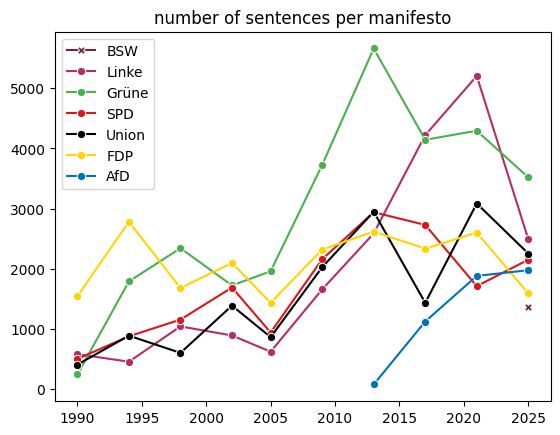

In [94]:
sns.lineplot(
    data = df_sentence_count, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False
    ).set(
        title = "number of sentences per manifesto"
        );
#plt.yscale('log')

In [95]:
df_sentence_count.sum().sum()

109286

In [96]:
# word count
word_counter = 0
for text in manifesto_texts.values():
    for sentence in text:
        new_words = sentence.count(" ") + 1 # number of words = number of spaces + 1
        word_counter += new_words
print(word_counter)

1551414


### Sentence lengths (exploratory)

In [98]:
def get_sentence_length(party, election):
    sentence_lengths = []
    # we use a pipeline to apply nlp to each element of the manifesto list (i.e. each sentence, IF they are split)
    docs = nlp_spacy_large.pipe(manifesto_texts[(party, election)]) #components_disable)
    for doc in docs: # iterate over the sentences
        sentence_length = 0
        for token in doc: # iterate over the tokens/words
            if not (token.is_punct or token.text == " "): # or token.is_stop # ignore stop words (und/oder/aber, der/die/das, sein/haben/...), punctuation (,/./-), and space-only tokens (" ")
                sentence_length += 1
        sentence_lengths.append(sentence_length)
    return {"mean": np.mean(sentence_lengths), "median": np.median(sentence_lengths)}

In [99]:
df_sentence_length = {}
for aggregation in ["mean", "median"]:
    df_sentence_length[aggregation] = pd.DataFrame(columns = parties_list, index = elections_list)
for party, election in (pbar := tqdm(manifesto_texts.keys())):
    sentence_length = get_sentence_length(party, election)
    for aggregation in ["mean", "median"]:
        df_sentence_length[aggregation].at[election, party] = sentence_length[aggregation]

  0%|          | 0/55 [00:00<?, ?it/s]

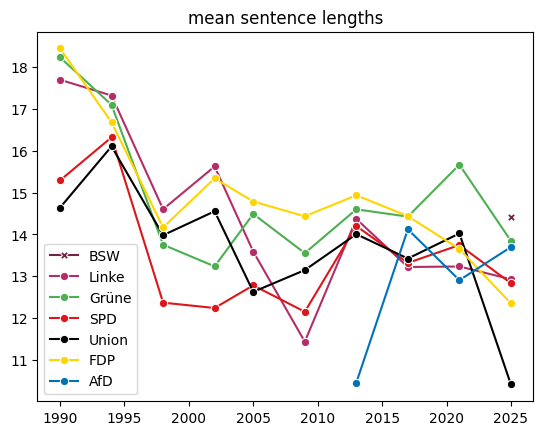

In [100]:
sns.lineplot(
    data = df_sentence_length["mean"], palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False
    ).set(
        title = "mean sentence lengths" 
    );

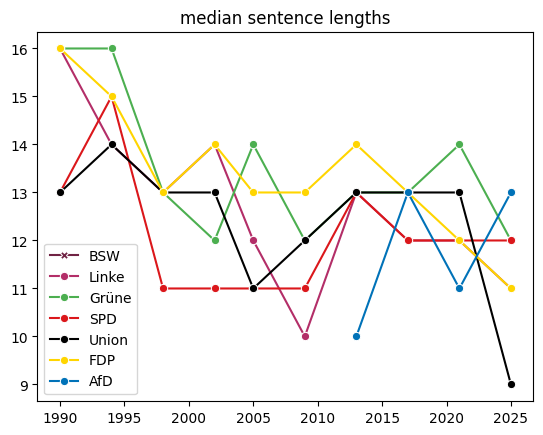

In [101]:
sns.lineplot(data = df_sentence_length["median"], palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False
    ).set(
        title = "median sentence lengths" 
    );

In [102]:
# for future optimisation
def speedcheck(party, election):
    sentence_lengths = []
    # we use a pipeline to apply nlp to each element of the manifesto list (i.e. each sentence, IF they are split)
    docs = nlp_spacy_large.pipe(manifesto_texts[(party, election)], disable=["tok2vec", "morphologizer", "lemmatizer", "attribute_ruler", "parser"]) #components_disable)
    for doc in docs: # iterate over the sentences
        sentence_length = 0
        for token in doc: # iterate over the tokens/words
            if not (token.is_punct or token.text == " "): # or token.is_stop # ignore stop words (und/oder/aber, der/die/das, sein/haben/...), punctuation (,/./-), and space-only tokens (" ")
                sentence_length += 1
        sentence_lengths.append(sentence_length)
    return {"mean": np.mean(sentence_lengths), "median": np.median(sentence_lengths)}
speedcheck("SPD", 2025)

{'mean': np.float64(12.831627906976744), 'median': np.float64(12.0)}

### Nominal style (exploratory)

In [103]:
def get_noun_share(party, election):
    noun_shares = []
    # we use a pipeline to apply nlp to each element of the manifesto list (i.e. each sentence, IF they are split)
    docs = nlp_spacy_large.pipe(manifesto_texts[(party, election)])#components_disable)
    for doc in docs: # iterate over the sentences
        words_in_sentence = 0
        nouns_in_sentence = 0
        for token in doc: # iterate over the tokens/words
            if not (token.is_punct or token.text == " "): # or token.is_stop # ignore stop words (und/oder/aber, der/die/das, sein/haben/...), punctuation (,/./-), and space-only tokens (" ")
                words_in_sentence += 1
                if token.pos_=="NOUN":
                    nouns_in_sentence += 1
        noun_share = nouns_in_sentence / words_in_sentence
        noun_shares.append(noun_share)
    return np.mean(noun_shares)

In [104]:
df_noun_share = pd.DataFrame(columns = parties_list, index = elections_list)
for party, election in (pbar := tqdm(manifesto_texts.keys())):
    df_noun_share.at[election, party] = get_noun_share(party, election)
df_noun_share

  0%|          | 0/55 [00:00<?, ?it/s]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.305387,0.275349,0.262405,0.249359,0.293369,NaN
1994,NaN,0.298556,0.269558,0.259705,0.260358,0.280279,NaN
1998,NaN,0.287729,0.287583,0.297364,0.270325,0.296226,NaN
2002,NaN,0.272245,0.2772,0.273046,0.271273,0.271744,NaN
2005,NaN,0.282354,0.26476,0.263357,0.253783,0.269694,NaN
2009,NaN,0.302092,0.264774,0.284755,0.264968,0.273397,NaN
2013,NaN,0.271198,0.258753,0.265291,0.269822,0.250752,0.261251
2017,NaN,0.271218,0.246781,0.261334,0.253401,0.26969,0.27863
2021,NaN,0.275375,0.264421,0.251846,0.254913,0.278466,0.291646
2025,0.263891,0.266926,0.252385,0.248018,0.275295,0.264197,0.279842


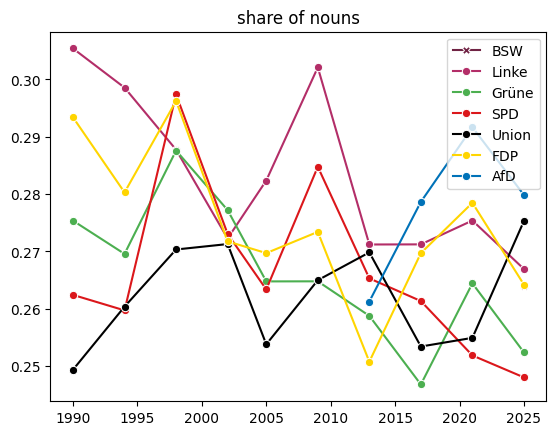

In [105]:
sns.lineplot(data = df_noun_share, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False
    ).set(
        title = "share of nouns" 
    );

### Cross-manifesto DTMs (kind of TF-IDF)

In [106]:
# input: two different manifestos
# we calculate the relative frequency of words (lemmata) in each
# then we compare the manifestos (delta) and check which words are overrepresented in either manifesto
def get_dtm_comparison(party1, election1, party2, election2):
    dtm1 = dtms[(party1, election1)].copy()
    dtm2 = dtms[(party2, election2)].copy()
    # from the ABSOLUTE count for each lemma, create a RELATIVE frequency for each lemma
    for dtm in [dtm1, dtm2]:
        dtm["frequency"] = dtm["count"] / dtm["count"].sum()
    # in case we want to use more sophisticated column labels
    suffixes = ("1","2")#("_" + party1 + "_" + str(election1), "_" + party2 + "_" + str(election2))
    # merge the two dataframes on the lemma columns
    dtm_comp = pd.merge(dtm1, dtm2, on="lemma", how="outer", suffixes=suffixes).fillna(0)
    # compute the difference in relative frequencies
    dtm_comp["delta"] = dtm_comp[f"frequency{2}"] - dtm_comp[f"frequency{1}"]
    dtm_comp = dtm_comp.sort_values("delta")
    return dtm_comp

In [107]:
# sample use
get_dtm_comparison("Linke", 2021, "FDP", 2021)

,lemma,count1,frequency1,count2,frequency2,delta
11979,sozial,280.0,0.008165,37.0,0.002020,-0.006146
5286,Mensch,321.0,0.009361,73.0,0.003985,-0.005376
13094,öffentlich,234.0,0.006824,40.0,0.002183,-0.004641
4745,LINKE,153.0,0.004462,0.0,0.000000,-0.004462
9840,beschäftigter,156.0,0.004549,10.0,0.000546,-0.004003
...,...,...,...,...,...,...
1766,Chance,11.0,0.000321,55.0,0.003002,0.002681
1968,Deutschland,90.0,0.002625,115.0,0.006277,0.003653
10441,europäisch,78.0,0.002275,119.0,0.006496,0.004221
1939,Demokrat,0.0,0.000000,378.0,0.020633,0.020633


#### Visualisation

In [108]:
# input: two different manifestos
# we first compute the comparative document term matrix from above
# then we visualise the most overrepresented words in either manifeso
def visualise_differences(party1, election1, party2, election2, excluded_words=[], counter=15):
    # create a dataframe to be plotted
    dtm = get_dtm_comparison(party1, election1, party2, election2)
    dtm_mask = dtm[["lemma", "delta"]].query("lemma not in @excluded_words").sort_values("delta")
    dtm_to_plot = pd.concat(
        [dtm_mask[:counter], # first rows of the dtm (top outliers of party1/election1)
         dtm_mask[-counter:]], # last rows of the dtm (top outliers of party2/election2)
         ignore_index=True
         )
    # set up the plot
    fig, ax = plt.subplots(figsize=(6, 10))
    sns.swarmplot(data = dtm_to_plot, x = "delta", y = "lemma")
    ax.axvline(0)
    ax.set_ylabel("")
    ax.set_xlabel(f"<-- {party1} ({election1}) | {party2} ({election2}) -->")
    ax.set_title(f"Difference in relative frequency")
    plt.grid()
    # show the plot
    plt.show()


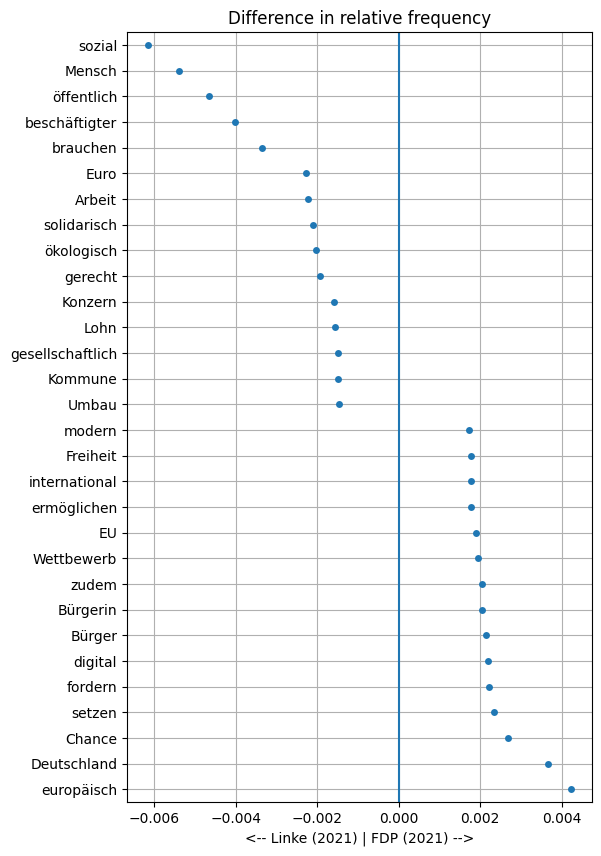

In [109]:
# sample use
# which words do we want to exclude?
test_exclude = (
    ["frei", "Demokrat", "LINKE", # words that are part of party names
     "Kapitel", "vgl."] # words that are part of the document structure
     )
visualise_differences("Linke", 2021, "FDP", 2021, test_exclude)

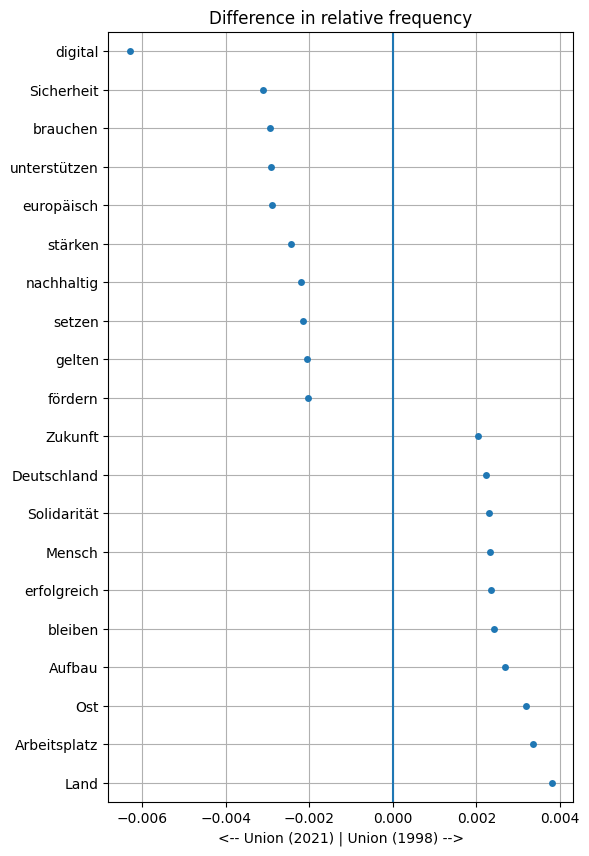

In [110]:
test_exclude = (
    ["CDU", "CSU" ]
     )
visualise_differences("Union", 2021, "Union", 1998, test_exclude, counter = 10)

## Data analysis: sentiments

### Using word dictionaries

#### SentiWS

About: 
>  SentimentWortschatz, or SentiWS for short, is a publicly available German-language resource for sentiment analysis, opinion mining etc. It lists positive and negative polarity bearing words weighted within the interval of [-1; 1] plus their part of speech tag, and if applicable, their inflections. 

Source: https://wortschatz.uni-leipzig.de/en/download

##### Loading SentiWS

From the documentation (`SentiWS.txt`):

> SentiWS is organised in two utf8-encoded text files structured the following way: <br>
`<Word>|<POS tag> \t <Polarity weight> \t <Infl_1>,...,<Infl_k> \n` <br>
> where \t denotes a tab, and \n denotes a new line.

So we basically have TWO different delimiters/separators: `|` between a word and its POS tag; and `\t` (tab) between the other columns:

In [111]:
pd.read_csv("imports/dictionaries/SentiWS_v2.0/SentiWS_v2.0_Positive.txt", sep="\t")
# note the first column with the |<POS tag>

,Abmachung|NN,0.0040,Abmachungen
0,Abschluß|NN,0.0040,"Abschluss,Abschlusse,Abschlusses,Abschlüsse,Ab..."
1,Abstimmung|NN,0.0040,Abstimmungen
2,Agilität|NN,0.0040,NaN
3,Aktivität|NN,0.0040,Aktivitäten
4,Aktualisierung|NN,0.0040,Aktualisierungen
...,...,...,...
1638,überwältigt|ADJX,0.0578,"überwältigter,überwältigtes,überwältigte,überw..."
1639,überzeugen|VVINF,0.3396,"überzeuge,überzeugst,überzeugt,überzeuget,über..."
1640,überzeugend|ADJX,0.4489,"überzeugender,überzeugendes,überzeugende,überz..."
1641,überzeugt|ADJX,0.2381,"überzeugtestem,überzeugtesten,überzeugtester,ü..."


In [219]:
# We read in the SentiWS and split the word|POS column into two columns
# Since we have separate files for positive and negative words, we iterate over each

In [112]:
# Create a dictionary. Each value will be a dataframe for the positive and negative sentiWS, respectively
sentiWS = {}
sentiWS_suffices = ["Positive", "Negative"]
for idx, senti in enumerate(["pos", "neg"]):
    filename = "imports/dictionaries/SentiWS_v2.0/SentiWS_v2.0_" + sentiWS_suffices[idx] + ".txt"
    column_names = ["word|POS", "polarity", "inflections"]
    df_sentiWS = pd.read_csv(filename, sep="\t", names=column_names)
    df_sentiWS[["word", "POS"]] = df_sentiWS["word|POS"].str.split("|", expand=True)
    # since we have lemmatized the manifestos, we do not need the inflections (nor the POS tags)
    sentiWS[senti] = df_sentiWS[["word", "polarity"]]#.set_index("word")
sentiWS

{'pos':              word  polarity
 0       Abmachung    0.0040
 1        Abschluß    0.0040
 2      Abstimmung    0.0040
 3        Agilität    0.0040
 4       Aktivität    0.0040
 ...           ...       ...
 1639  überwältigt    0.0578
 1640   überzeugen    0.3396
 1641  überzeugend    0.4489
 1642    überzeugt    0.2381
 1643        üppig    0.2010
 
 [1644 rows x 2 columns],
 'neg':               word  polarity
 0            Abbau   -0.0580
 1          Abbruch   -0.0048
 2        Abdankung   -0.0048
 3       Abdämpfung   -0.0048
 4           Abfall   -0.0048
 ...            ...       ...
 1822     übersehen   -0.5128
 1823   übertreiben   -0.0372
 1824    übertreten   -0.3290
 1825   übertrieben   -0.3203
 1826  überwältigen   -0.0048
 
 [1827 rows x 2 columns]}

In [113]:
# note there are words that have both positive AND negative polarity. For this reason, we do not merge both df's into a single one.
pd.merge(sentiWS["pos"], sentiWS["neg"], on="word", how="inner") # if we use "word" as index instead of column: left_index=True, right_index=True

,word,polarity_x,polarity_y
0,Reparatur,0.0040,-0.0048
1,hartnäckig,0.0040,-0.1956
2,kritisch,0.0040,-0.2030
3,sorgen,0.2234,-0.0048
4,unerhört,0.0040,-0.0048
5,verschlingen,0.0040,-0.0048


##### Computing SentiWS scores

Since we have positive and negative polarity, there are four (or even more) way to consider the polarity of a manifesto:

1. only positive polarity
2. only negative polarity
3. total polarity as the sum of the absolutes (pos. and neg. polarity contributing in the same way)
4. total polarity as the sum of positive minus negative (pos. and neg. polarity cancel each other out) - not particularly meaningful!

In [114]:
# create a dictionary for the four different polarity measures
senti_scores = {} 
senti_types = ["pos_only", "neg_only", "pos_and_neg", "pos_minus_neg"]
for senti_type in senti_types:
    # for each measure, we create a dataframe of parties (columns) and elections (rows)
    # the value of each cell will contain the sentiment score of the respective manifesto
    senti_scores[senti_type] = pd.DataFrame(columns = parties_list, index = elections_list)
#
for (party, election), dtm in dtms.items():
    # get the DTM of the respective manifesto & compute the frequency for each lemma
    df = dtm.copy()
    df["frequency"] = df["count"] / df["count"].sum()
    # create a dictionary which will store the positive and the negative polarity value
    senti_score = {}
    for polarity in ["pos", "neg"]:
        df = (df
            # check which word in the DTM is also in the sentiWS df
            .merge(sentiWS[polarity], left_on="lemma", right_on="word", how="left")
            .drop(columns=["word"])
            # account for the fact that we have positive and negative sentiWS dataframes
            .rename(columns={"polarity": f"polarity_{polarity}"})
            )
        # computed the frequency-weighted sentiment score (positive & negative separately)
        senti_score[polarity] = (df["frequency"] * df[f"polarity_{polarity}"]).sum()
        # alternative with squared polarity (more weight on extremes):
        # senti_score[polarity] = (df["frequency"] * df[f"polarity_{polarity}"]).sum()
        # alternative with required minimum polarity:        
        # senti_score[polarity] = (df["frequency"] * df[f"polarity_{polarity}"].where(np.abs(df[f"polarity_{polarity}"]) > 0.2)).sum()
    # compute the four different polarity measures
    senti_score["pos_only"] = senti_score["pos"]
    senti_score["neg_only"] = senti_score["neg"]
    senti_score["pos_and_neg"] = senti_score["pos"] + np.abs(senti_score["neg"])
    senti_score["pos_minus_neg"] = senti_score["pos"] - np.abs(senti_score["neg"]) # same as senti_score["pos"] + senti_score["neg"]
    # write it to a df for each party & election
    for senti_type in senti_types:
        senti_scores[senti_type].at[election, party] = senti_score[senti_type]
senti_scores["pos_and_neg"]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.01629,0.017604,0.017154,0.02002,0.014767,NaN
1994,NaN,0.02278,0.020436,0.020885,0.017763,0.016809,NaN
1998,NaN,0.018948,0.017647,0.019125,0.01904,0.016211,NaN
2002,NaN,0.019081,0.017293,0.020138,0.018484,0.017018,NaN
2005,NaN,0.01862,0.022152,0.021927,0.020582,0.019515,NaN
2009,NaN,0.021888,0.022242,0.018533,0.020181,0.01805,NaN
2013,NaN,0.020466,0.020163,0.019915,0.020638,0.017207,0.021753
2017,NaN,0.020295,0.023149,0.020908,0.021234,0.019843,0.018547
2021,NaN,0.018816,0.018405,0.018662,0.018671,0.016933,0.018151
2025,0.025839,0.020866,0.019747,0.022814,0.020508,0.019583,0.019652


##### Visualising SentiWS polarity scores

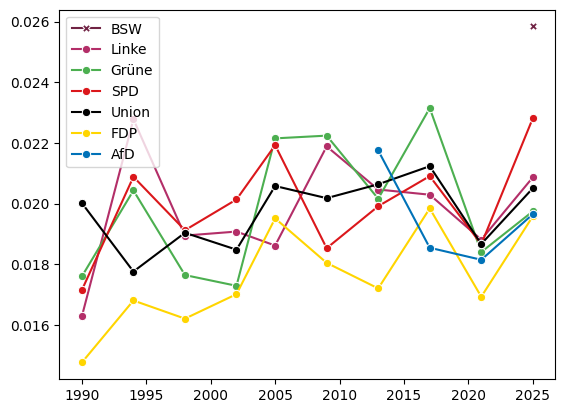

In [117]:
# plot only a single senti score quickly
sns.lineplot(data = senti_scores["pos_and_neg"].loc[1990:], palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False);

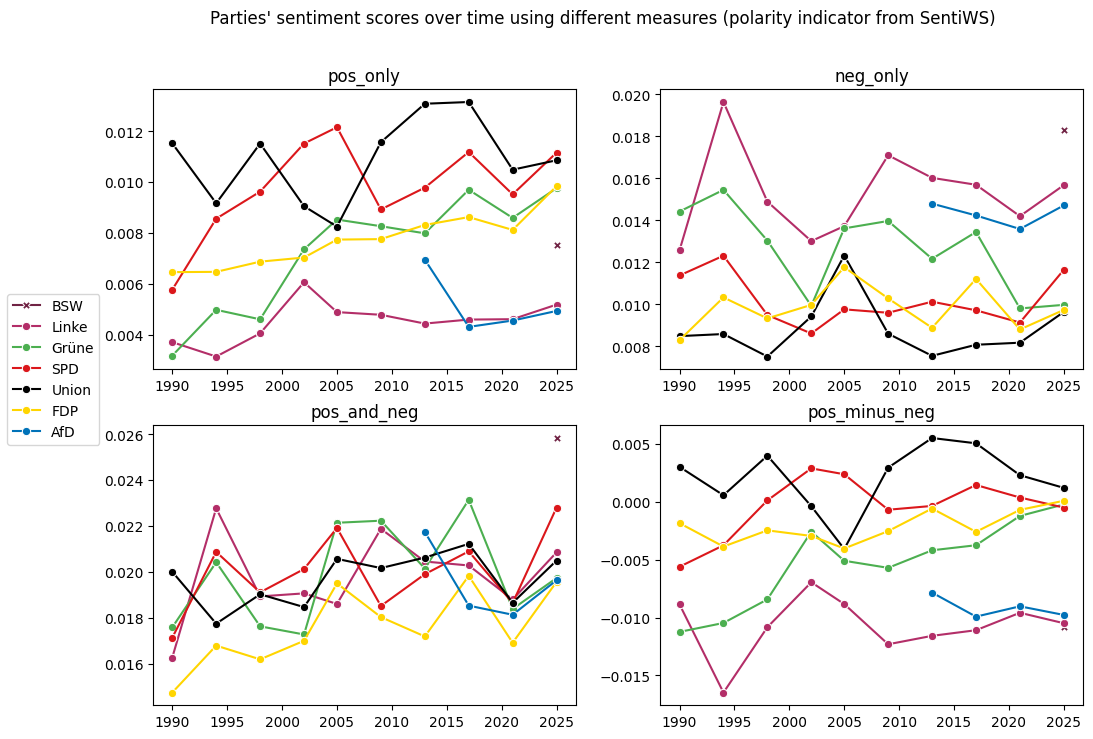

In [118]:
# plot all four different scores
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Parties' sentiment scores over time using different measures (polarity indicator from SentiWS)")
for idx, (ax, senti_type) in enumerate(zip(fig.axes, senti_types)):
    # set up each plot
    # note that we plot neg_only inversed so that all plots show "less polarity" (in absolute terms) at the "bottom"
    factor = -1 if senti_type == "neg_only" else 1
    sns.lineplot(data = factor * senti_scores[senti_type].loc[1990:], ax=ax, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False)
    # add subplot titles
    ax.set_title(senti_type)
    # remove individual legends
    ax.get_legend().remove()
# create a shared legend using the last subplot's legend info 
handles, labels = axs[1,1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left")
plt.show()

##### Alternative score calculations (cutoff, squared, etc.)

We want to consider polarity scores where
- either: very polarising words receive greater weight (squaring the polarity)
- or: barely polarising words are not considered (minimum required polarity)

In [119]:
# create a dictionary for the four different polarity measures
senti_scores_squared = {} 
senti_types = ["pos_only", "neg_only", "pos_and_neg", "pos_minus_neg"]
for senti_type in senti_types:
    # for each measure, we create a dataframe of parties (columns) and elections (rows)
    # the value of each cell will contain the sentiment score of the respective manifesto
    senti_scores_squared[senti_type] = pd.DataFrame(columns = parties_list, index = elections_list)
#
for (party, election), dtm in dtms.items():
    # get the DTM of the respective manifesto & compute the frequency for each lemma
    df = dtm.copy()
    df["frequency"] = df["count"] / df["count"].sum()
    # create a dictionary which will store the positive and the negative polarity value
    senti_score = {}
    for polarity in ["pos", "neg"]:
        df = (df
            # check which word in the DTM is also in the sentiWS df
            .merge(sentiWS[polarity], left_on="lemma", right_on="word", how="left")
            .drop(columns=["word"])
            # account for the fact that we have positive and negative sentiWS dataframes
            .rename(columns={"polarity": f"polarity_{polarity}"})
            )
        # computed the frequency-weighted sentiment score (positive & negative separately)
        senti_score[polarity] = (df["frequency"] * df[f"polarity_{polarity}"]).sum()
        # alternative with squared polarity (more weight on extremes):
        # senti_score[polarity] = (df["frequency"] * df[f"polarity_{polarity}"]).sum()
        # alternative with required minimum polarity:        
        # senti_score[polarity] = (df["frequency"] * df[f"polarity_{polarity}"].where(np.abs(df[f"polarity_{polarity}"]) > 0.2)).sum()
    # compute the four different polarity measures
    senti_score["pos_only"] = senti_score["pos"]
    senti_score["neg_only"] = senti_score["neg"]
    senti_score["pos_and_neg"] = senti_score["pos"] + np.abs(senti_score["neg"])
    senti_score["pos_minus_neg"] = senti_score["pos"] - np.abs(senti_score["neg"]) # same as senti_score["pos"] + senti_score["neg"]
    # write it to a df for each party & election
    for senti_type in senti_types:
        senti_scores_squared[senti_type].at[election, party] = senti_score[senti_type]
senti_scores_squared["pos_and_neg"]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.01629,0.017604,0.017154,0.02002,0.014767,NaN
1994,NaN,0.02278,0.020436,0.020885,0.017763,0.016809,NaN
1998,NaN,0.018948,0.017647,0.019125,0.01904,0.016211,NaN
2002,NaN,0.019081,0.017293,0.020138,0.018484,0.017018,NaN
2005,NaN,0.01862,0.022152,0.021927,0.020582,0.019515,NaN
2009,NaN,0.021888,0.022242,0.018533,0.020181,0.01805,NaN
2013,NaN,0.020466,0.020163,0.019915,0.020638,0.017207,0.021753
2017,NaN,0.020295,0.023149,0.020908,0.021234,0.019843,0.018547
2021,NaN,0.018816,0.018405,0.018662,0.018671,0.016933,0.018151
2025,0.025839,0.020866,0.019747,0.022814,0.020508,0.019583,0.019652


#### BAWL-R (Berlin Affective Words List Reloaded)

About:
> The Berlin Affective Word List - Reloaded (BAWL-R) is a German database containing normative ratings for emotional valence, emotional arousal and imageabilityfor more than 2,900 German words.

Source: https://osf.io/hx6r8/

##### Loading BAWL-R

In [120]:
# Load the XLSX file from the link above into to data folder
# make sure your virtual environment has openpyxl installed (pip install openpyxl) to read in xlsx using pandas

In [121]:
bawl = pd.read_excel("imports/dictionaries/BAWL-R.xlsx")
bawl

,WORD,WORD_LOWER,WORD_CLASS,EMO_MEAN,EMO_STD,AROUSAL_MEAN,AROUSAL_STD,IMAGE_MEAN,IMAGE_STD,LETTERS,PHONEMES,SYLLABLES,Ftot/1MIL,N,FN,HFN,FHFN,BIGmean(TOKEN),ACCENT
0,AAL,aal,N,-0.500000,0.707107,2.380952,1.244033,6.555556,0.726483,3,2.0,1,13.333333,6,3182.00,3,3175.17,83677.500000,1.0
1,AAS,aas,N,-2.100000,1.100505,2.631579,1.422460,5.444444,0.881917,3,2.0,1,1.000000,6,10568.83,5,10568.50,30120.500000,1.0
2,ABART,abart,N,-1.600000,0.699206,3.277778,1.017815,2.333333,1.322876,5,5.0,2,1.166667,2,3.00,1,2.33,80270.000000,1.0
3,ABBAU,abbau,N,-1.000000,1.169795,3.000000,1.297771,2.227273,1.231794,5,4.0,2,14.500000,1,6.83,0,0.00,94054.750000,1.0
4,ABBAUEN,abbauen,V,-0.800000,0.920000,2.105263,1.242521,3.670000,1.580000,7,6.0,3,15.500000,3,51.00,1,38.00,238806.333333,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2897,ZWIEBEL,zwiebel,N,-0.730000,1.120000,2.770000,1.270000,5.950000,1.170000,7,6.0,2,12.830000,0,0.00,0,0.00,165840.666667,1.0
2898,ZWINGEN,zwingen,V,-2.088235,0.965076,3.833333,0.857493,3.500000,1.702939,7,6.0,2,111.333333,4,5.33,0,0.00,374029.333333,1.0
2899,ZWIST,zwist,N,-1.300000,0.483046,3.850000,0.812728,4.000000,1.322876,5,5.0,1,1.000000,1,0.67,0,0.00,126963.750000,1.0
2900,ZYLINDER,zylinder,N,-0.180000,0.730000,2.140000,1.040000,5.180000,1.620000,8,8.0,3,4.330000,0,0.00,0,0.00,498122.714286,2.0


For a documentation of these columns, see the original paper: https://osf.io/ze4ay
We are interested in "emo_mean", which captures 
> "mean [emotional] valence ratings with negative values  for negative valence, positive values for positive valence, and values around 0 for neutral valence"

However, note that words exist in pure upper and pure lowercase only

##### Computing BAWL scores

Just as in the case of positive and negative polarity (see SentiWS), here we have positive and negative emotionality. Hence, there are four (or even more) way to consider the emotionality of a manifesto:

1. only positive emotionality
2. only negative emotionality
3. total emotionality as the sum of the absolutes (pos. and neg. emotionality contributing in the same way)
4. total emotionality as the sum of positive minus negative (pos. and neg. emotionality cancel each other out) - not particularly meaningful!

In [122]:
# create a dictionary for the four different emotionality measures
bawl_scores = {} 
bawl_types = ["pos_only", "neg_only", "pos_and_neg", "pos_minus_neg"]
for bawl_type in bawl_types:
    # for each measure, we create a dataframe of parties (columns) and elections (rows)
    # the value of each cell will contain the emotionality score of the respective manifesto
    bawl_scores[bawl_type] = pd.DataFrame(columns = parties_list, index = elections_list)
#
for (party, election), dtm in dtms.items():
    # get the DTM of the respective manifesto
    df = dtm.copy()
    # account for the fact that BAWL-R comes in all-uppercase or all-lowercase only
    df["lemma_lower"] = df["lemma"].str.lower()
    # compute the frequency for each lemma
    df["frequency"] = df["count"] / df["count"].sum()
    df = (df
          # check which word in the DTM is also in the BAWL-R df
          .merge(bawl[["WORD_LOWER", "EMO_MEAN"]], left_on="lemma_lower", right_on="WORD_LOWER", how="left")
          # drop irrelevant columns
          .drop(columns=["lemma_lower", "WORD_LOWER"])
          )
    # create a dictionary which will store the positive and the negative polarity value
    bawl_score = {}
    # computed the frequency-weighted sentiment score (positive & negative separately)
    bawl_score["pos_only"] = (df["frequency"] * df["EMO_MEAN"].where(df["EMO_MEAN"] > 0)).sum()
    bawl_score["neg_only"] = (df["frequency"] * df["EMO_MEAN"].where(df["EMO_MEAN"] < 0)).sum()
    bawl_score["pos_and_neg"] = bawl_score["pos_only"] + np.abs(bawl_score["neg_only"])
    bawl_score["pos_minus_neg"] = bawl_score["pos_only"] - np.abs(bawl_score["neg_only"]) # same as bawl_score["pos"] + bawl_score["neg"]
    # write it to a df for each party & election
    for bawl_type in bawl_types:
        bawl_scores[bawl_type].at[election, party] = bawl_score[bawl_type]
bawl_scores["pos_and_neg"]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.244888,0.264223,0.235202,0.347012,0.268238,NaN
1994,NaN,0.24661,0.272891,0.286901,0.273097,0.235182,NaN
1998,NaN,0.2454,0.2377,0.297082,0.266459,0.245623,NaN
2002,NaN,0.282672,0.278723,0.288597,0.284799,0.249596,NaN
2005,NaN,0.251465,0.289711,0.301953,0.268918,0.274497,NaN
2009,NaN,0.279731,0.297812,0.289097,0.30643,0.259924,NaN
2013,NaN,0.262897,0.271744,0.267993,0.312924,0.268133,0.327308
2017,NaN,0.262706,0.300809,0.282227,0.304747,0.25889,0.225611
2021,NaN,0.2555,0.260332,0.269207,0.275805,0.241025,0.23195
2025,0.269268,0.259916,0.291533,0.28196,0.290816,0.25424,0.229759


##### Visualising BAWL emotionality scores

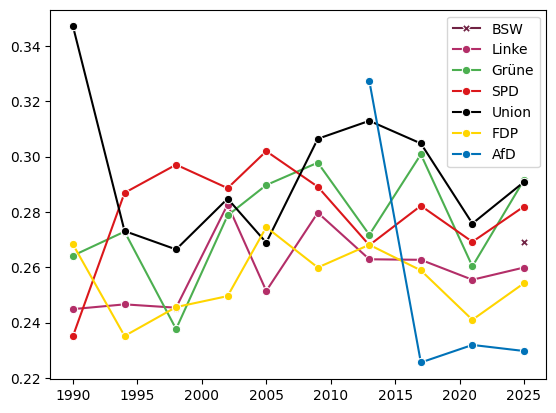

In [124]:
# plot only a single BAWL emotionality score quickly
sns.lineplot(data = bawl_scores["pos_and_neg"].loc[1990:], palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False);

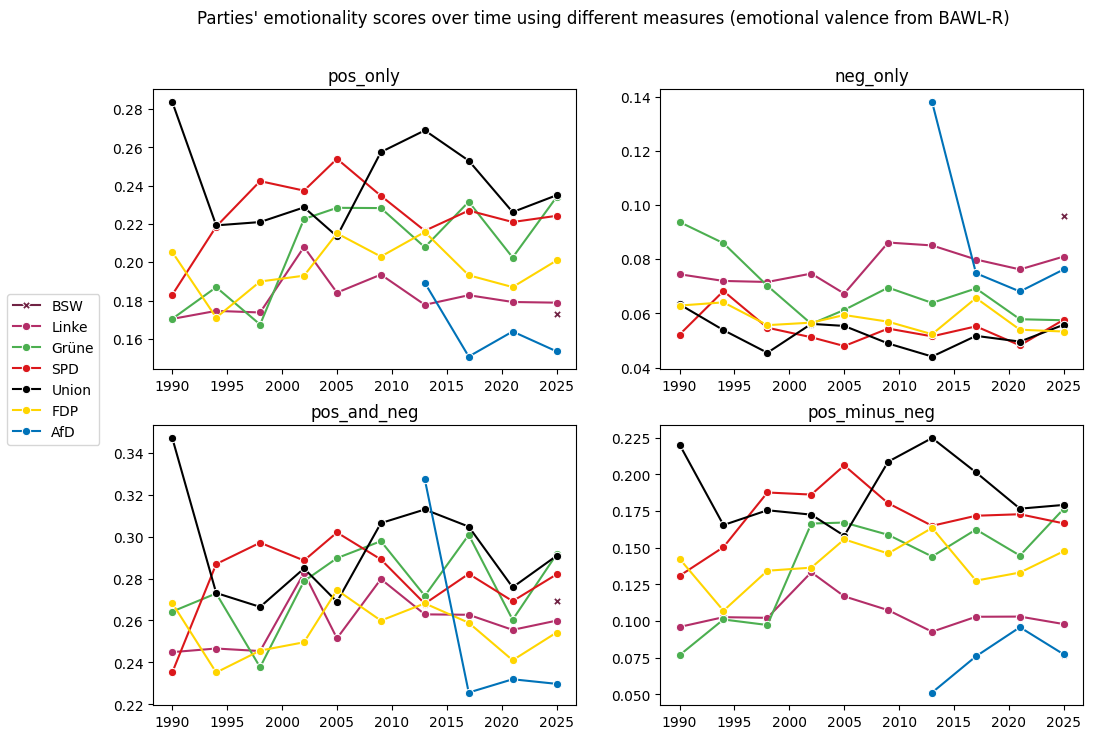

In [126]:
# plot all four different scores
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Parties' emotionality scores over time using different measures (emotional valence from BAWL-R)")
for idx, (ax, bawl_type) in enumerate(zip(fig.axes, bawl_types)):
    # set up each plot
    # note that we plot neg_only inversed so that all plots show "less emotionality" (in absolute terms) at the "bottom"
    factor = -1 if bawl_type == "neg_only" else 1
    sns.lineplot(data = factor * bawl_scores[bawl_type].loc[1990:], ax=ax, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False)
    # add subplot titles
    ax.set_title(bawl_type)
    # remove individual legends
    ax.get_legend().remove()
# create a shared legend using the last subplot's legend info 
handles, labels = axs[1,1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left")
plt.show()

#### GPC (GermanPolarityCues)

About:
> GermanPolarityClues dictionary: A new publicly available lexical resource for sentiment analysis for the German language The resource offers a number of 10.141 polarity features, associated to three numerical polarity scores, determining the positive, negative and neutral direction of specific term features

Source: https://www.ulliwaltinger.de/sentiment-analysis-reloaded-a-comparative-study-on-sentiment-polarity-identification-combining-machine-learning-and-subjectivity-features/

Problem: data not available! Author was contacted, no reply

#### Rauh (Rauh's German Political Sentiment Dictionary)

About:
> dictionaries provided in Rauh (forthcoming). Rauh assesses its performance against human intuition of sentiment in German political language (parliamentary speeches, party manifestos, and media coverage). The resource builds on, harmonizes and extends the SentiWS (Remus et al. 2010) and GermanPolarityClues (Waltinger 2010) dictionaries.

Source: [Rauh 2018](https://www.tandfonline.com/doi/full/10.1080/19331681.2018.1485608), [dictionaries as Rdata files](https://rdrr.io/github/quanteda/quanteda.sentiment/man/data_dictionary_Rauh.html), [dictionaries as TSV](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/BKBXWD)

##### Loading Rauh

The original dictionary was provided as an R data file only, so we stick to this format. Note, however, that we by now also have a TSV file for easier importing available.

Furthermore, there in fact are TWO dictionaries:
- one has unigrams (single words) that may have negative or positive sentiments
- the other has bigrams of negations (nicht|nichts|kein|keine|keinen) and the respective unigram for inverted sentiments

In [127]:
rauh = {}
for dict_type, prefix, suffix in zip(["unigrams", "bigrams"], ["", "neg."], ["", "_Negation"]):
    file_path = "imports/dictionaries/Rauh/Rauh_SentDictionaryGerman" + suffix + ".Rdata"
    converted = rdata.read_rda(file_path)
    key_name = prefix + "sent.dictionary"
    rauh[dict_type] = converted[key_name]
rauh.keys()

dict_keys(['unigrams', 'bigrams'])

In [128]:
rauh["unigrams"]

,feature,sentiment
1999,aalen,1
21164,aalglatt,-1
21165,aasen,-1
21166,aasig,-1
17540,abandon,-1
...,...,...
37199.1,geehrte,1
37200.1,geehrter,1
37201.1,geehrten,1
37202.1,geglückte,1


In [129]:
rauh["bigrams"]

,pattern,replacement,feature,sentiment
1999,(nicht|nichts|kein|keine|keinen) aalen,NOT_aalen,NOT_aalen,-1.0
21164,(nicht|nichts|kein|keine|keinen) aalglatt,NOT_aalglatt,NOT_aalglatt,1.0
21165,(nicht|nichts|kein|keine|keinen) aasen,NOT_aasen,NOT_aasen,1.0
21166,(nicht|nichts|kein|keine|keinen) aasig,NOT_aasig,NOT_aasig,1.0
17540,(nicht|nichts|kein|keine|keinen) abandon,NOT_abandon,NOT_abandon,1.0
...,...,...,...,...
37199.1,(nicht|nichts|kein|keine|keinen) geehrte,NOT_geehrte,NOT_geehrte,-1.0
37200.1,(nicht|nichts|kein|keine|keinen) geehrter,NOT_geehrter,NOT_geehrter,-1.0
37201.1,(nicht|nichts|kein|keine|keinen) geehrten,NOT_geehrten,NOT_geehrten,-1.0
37202.1,(nicht|nichts|kein|keine|keinen) geglückte,NOT_geglückte,NOT_geglückte,-1.0


##### Issues with Rauh's dict

However, there are quite a few difficulties when working with this dict-set as compared to the previous ones.

- First, we saw above that the negated forms are bigrams, so we cannot simply match the document term matrices from above (which reduced the manifestos to unigram lemmata).

- Second, even the unigram dictionary cannot be matched so easily since it contains preceding and trailing spaces for each word (according to the paper: in order avoid cases such as "ungut" counted as "gut").

In [130]:
# note the preceding & trailing spaces:
rauh["unigrams"].feature.values[0:3]

<StringArray>
[' aalen ', ' aalglatt ', ' aasen ']
Length: 3, dtype: string

In the following we therefore

- ignore the negated dictionary (which is a severe limitation!)
- remove preceding & trailing spaces from the non-negated dict

In [131]:
# strip spaces
rauh["unigrams"]["feature"] = rauh["unigrams"]["feature"].str.strip()
# check the result
rauh["unigrams"].feature.values[0:3]

<StringArray>
['aalen', 'aalglatt', 'aasen']
Length: 3, dtype: string

Finally, we convert the sentiment scores from string to int:

In [132]:
rauh["unigrams"]["sentiment"].dtype

string[python]

In [133]:
rauh["unigrams"]["sentiment"] = rauh["unigrams"]["sentiment"].astype(int)
rauh["unigrams"]["sentiment"].dtype

dtype('int64')

##### Computing Rauh scores

Just as in the case of positive and negative polarity (see SentiWS), here we have positive and negative sentiments. Hence, there are four (or even more) way to consider the emotionality of a manifesto:

1. only positive sentiments
2. only negative sentiments
3. total sentiments as the sum of the absolutes (pos. and neg. sentiments contributing in the same way)
4. total sentiments as the sum of positive minus negative (pos. and neg. sentiments cancel each other out) - not particularly meaningful!

In [134]:
# create a dictionary for the four different sentiment measures
rauh_scores = {} 
rauh_types = ["pos_only", "neg_only", "pos_and_neg", "pos_minus_neg"]
for rauh_type in rauh_types:
    # for each measure, we create a dataframe of parties (columns) and elections (rows)
    # the value of each cell will contain the sentiment score of the respective manifesto
    rauh_scores[rauh_type] = pd.DataFrame(columns = parties_list, index = elections_list)
#
for (party, election), dtm in dtms.items():
    # get the DTM of the respective manifesto
    df = dtm.copy()
    # account for the fact that Rauh's dict entries are lowercase only
    df["lemma_lower"] = df["lemma"].str.lower()
    # compute the frequency for each lemma
    df["frequency"] = df["count"] / df["count"].sum()
    df = (df
          # check which word in the DTM is also in the BAWL-R df
          .merge(rauh["unigrams"][["feature", "sentiment"]], left_on="lemma_lower", right_on="feature", how="left")
          # drop irrelevant columns
          .drop(columns=["lemma_lower", "feature"])
          )
    # create a dictionary which will store the positive and the negative sentiment value
    rauh_score = {}
    # computed the frequency-weighted sentiment score (positive & negative separately)
    rauh_score["pos_only"] = (df["frequency"] * df["sentiment"].where(df["sentiment"] > 0)).sum()
    rauh_score["neg_only"] = (df["frequency"] * df["sentiment"].where(df["sentiment"] < 0)).sum()
    rauh_score["pos_and_neg"] = rauh_score["pos_only"] + np.abs(rauh_score["neg_only"])
    rauh_score["pos_minus_neg"] = rauh_score["pos_only"] - np.abs(rauh_score["neg_only"]) # same as bawl_score["pos"] + bawl_score["neg"]
    # write it to a df for each party & election
    for rauh_type in rauh_types:
        rauh_scores[rauh_type].at[election, party] = rauh_score[rauh_type]
rauh_scores["pos_and_neg"]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.266153,0.245923,0.280472,0.359116,0.300028,NaN
1994,NaN,0.276,0.28673,0.326225,0.311236,0.304304,NaN
1998,NaN,0.295824,0.289268,0.323081,0.303341,0.296494,NaN
2002,NaN,0.322676,0.299004,0.329208,0.328889,0.300112,NaN
2005,NaN,0.309414,0.306835,0.327303,0.305576,0.301843,NaN
2009,NaN,0.306656,0.305434,0.320421,0.326615,0.296973,NaN
2013,NaN,0.290104,0.297605,0.323599,0.312709,0.29513,0.245742
2017,NaN,0.289411,0.303753,0.320134,0.321109,0.299697,0.259326
2021,NaN,0.27045,0.302285,0.32118,0.31547,0.301201,0.257929
2025,0.28558,0.268079,0.322775,0.333557,0.322074,0.309144,0.264592


##### Visualising Rauh sentiment scores

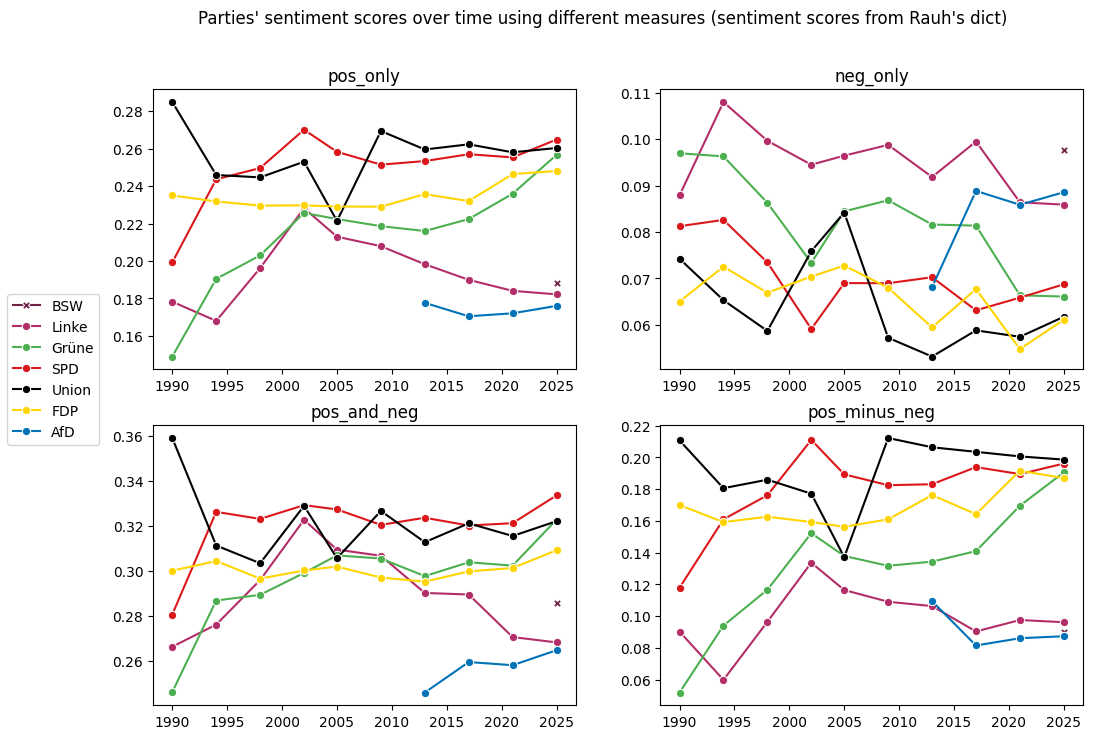

In [136]:
# plot all four different scores
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Parties' sentiment scores over time using different measures (sentiment scores from Rauh's dict)")
for idx, (ax, rauh_type) in enumerate(zip(fig.axes, rauh_types)):
    # set up each plot
    # note that we plot neg_only inversed so that all plots show "less sentiment" (in absolute terms) at the "bottom"
    factor = -1 if rauh_type == "neg_only" else 1
    sns.lineplot(data = factor * rauh_scores[rauh_type].loc[1990:], ax=ax, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False)
    # add subplot titles
    ax.set_title(rauh_type)
    # remove individual legends
    ax.get_legend().remove()
# create a shared legend using the last subplot's legend info 
handles, labels = axs[1,1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left")
plt.show()

#### HaJe (Haselmeyer & Jenny: German Political Sentiment Dictionary)

About:
> This dataset contains a German-language sentiment dictionary of 5001 negative words and their associated sentiment strength on a five-point-scale from 0 (not negative) to 4 (very strongly negative). The procedure for building the dictionary contains the following steps: (1) Sampling 12713 sentences from Austrian parliamentary debates (1995-2013), party press releases (2006-2013), and political news reports (2013), (2) Crowdcoding the sentiment strength of sentences, (3) Estimating a sentence tonality score (4), Estimating a word tonality score, (5) Discriminating between important and unimportant words.

Source: [Haselmeyer & Jenny (2017)](https://link.springer.com/article/10.1007/s11135-016-0412-4), [dataset](https://data.aussda.at/dataset.xhtml?persistentId=doi:10.11587/7PFLIU)

##### Loading HaJe

In [137]:
# the file is provided both in tab and in dta format
# while the tab format seems more attractive, it has encoding issues: umlaute are not encoded properly
# hence, we load the dta (STATA) file instead
haje = pd.read_stata("imports/dictionaries/Haselmeyer_Jenny/10274_da_de_v1_0.dta")#, encoding='Windows-1252')
haje

,version,doi,v1,v2,v3,v4,v5,v6
0,1.0 (2020-11-30),doi:10.11587/7PFLIU,1,abartig,3.150000,0.366348,3.0,3.0
1,1.0 (2020-11-30),doi:10.11587/7PFLIU,2,abbau,1.547826,1.319513,0.0,0.0
2,1.0 (2020-11-30),doi:10.11587/7PFLIU,3,abbauen,1.795455,1.282523,3.0,3.0
3,1.0 (2020-11-30),doi:10.11587/7PFLIU,4,abblocken,2.000000,1.247219,2.0,2.0
4,1.0 (2020-11-30),doi:10.11587/7PFLIU,5,abbruch,2.076923,1.382120,3.0,3.0
...,...,...,...,...,...,...,...,...
4996,1.0 (2020-11-30),doi:10.11587/7PFLIU,4997,überwindung,1.272727,1.555050,0.0,0.0
4997,1.0 (2020-11-30),doi:10.11587/7PFLIU,4998,überzogen,2.909091,1.136182,3.0,3.0
4998,1.0 (2020-11-30),doi:10.11587/7PFLIU,4999,üble,2.766667,0.678911,3.0,3.0
4999,1.0 (2020-11-30),doi:10.11587/7PFLIU,5000,üblich,1.825243,1.199895,2.0,2.0


Looking at the dictionary's documentation (see the dataset link above), we are interested in:
>V2 (Word): The variable contains the dictionary entries

>V3 (Wordscore mean): The variable contains the negativity score for each dictionary entry based on
> 1) the mean score of each sentence (based on ten coders) and
> 2) the mean score of all sentences containing the word (see Haselmayer & Jenny 2017 for more details).

##### Computing HaJe scores

As opposed to the previous dictionaries, the one by Ha & Je only considers neutral to negative words, i.e. no positive-to-negative scale. scores are `>=0`, with larger values indicating a more negative sentiment.

In [138]:
# for each measure, we create a dataframe of parties (columns) and elections (rows)
# the value of each cell will contain the sentiment score of the respective manifesto
haje_scores = pd.DataFrame(columns = parties_list, index = elections_list)
#
for (party, election), dtm in dtms.items():
    # get the DTM of the respective manifesto
    df = dtm.copy()
    # account for the fact that HaJe's dict entries are lowercase only
    df["lemma_lower"] = df["lemma"].str.lower()
    # compute the frequency for each lemma
    df["frequency"] = df["count"] / df["count"].sum()
    df = (df
          # check which word in the DTM is also in the BAWL-R df
          .merge(haje[["v2", "v3"]], left_on="lemma_lower", right_on="v2", how="left")
          # drop irrelevant columns
          .drop(columns=["lemma_lower", "v2"])
          .rename(columns={"v3": "sentiment"})
          )
    # create a dictionary which will store the positive and the negative sentiment value
    haje_score = (df["frequency"] * df["sentiment"]).sum()
    # write it to a df for each party & election
    haje_scores.at[election, party] = haje_score
haje_scores

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.228291,0.248926,0.170608,0.133309,0.149805,NaN
1994,NaN,0.237543,0.221615,0.173023,0.137756,0.167729,NaN
1998,NaN,0.22619,0.198099,0.137696,0.130757,0.149906,NaN
2002,NaN,0.205067,0.150486,0.123774,0.166983,0.165646,NaN
2005,NaN,0.203909,0.181836,0.14123,0.181443,0.177904,NaN
2009,NaN,0.214605,0.184027,0.137288,0.12489,0.161905,NaN
2013,NaN,0.204303,0.18141,0.136551,0.115251,0.136309,0.271669
2017,NaN,0.204935,0.181064,0.134741,0.134776,0.174155,0.220287
2021,NaN,0.193997,0.155283,0.142279,0.127822,0.14818,0.222717
2025,0.247586,0.20339,0.147054,0.147605,0.151494,0.161491,0.234228


##### Visualising HaJe sentiment scores

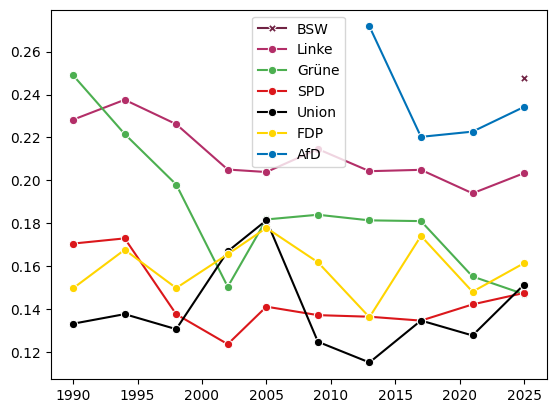

In [140]:
sns.lineplot(data = haje_scores, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False);

#### Populism dict 1: RoPa (Roodujin & Pauwels 2011)

About:
> an a priori designed dictionary [which] serves as a gauge of the degree of populism. […] Our selection of words for the dictionary was based on both empirical and theoretical reasoning.

Source: [Rooduijn & Pauwels 2011](https://www.tandfonline.com/doi/full/10.1080/01402382.2011.616665#d1e164), [dataset](https://www.tandfonline.com/doi/full/10.1080/01402382.2011.616665#)

##### Loading RoPa

We are interested only in the German words (column `GE`). We consider both the `Core` words, which are translated across languages by the authors, and the language-specific `Context`, which are only used for specific languages each.

In [141]:
pd.read_csv("imports/dictionaries/Rooduijn_Pauwels_2011.csv")

,Unnamed: 0,NL,UK,GE,IT
0,Core,elit*,elit*,elit*,elit*
1,NaN,consensus*,consensus*,konsens*,consens*
2,NaN,ondemocratisch*,undemocratic*,undemokratisch*,antidemocratic*
3,NaN,ondemokratisch*,NaN,NaN,NaN
4,NaN,referend*,referend*,referend*,referend*
5,NaN,corrupt*,corrupt*,korrupt*,corrot*
6,NaN,propagand*,propagand*,propagand*,propagand*
7,NaN,politici*,politici*,politiker*,politici*
8,NaN,*bedrog*,*deceit*,täusch*,ingann*
9,NaN,*bedrieg*,*deceiv*,betrüg*,NaN


In [142]:
ropa = pd.read_csv("imports/dictionaries/Rooduijn_Pauwels_2011.csv")["GE"].dropna().tolist()
ropa

['elit*',
 'konsens*',
 'undemokratisch*',
 'referend*',
 'korrupt*',
 'propagand*',
 'politiker*',
 'täusch*',
 'betrüg*',
 'betrug*',
 '*verrat*',
 'scham*',
 'schäm*',
 'skandal*',
 'wahrheit*',
 'unfair*',
 'unehrlich*',
 'establishm*',
 '*herrsch*',
 'lüge*']

##### Computing RoPa scores

In [143]:
# turn the asterisk (*) into a proper regex pattern (.*) to match any character (.) zero or more times (*)
ropa_regex_list = [word.replace("*", ".*") for word in ropa]
# turn the list of regex patterns into a single long regex pattern
ropa_regex = "(?:" + "|".join(ropa_regex_list) + ")"
# usage
bool(re.match(ropa_regex, "schämen"))

True

In [144]:
# compute the frequency of words that are populist according to the RopA dict
def pop_ropa(party, election):
    df = dtms[(party, election)].copy()
    # convert to lowercase to match the dict
    df["lemma"] = df["lemma"].str.lower()
    # check whether the lemma matches any part of the regex pattern
    df["is_pop"] = df["lemma"].apply(lambda x: bool(re.match(ropa_regex, x)))
    #df["is_pop"] = df["lemma"].str.contains(ropa_regex, regex=True)
    # get total word count (ignoring stop words etc.)
    total = df["count"].sum()
    # compute the score, i.e. percentage of words that are populist
    score = (df["count"]*df["is_pop"]).sum() / total
    words = df[df.is_pop == True] # in case we want to see the populist words
    return {"score": score, "words": words}
# sample use
pop_ropa("AfD", 2021)["score"]

np.float64(0.0015584820384945063)

In [145]:
ropa_scores = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election) in dtms.keys():
    ropa_score = pop_ropa(party, election)["score"]
    ropa_scores.at[election, party] = ropa_score * 100
ropa_scores

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.206612,0.484795,0.026212,0.069061,0.048436,NaN
1994,NaN,0.094118,0.221816,0.056489,0.027507,0.067708,NaN
1998,NaN,0.287572,0.144543,0.142389,0.047733,0.040963,NaN
2002,NaN,0.212194,0.168979,0.166961,0.070168,0.074377,NaN
2005,NaN,0.115367,0.160303,0.050251,0.074349,0.134409,NaN
2009,NaN,0.136639,0.136465,0.070148,0.060164,0.090101,NaN
2013,NaN,0.119429,0.147033,0.083301,0.044908,0.055857,0.0
2017,NaN,0.126665,0.101158,0.039712,0.076403,0.042399,0.144875
2021,NaN,0.075822,0.059823,0.02642,0.042345,0.03821,0.155848
2025,0.157085,0.075462,0.075219,0.029855,0.033611,0.020074,0.155269


##### Visualising RoPa populism scores

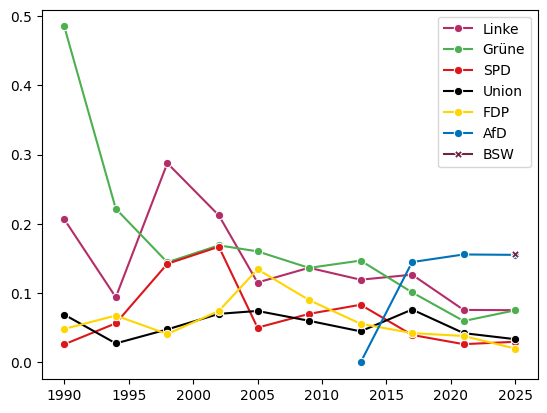

In [146]:
sns.lineplot(data = ropa_scores[[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]], # reordering the columns to make the single BSW plotpoint visible
              palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False);

In [147]:
# note that certain words may cause the score to be comparably high for some manifestos:
pop_ropa("Grüne", 1990)["words"]

,lemma,count,is_pop
135,herrschend,3,True
351,undemokratisch,2,True
779,korrupt,1,True
909,konsens,1,True
916,herrschaftsverhältnis,1,True
917,herrschaftsordnung,1,True
1049,einparteienherrschaft,1,True
1235,vorherrschaft,1,True


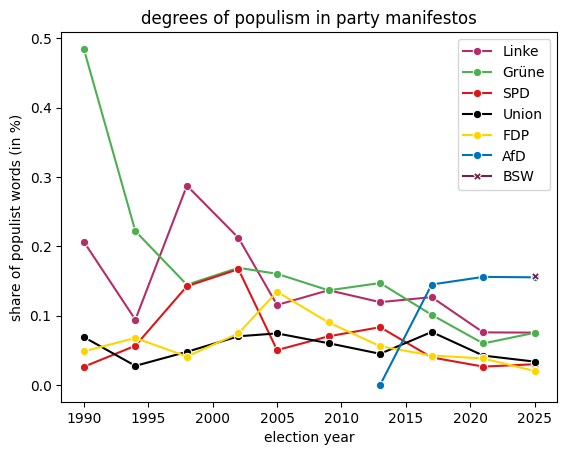

In [148]:
# for exporting
sns.lineplot(data = ropa_scores[[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]], # reordering the columns to make the single BSW plotpoint visible
             palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False
             ).set(
                 title = "degrees of populism in party manifestos",
                 xlabel = "election year",
                 ylabel = "share of populist words (in %)"
                 );
plt.show();

#### Populism dict 2: Pau (Pauwels 2017)

About:
> a ‘populist dictionary’, which is a list of words that indicates instances of populism. The dictionary for this chapter has been based on that of Pauwels (2011) and Bonikowski and Gidron (2016a)

Source: [Pauwels 2017](https://www.nomos-elibrary.de/de/10.5771/9783845271491-123/chapter-6-measuring-populism-a-review-of-current-approaches?page=1), [dataset](https://github.com/jogrue/popdictR/blob/master/data/pauwels_2017_terms.rda)

##### Loading Pau

In [149]:
rdata.read_rda("imports/dictionaries/pauwels_2017_terms.rda")

{'pauwels_2017_terms': array(['Gier*', 'Grosskonzern*', 'Imerialismus*', 'Imperialistisch*',
        'Internationalismus*', 'Kapitalisten*', 'Lakai*', 'Monopol*',
        'Oligarch*', 'Oligarchie*', 'Plutokratie*', 'abgehoben*',
        'anti-basisdemokratisch*', 'anti-demokratisch*',
        'antibasisdemokratisch*', 'antidemokratisch*', 'aristokrat*',
        'aufhals*', 'aufzwing*', 'ausbeuter*', 'autokrati*', 'elite*',
        'elitär*', 'eurokraten*', 'eurokratie*', 'geldadel*',
        'herrschend*', 'internationalistisch*', 'kooptier*', 'korrupt*',
        'kumpanen*', 'plünder*', 'propagand*', 'technokrat*', 'ungewählt*',
        'unterjochen*'], dtype='<U23')}

In [150]:
pau = rdata.read_rda("imports/dictionaries/pauwels_2017_terms.rda")["pauwels_2017_terms"].tolist()
# note there is a type on one of the words, which we correct
pau = ["Imperialismus*" if word == "Imerialismus*" else word for word in pau]
sorted(pau, key=str.lower)

['abgehoben*',
 'anti-basisdemokratisch*',
 'anti-demokratisch*',
 'antibasisdemokratisch*',
 'antidemokratisch*',
 'aristokrat*',
 'aufhals*',
 'aufzwing*',
 'ausbeuter*',
 'autokrati*',
 'elite*',
 'elitär*',
 'eurokraten*',
 'eurokratie*',
 'geldadel*',
 'Gier*',
 'Grosskonzern*',
 'herrschend*',
 'Imperialismus*',
 'Imperialistisch*',
 'Internationalismus*',
 'internationalistisch*',
 'Kapitalisten*',
 'kooptier*',
 'korrupt*',
 'kumpanen*',
 'Lakai*',
 'Monopol*',
 'Oligarch*',
 'Oligarchie*',
 'Plutokratie*',
 'plünder*',
 'propagand*',
 'technokrat*',
 'ungewählt*',
 'unterjochen*']

##### Computing Pau scores

In [151]:
# turn the asterisk (*) into a proper regex pattern (.*) to match any character (.) zero or more times (*)
# furthermore, turn all words to lowercase so that we match e.g. both "Gier" and "gierig"
pau_regex_list = [word.lower().replace("*", ".*") for word in pau]
# turn the list of regex patterns into a single long regex pattern
pau_regex = "(?:" + "|".join(pau_regex_list) + ")"
# usage
bool(re.match(pau_regex, "autokratisch"))

True

In [152]:
pau_regex

'(?:gier.*|grosskonzern.*|imperialismus.*|imperialistisch.*|internationalismus.*|kapitalisten.*|lakai.*|monopol.*|oligarch.*|oligarchie.*|plutokratie.*|abgehoben.*|anti-basisdemokratisch.*|anti-demokratisch.*|antibasisdemokratisch.*|antidemokratisch.*|aristokrat.*|aufhals.*|aufzwing.*|ausbeuter.*|autokrati.*|elite.*|elitär.*|eurokraten.*|eurokratie.*|geldadel.*|herrschend.*|internationalistisch.*|kooptier.*|korrupt.*|kumpanen.*|plünder.*|propagand.*|technokrat.*|ungewählt.*|unterjochen.*)'

In [153]:
# compute the frequency of words that are populist according to the RopA dict
def pop_pau(party, election):
    df = dtms[(party, election)].copy()
    # convert to lowercase to match the dict
    df["lemma"] = df["lemma"].str.lower()
    # check whether the lemma matches any part of the regex pattern
    df["is_pop"] = df["lemma"].apply(lambda x: bool(re.match(pau_regex, x)))
    #df["is_pop"] = df["lemma"].str.contains(pau_regex, regex=True)
    # get total word count (ignoring stop words etc.)
    total = df["count"].sum()
    # compute the score, i.e. percentage of words that are populist
    score = (df["count"]*df["is_pop"]).sum() / total
    words = df[df.is_pop == True] # in case we want to see the populist words
    return {"score": score, "words": words}
# sample use
pop_pau("AfD", 2021)["score"]

np.float64(0.0009350892230967038)

In [154]:
pau_scores = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election) in dtms.keys():
    pau_score = pop_pau(party, election)["score"]
    pau_scores.at[election, party] = pau_score * 100
pau_scores

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.112697,0.308506,0.0,0.0,0.027678,NaN
1994,NaN,0.141176,0.084812,0.014122,0.0,0.02539,NaN
1998,NaN,0.112528,0.066249,0.042717,0.0,0.032771,NaN
2002,NaN,0.070731,0.142298,0.07857,0.040096,0.043387,NaN
2005,NaN,0.06922,0.102011,0.0,0.037175,0.038402,NaN
2009,NaN,0.068319,0.078571,0.038971,0.00752,0.060067,NaN
2013,NaN,0.065143,0.052334,0.0245,0.00998,0.035546,0.0
2017,NaN,0.03619,0.03837,0.017019,0.021829,0.036342,0.120729
2021,NaN,0.049576,0.041876,0.017613,0.014115,0.021834,0.093509
2025,0.052362,0.094328,0.03761,0.0,0.016805,0.030111,0.056461


##### Visualising Pau populism scores

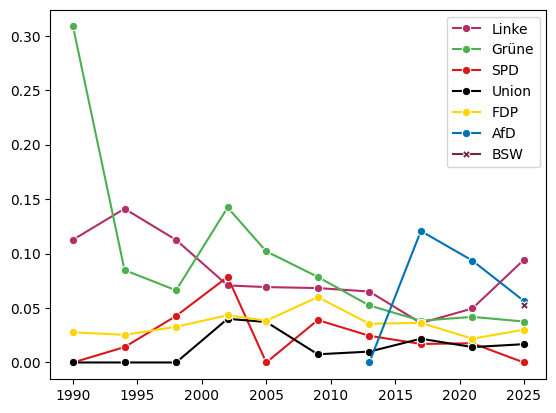

In [160]:
sns.lineplot(data = pau_scores[[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]], # reordering the columns to make the single BSW plotpoint visible
             palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False);

In [161]:
# understand the outliers
pop_pau("Grüne", 1990)["words"]

,lemma,count,is_pop
135,herrschend,3,True
507,ausbeuterisch,1,True
657,technokratisch,1,True
779,korrupt,1,True
1257,monopolbildung,1,True


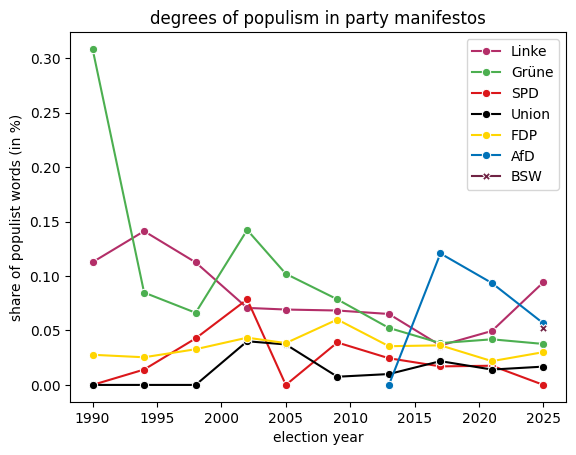

In [163]:
# for exporting
sns.lineplot(data = pau_scores[[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]], # reordering the columns to make the single BSW plotpoint visible
             palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False)
plt.xlabel("election year")
plt.ylabel("share of populist words (in %)")
plt.title("degrees of populism in party manifestos")
plt.show();

#### Populism dict 3: Gru (Gründl 2020)

About:
> a dictionary-based measurement of populist communication that reaches citizens directly through social media in German. […] vastly improved existing dictionaries by analyzing populist ideology in its entirety, including people-centrism and the demand for people’s sovereignty

Source: [Gründl (2020)](https://journals.sagepub.com/doi/10.1177/1461444820976970), [datasets](https://github.com/jogrue/popdictR/tree/master/data-raw)

##### Loading Gru

In [164]:
pd.read_csv("imports/dictionaries/gruendl-populism-dict.csv")

,no,type,Word,Sub_Type,Type2,Type3,wildcard,Source_Politician,Low_Precision,Low_Recall,...,de_SPD_meandv,ch_BDP_meandv,ch_CVP_meandv,ch_EDU_meandv,ch_EVP_meandv,ch_FDP_meandv,ch_Gruene_meandv,ch_Gruenliberale_meandv,ch_SP_meandv,ch_SVP_meandv
0,1,NaN,(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) ...,sorgen der menschen,advocative,people-centrism,regex,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) ...,sorgen der menschen,advocative,people-centrism,regex,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,adjective,aberwitzig(e|er|es|en|em)?,zzz_none,conflictive,anti-elitism,regex,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,abgehoben(e|er|es|en|em)?,"abgehobene, dreiste eliten",conflictive,anti-elitism,regex,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,alt(-)?partei(en)?,zzz_none,conflictive,anti-elitism,regex,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12938,12939,NaN,zwing(t|en) (.* )?wahlberechtigten (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,regex,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12939,12940,NaN,zwing(t|en) (.* )?wähler(n|innen|in)? (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,regex,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12940,12941,NaN,zwing(t|en) (.* )?wählerschaft (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,regex,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12941,12942,NaN,zwing(t|en) (.* )?wahlvolk(e)? (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,regex,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
# focus on the columns of interest
gru = pd.read_csv("imports/dictionaries/gruendl-populism-dict.csv")[["Word", "Sub_Type", "Type2", "Type3", "Include"]]
gru.columns = [ # relabel the columns to more meaningful names
    "regex", # the regex pattern to be found
    "category", # german-language classification of the content
    "direction", # direction: advocative (towards the people) or conflictive (towards the elites)
    "appeal", # appeal pro people, anti elites, or national sovereignty
    "include"
    ]
gru

,regex,category,direction,appeal,include
0,(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) ...,sorgen der menschen,advocative,people-centrism,1
1,(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) ...,sorgen der menschen,advocative,people-centrism,1
2,aberwitzig(e|er|es|en|em)?,zzz_none,conflictive,anti-elitism,1
3,abgehoben(e|er|es|en|em)?,"abgehobene, dreiste eliten",conflictive,anti-elitism,1
4,alt(-)?partei(en)?,zzz_none,conflictive,anti-elitism,1
...,...,...,...,...,...
12938,zwing(t|en) (.* )?wahlberechtigten (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,0
12939,zwing(t|en) (.* )?wähler(n|innen|in)? (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,0
12940,zwing(t|en) (.* )?wählerschaft (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,0
12941,zwing(t|en) (.* )?wahlvolk(e)? (.* )?auf,den menschen aufzwingen,conflictive,sovereignty,0


In [166]:
gru["regex"][1]

'(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) deutsche(n|r)'

In [167]:
# explore the columns/categories
print(gru.direction.unique())
print(gru.appeal.unique())

['advocative' 'conflictive']
['people-centrism' 'anti-elitism' 'sovereignty']


In [168]:
# note: even "Politik" and "Partei" a relisted as a populist words!:
gru.loc[gru["regex"].apply(lambda r: bool(re.search(r, "politiker, parteien")))]

,regex,category,direction,appeal,include
1891,partei,elitenbezug,conflictive,anti-elitism,0
1892,parteien,elitenbezug,conflictive,anti-elitism,0
1893,parteien(.*),zzz_none,conflictive,anti-elitism,0
1894,politik,elitenbezug,conflictive,anti-elitism,0
1895,politik(.*),zzz_none,conflictive,anti-elitism,0
1896,politiker(.*),zzz_none,conflictive,anti-elitism,0
1897,politiker(s|n|innen|in)?,elitenbezug,conflictive,anti-elitism,0


In [169]:
# The author has provided a subset of items:
# "after selecting the relevant and precise terms, 238 terms remained as indicators for advocative or conflictive populist messages"
gru_reduced = gru[gru["include"] == 1]
gru_reduced

,regex,category,direction,appeal,include
0,(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) ...,sorgen der menschen,advocative,people-centrism,1
1,(a|ä)ngst(e)? (de(s|r)|eine(s|r)|unsere(s|r)) ...,sorgen der menschen,advocative,people-centrism,1
2,aberwitzig(e|er|es|en|em)?,zzz_none,conflictive,anti-elitism,1
3,abgehoben(e|er|es|en|em)?,"abgehobene, dreiste eliten",conflictive,anti-elitism,1
4,alt(-)?partei(en)?,zzz_none,conflictive,anti-elitism,1
...,...,...,...,...,...
233,durchschnittlich(e|er|es|en|em) schweizer(s|n|...,normale menschen,advocative,people-centrism,1
234,durchschnitts(-)?schweizer(s|n|innen|in|ische|...,normale menschen,advocative,people-centrism,1
235,redlich(e|er|en|em) bürger(s|n|innen|in)?,ehrliche menschen,advocative,people-centrism,1
236,schmierfink(.*),zzz_none,conflictive,anti-elitism,1


##### Gru populism scores: reduced set

First, we work only with `gru_reduced`.

In [170]:
# how to match regex patterns & sentences
any(gru_reduced["regex"].apply(lambda r: bool(re.search(r, "Die abgehobenen Parteien da oben."))))

True

In [171]:
def check_gru_pop_reduced(sentence):
    # for each regex entry, check whether it matches the sentence
    bool_series = gru_reduced["regex"].apply(lambda r: bool(re.search(r, sentence)))
    bool_any = any(bool_series)
    return (bool_any)

In [172]:
def get_gru_score_reduced(party, election):
    manifesto = manifesto_texts[(party, election)].copy()
    counter = 0
    for sentence in manifesto:
        counter += check_gru_pop_reduced(sentence.lower())
    score = counter / len(manifesto)
    return score
#
# sample use
get_gru_score_reduced("AfD", 2021)

0.06166932482721956

In [173]:
gru_reduced_scores = pd.DataFrame(columns = parties_list, index = elections_list)
for party, election in (pbar := tqdm(manifesto_texts.keys())):
    gru_score = get_gru_score_reduced(party, election)
    gru_reduced_scores.at[election, party] = gru_score
gru_reduced_scores

  0%|          | 0/55 [00:00<?, ?it/s]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.07401,0.09465,0.043825,0.036855,0.049968,NaN
1994,NaN,0.050549,0.055338,0.04447,0.037162,0.054657,NaN
1998,NaN,0.058541,0.049979,0.039827,0.041528,0.064247,NaN
2002,NaN,0.04826,0.027858,0.01955,0.053353,0.052481,NaN
2005,NaN,0.046699,0.04954,0.03617,0.054398,0.064854,NaN
2009,NaN,0.031382,0.037863,0.019926,0.038025,0.06126,NaN
2013,NaN,0.045999,0.04523,0.041511,0.041398,0.051586,0.103896
2017,NaN,0.042891,0.037413,0.032258,0.032775,0.061268,0.062333
2021,NaN,0.041515,0.039599,0.030392,0.036641,0.05075,0.061669
2025,0.058174,0.046568,0.046902,0.047442,0.040391,0.057898,0.073381


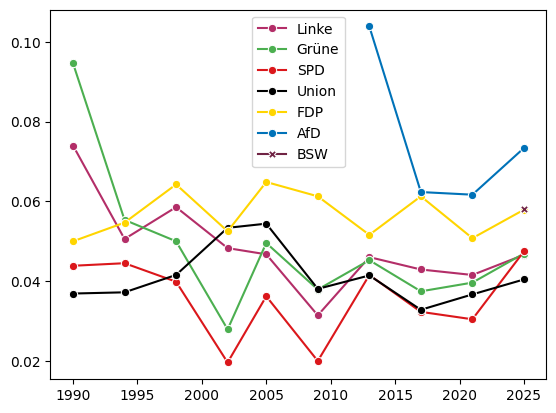

In [175]:
sns.lineplot(data = gru_reduced_scores[[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]], # reordering the columns to make the single BSW plotpoint visible
             palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False);

##### Gru populism scores: full set

We now use the entire regex list with over 12,000 entries. However, using the approach from the reduced set makes this incredibly slow:

In [176]:
def check_gru_pop_full(sentence):
    # for each regex entry, check whether it matches the sentence
    bool_series = gru["regex"].apply(lambda r: bool(re.search(r, sentence.lower())))
    bool_any = any(bool_series)
    return (bool_any)

In [177]:
def get_gru_score_full_slow(party, election):
    manifesto = manifesto_texts[(party, election)].copy()
    counter = 0
    for sentence in (pbar := tqdm(manifesto, leave=False)):
        counter += check_gru_pop_full(sentence)
    score = counter / len(manifesto)
    return score
#
get_gru_score_full_slow("Linke", 2005)

  0%|          | 0/621 [00:00<?, ?it/s]

0.6811594202898551

Instead, we use `hyperscan`:

In [180]:
# transform regex strings to raw bytes strings
patterns_raw = [r.encode(encoding="utf-8") for r in gru["regex"].tolist()]

# create & compile hyperscan database
db = hyperscan.Database()
db.compile(patterns_raw)

# scan a sentence and return true if any pattern was found
def scan_sentence(sentence):
    is_pop = [False]
    def on_match(*args):
        is_pop[0] = True
        # stop scanning as soon as we found a match
        return hyperscan.HS_SCAN_TERMINATED
    try:
        db.scan(sentence.encode('utf-8'), match_event_handler=on_match)
    # when a scan was successfull, we get an error code -3 for some reason, which we want to ignore
    except:
        if hyperscan.HS_SCAN_TERMINATED != -3:
            raise
    return is_pop[0]

In [181]:
def get_gru_score_full(party, election):
    manifesto = manifesto_texts[(party, election)].copy()
    counter = 0
    for sentence in manifesto:
        is_pop = scan_sentence(sentence.lower())
        counter += is_pop
    score = counter / len(manifesto) * 100
    return score
#
get_gru_score_full("AfD", 2021)

58.58585858585859

In [182]:
gru_full_scores = pd.DataFrame(columns = parties_list, index = elections_list)
for (party, election) in dtms.keys():
    gru_score = get_gru_score_full(party, election)
    gru_full_scores.at[election, party] = gru_score
gru_full_scores

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,66.609294,72.839506,69.920319,71.007371,66.839714,NaN
1994,NaN,68.351648,70.262717,74.800456,70.608108,62.747213,NaN
1998,NaN,67.658349,62.580094,69.090909,71.428571,59.4884,NaN
2002,NaN,69.472503,70.980847,63.447867,71.953857,62.78626,NaN
2005,NaN,68.115942,75.536261,70.744681,71.990741,66.457462,NaN
2009,NaN,55.944478,65.789474,69.462465,74.271605,60.742019,NaN
2013,NaN,63.393893,70.229682,70.023818,76.247031,74.436378,72.727273
2017,NaN,63.459716,71.976828,71.517595,74.058577,65.424165,62.600178
2021,NaN,62.67538,71.744701,72.530684,75.551232,66.320646,58.585859
2025,65.758468,62.505018,74.445708,72.511628,66.222814,69.540592,62.095142


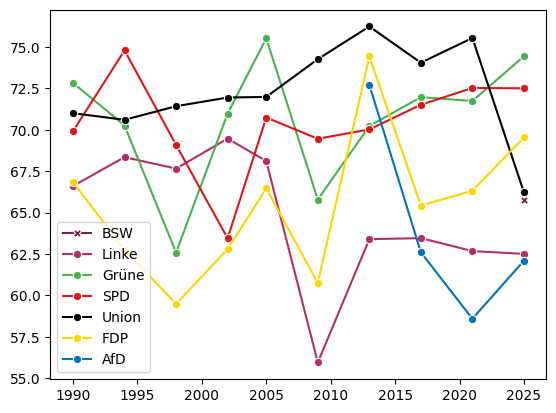

In [185]:
sns.lineplot(data = gru_full_scores, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False);

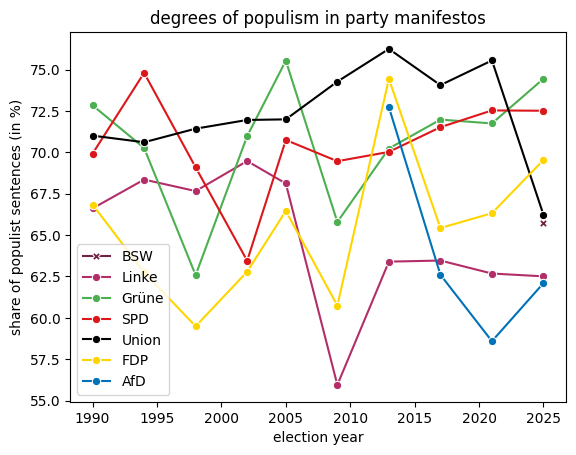

In [186]:
# for exporting
sns.lineplot(data = gru_full_scores, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False);
plt.xlabel("election year")
plt.ylabel("share of populist sentences (in %)")
plt.title("degrees of populism in party manifestos")
plt.show();

---

### Using transformer-based models

#### german-sentiment-bert (gsb)

##### Loading & exploring the model

On [GIT](https://github.com/oliverguhr/german-sentiment-lib) and [huggingface](https://huggingface.co/oliverguhr/german-sentiment-bert). See [here](https://github.com/oliverguhr/german-sentiment-lib/issues/12#issuecomment-1475893203) why the PyPl package from git should be preferred. Note that for this reason we cannot construct a (more efficient) pipeline.

In [271]:
# once we apply the model to all sentences in all manifestos, the process takes very long.
# Since SentimentModel is not in active development any more, we manually patch it to run on Apple's MPS instead of CPU
# use model_gsb_cpu if preferred
# model_gsb_cpu = SentimentModel()
model_gsb = SentimentModel()

def patch_germansentiment_to_mps(model_obj):
    if not torch.backends.mps.is_available():
        raise RuntimeError("MPS is not available.")

    mps_device = torch.device("mps")
    model_obj.device = mps_device
    model_obj.model = model_obj.model.to(mps_device)

    # we have to patch the tokenizer to make it compatible with newer versions of transformers
    # mirror the old batch_encode_plus call
    def predict_sentiment_mps(self, texts, output_probabilities=False):
        texts = [self.clean_text(text) for text in texts]

        encoded = self.tokenizer(
            texts,
            padding=True,
            add_special_tokens=True,
            truncation=True,
            return_tensors="pt"
        )
        encoded = encoded.to(self.device)

        with torch.no_grad():
            outputs = self.model(**encoded)
            probs = torch.softmax(outputs.logits, dim=1)

        probs_cpu = probs.detach().to("cpu").numpy()
        label_ids = probs.argmax(dim=1).detach().to("cpu").numpy()

        classes = [self.model.config.id2label[int(i)].lower() for i in label_ids]

        if not output_probabilities:
            return classes

        probabilities = []
        labels_in_order = [self.model.config.id2label[i].lower() for i in range(probs_cpu.shape[1])]
        for row in probs_cpu:
            probabilities.append(list(zip(labels_in_order, row.tolist())))

        return classes, probabilities

    model_obj.predict_sentiment = MethodType(predict_sentiment_mps, model_obj)
    return model_obj

model_gsb = patch_germansentiment_to_mps(model_gsb)
# check whether move from CPU to MPS worked
print(model_gsb.device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

mps
mps:0


In [274]:
# some sentences
sentences_sample = ["Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
# usage
model_gsb.predict_sentiment(sentences_sample)
# why is the second sentence positive? (and the third neutral?)

['negative', 'positive', 'neutral', 'positive', 'negative']

In [275]:
# we can obtain the probabilities for each class:
model_gsb.predict_sentiment(sentences_sample, output_probabilities=True)

(['negative', 'positive', 'neutral', 'positive', 'negative'],
 [[('positive', 0.004646505694836378),
   ('negative', 0.9952542781829834),
   ('neutral', 9.918733849190176e-05)],
  [('positive', 0.6405041813850403),
   ('negative', 0.35356390476226807),
   ('neutral', 0.005931869614869356)],
  [('positive', 0.0002927042078226805),
   ('negative', 0.0007627745508216321),
   ('neutral', 0.9989445805549622)],
  [('positive', 0.5096430778503418),
   ('negative', 0.47041359543800354),
   ('neutral', 0.0199433546513319)],
  [('positive', 0.20495814085006714),
   ('negative', 0.760979175567627),
   ('neutral', 0.034062691032886505)]])

In [276]:
# we can extract e.g. just the probabilities for the positive class for each se
sentence_classes, sentence_probabilities = model_gsb.predict_sentiment(sentences_sample, output_probabilities=True)
[sentence[0][1] for sentence in sentence_probabilities]

[0.004646505694836378,
 0.6405041813850403,
 0.0002927042078226805,
 0.5096430778503418,
 0.20495814085006714]

##### Applying the model

In [ ]:
# apply the model to a manifesto
# for each sentence in the manifesto, determine its sentiment and the probabilities for each sentiment class
# return the result as a dataframe
# we specify the batch size, which speeds up the process
def get_df_gsb_batched(party, election, batch_size=128):
    manifesto = manifesto_texts[(party, election)]
    classes = []
    probabilities = []

    for i in range(0, len(manifesto), batch_size):
        batch = manifesto[i:i + batch_size]
        classes_batch, probabilities_batch = model_gsb.predict_sentiment(
            batch,
            output_probabilities=True
        )
        classes.extend(classes_batch)
        probabilities.extend(probabilities_batch)

    prob_positive = [dict(p)["positive"] for p in probabilities]
    prob_neutral = [dict(p)["neutral"] for p in probabilities]
    prob_negative = [dict(p)["negative"] for p in probabilities]

    df = pd.DataFrame({
        "sentence": manifesto,
        "sentiment": classes,
        "prob_positive": prob_positive,
        "prob_neutral": prob_neutral,
        "prob_negative": prob_negative,
    })

    return df

In [ ]:
# sample use
get_df_gsb_batched("FDP", 2021).loc[60:70]
# note that we have to read these results with caution, as some sentences may be assigned unfitting sentiments!
# have a look at the sample below - does the classification make sense? ("Wir haben es selbst in der Hand." -> negative?)

,sentence,sentiment,prob_positive,prob_neutral,prob_negative
60,Statt Eigeninitiative und die Übernahme persön...,neutral,0.000004,0.999991,0.000006
61,Und statt für einen handlungsfähigen Rechtssta...,neutral,0.000008,0.999968,0.000024
62,"Wie es ist, darf es nicht bleiben.",neutral,0.012471,0.657136,0.330393
63,Das wissen wir.,neutral,0.001873,0.992490,0.005637
64,Die gute Nachricht: Es muss auch nicht so blei...,positive,0.962898,0.002388,0.034713
65,Alles kann besser werden.,positive,0.986541,0.000054,0.013405
66,Nichts ist Schicksal.,neutral,0.003858,0.979530,0.016612
67,Wir haben es selbst in der Hand.,negative,0.039059,0.459838,0.501104
68,Das ist unsere Mission:,neutral,0.015819,0.926379,0.057801
69,Nie gab es mehr zu tun!,negative,0.002156,0.000597,0.997247


In [280]:
# we want a dataframe of sentence sentiments for each manifesto
# following the notation above, we store these dataframes in a dictionary with party-election tuples as keys
# note this may well take ~30 minutes depending on the machine used!
dfs_gsb = {}
for manifesto in (pbar := tqdm(manifesto_texts)):
    party, election = manifesto[0:2]
    # pbar.set_description(f"Processing manifestos:")
    pbar.set_postfix({"party": party, "election": election})
    df = get_df_gsb_batched(*manifesto)
    dfs_gsb[(party, election)] = df
#
# ALTERNATIVELY: load the classification results from a local copy
# with open("interim/text_classifications_gsb.pkl", "rb") as pickle_file:
#    dfs_gsb = pickle.load(pickle_file)

  0%|          | 0/55 [00:00<?, ?it/s]

In [281]:
# retrieve a specific dataframe with the respective scores from the dictionary (e.g. the one from above)
dfs_gsb[("FDP", 2021)].loc[60:70]

,sentence,sentiment,prob_positive,prob_neutral,prob_negative
60,Statt Eigeninitiative und die Übernahme persön...,neutral,0.000004,0.999991,0.000006
61,Und statt für einen handlungsfähigen Rechtssta...,neutral,0.000008,0.999968,0.000024
62,"Wie es ist, darf es nicht bleiben.",neutral,0.012471,0.657136,0.330393
63,Das wissen wir.,neutral,0.001873,0.992490,0.005637
64,Die gute Nachricht: Es muss auch nicht so blei...,positive,0.962898,0.002388,0.034713
65,Alles kann besser werden.,positive,0.986541,0.000054,0.013405
66,Nichts ist Schicksal.,neutral,0.003858,0.979530,0.016612
67,Wir haben es selbst in der Hand.,negative,0.039059,0.459838,0.501104
68,Das ist unsere Mission:,neutral,0.015819,0.926379,0.057801
69,Nie gab es mehr zu tun!,negative,0.002156,0.000597,0.997247


In [282]:
# note that the snippet above is a particular subsection - by far MOST of the sentences are labeled as neutral:
dfs_gsb[("FDP", 2021)].sentiment.value_counts()

sentiment
neutral     2526
negative      44
positive      31
Name: count, dtype: int64

In [283]:
# store the classification dataframe to avoid having to re-run the model every time
with open("interim/text_classifications_gsb.pkl", "wb") as pickle_file:
    pickle.dump(dfs_gsb, pickle_file)

##### Computing gsb scores

So far, we have created a sentiment analysis at the sentence level. We now want to compute sentiment scores per manifesto.

In [284]:
# first, we compute the frequency of each sentiment in a given manifesto
def get_gsb_frequencies(party, election):
    total = dfs_gsb[(party, election)].shape[0]
    frequencies = {}
    for sentiment in ["positive", "neutral", "negative"]:
        count = (dfs_gsb[(party, election)].sentiment == sentiment).sum()
        frequency = count/total
        frequencies[sentiment] = frequency
    return frequencies
# sample use
get_gsb_frequencies("FDP", 2021)

{'positive': np.float64(0.011918492887351018),
 'neutral': np.float64(0.9711649365628604),
 'negative': np.float64(0.016916570549788543)}

In [285]:
# second we combine the frequencies into a single score
def get_gsb_score(party, election):
    # we define the score as the sum of positive and negative frequencies, i.e. the share of non-neutral sentences in the document
    # we could also use a different metric here
    frequencies = get_gsb_frequencies(party, election)
    score = frequencies["positive"] + frequencies["negative"]
    return score
# sample use
# sample use
get_gsb_score("FDP", 2021)

np.float64(0.02883506343713956)

In [286]:
gsb_scores = pd.DataFrame(columns = parties_list, index = [election for election in elections_list if ((election >= 1990) & (election < 2025))])
for party, election in manifesto_texts.keys():
    score = get_gsb_score(party, election)
    gsb_scores.at[election, party] = score
gsb_scores

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.008606,0.020576,0.01992,0.012285,0.007138,NaN
1994,NaN,0.002198,0.013974,0.021665,0.013514,0.007911,NaN
1998,NaN,0.016315,0.010679,0.017316,0.026578,0.014277,NaN
2002,NaN,0.013468,0.017411,0.031991,0.018025,0.010019,NaN
2005,NaN,0.024155,0.026558,0.028723,0.082176,0.013947,NaN
2009,NaN,0.02414,0.035446,0.038462,0.020741,0.010354,NaN
2013,NaN,0.034789,0.039399,0.018374,0.02511,0.019488,0.051948
2017,NaN,0.035308,0.04393,0.02566,0.033473,0.030848,0.016028
2021,NaN,0.037671,0.02539,0.019287,0.029507,0.028835,0.023923
2025,0.035346,0.048173,0.029278,0.04,0.063471,0.035242,0.020749


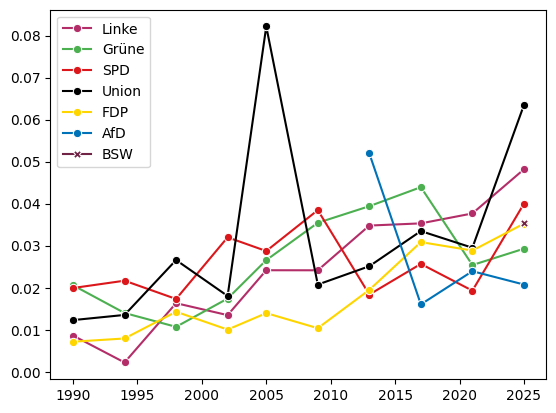

In [289]:
sns.lineplot(data = gsb_scores[[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]], # reordering the columns to make the single BSW plotpoint visible
             palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False);

In [290]:
# outlook
# we COULD change the threshold at which sentences are classified as positive/negative
# currently, most sentences are classified as neutral
# however, either way, the model just is not particularly well suited to the data at hand

#### german party sentiment BERT (gpsb)

##### Loading & exploring the model

On [huggingface](https://huggingface.co/Commandante/german-party-sentiment-bert)

In [303]:
# load it
device = "mps" if torch.backends.mps.is_available() else "cpu"

model_gpsb = pipeline(
    "text-classification",
    model="Commandante/german-party-sentiment-bert",
    device=device
)

print(getattr(model_gpsb, "device", "no .device attribute"))
print(next(model_gpsb.model.parameters()).device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

mps
mps:0


In [292]:
# some sentences
sentences_sample = ["Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
# usage
model_gpsb(sentences_sample)
# note some sentence classifications look better than under the gsb model: "Deutschland hat ein Problem." and  "Die Wirtschaft schrumpft." are now negative; 
# on the other hand, "Den Deutschen geht es zu gut." is now classified as positive
# hence, we again have to use this model with caution

[{'label': 'negative', 'score': 0.9122715592384338},
 {'label': 'negative', 'score': 0.5867864489555359},
 {'label': 'negative', 'score': 0.5786709785461426},
 {'label': 'positive', 'score': 0.8529449701309204},
 {'label': 'positive', 'score': 0.4478197395801544}]

In [293]:
# let's have a look at manifesto text classifications, particularly an excerpt considered for the previous model
manifesto_sample = manifesto_texts[("FDP", 2021)][60:71]
classifications_sample = model_gpsb(manifesto_sample)
for sentence, classification in zip(manifesto_sample, classifications_sample):
    print(f"{sentence}\n --> {classification['label']}")
# comparing this to the gsb classifications, we get some differences. But e.g. "Alles kann besser werden." is now classified as negative...

Statt Eigeninitiative und die Übernahme persönlicher Verantwortung jeder und jedes Einzelnen zu stärken, verzettelte sie sich in Bürokratie.
 --> neutral
Und statt für einen handlungsfähigen Rechtsstaat zu sorgen, der die Sicherheit und Bürgerrechte gleichermaßen schützt, hat die Politik die Freiheit der Sicherheit auf einer erschreckenden Art und Weise untergeordnet.
 --> neutral
Wie es ist, darf es nicht bleiben.
 --> neutral
Das wissen wir.
 --> neutral
Die gute Nachricht: Es muss auch nicht so bleiben.
 --> positive
Alles kann besser werden.
 --> negative
Nichts ist Schicksal.
 --> negative
Wir haben es selbst in der Hand.
 --> neutral
Das ist unsere Mission:
 --> neutral
Nie gab es mehr zu tun!
 --> negative
Werden wir das Land, das in uns steckt
 --> neutral


##### Applying the model

In [294]:
def get_df_gpsb(party, election):
    manifesto = manifesto_texts[(party, election)]
    predictions = model_gpsb(manifesto_texts[(party, election)], batch_size=16) # when testing, batch size of 16 seemed to work best
    sentiments = [prediction["label"] for prediction in predictions]
    probabilities = [prediction["score"] for prediction in predictions]
    df = pd.DataFrame({"sentence": manifesto, "sentiment": sentiments, "probability": probabilities})
    return df

In [295]:
get_df_gpsb("FDP", 2021).loc[60:70]

,sentence,sentiment,probability
60,Statt Eigeninitiative und die Übernahme persön...,neutral,0.996021
61,Und statt für einen handlungsfähigen Rechtssta...,neutral,0.980382
62,"Wie es ist, darf es nicht bleiben.",neutral,0.869363
63,Das wissen wir.,neutral,0.886625
64,Die gute Nachricht: Es muss auch nicht so blei...,positive,0.986317
65,Alles kann besser werden.,negative,0.792905
66,Nichts ist Schicksal.,negative,0.528895
67,Wir haben es selbst in der Hand.,neutral,0.565704
68,Das ist unsere Mission:,neutral,0.472515
69,Nie gab es mehr zu tun!,negative,0.585009


In [304]:
# we want a dataframe of sentence sentiments for each manifesto
# following the notation above, we store these dataframes in a dictionary with party-election tuples as keys
# this runs faster than the gsb model but will still take ~10 mins, depending on the machine
dfs_gpsb = {}
for manifesto in (pbar := tqdm(manifesto_texts)):
    party, election = manifesto[0:2]
    # pbar.set_description(f"Processing manifestos:")
    pbar.set_postfix({"party": party, "election": election})
    df = get_df_gpsb(*manifesto)
    dfs_gpsb[(party, election)] = df
#
# ALTERNATIVELY: load the classification results from a local copy
# with open("interim/text_classifications_gpsb.pkl", "rb") as pickle_file:
#    dfs_gpsb = pickle.load(pickle_file)

  0%|          | 0/55 [00:00<?, ?it/s]

In [305]:
# let's check how many sentences have a non-neutral sentiment score: quite an increase over gsb, but still low overall share
dfs_gpsb[("FDP", 2021)].sentiment.value_counts()

sentiment
neutral     2465
negative      74
positive      62
Name: count, dtype: int64

In [306]:
# store the classification dataframe to avoid having to re-run the model every time
with open("interim/text_classifications_gpsb.pkl", "wb") as pickle_file:
    pickle.dump(dfs_gpsb, pickle_file)

##### Computing gpsb scores

We follow the procedure from the `gsb` model

In [307]:
# first, we compute the frequency of each sentiment in a given manifesto
def get_gpsb_frequencies(party, election):
    total = dfs_gpsb[(party, election)].shape[0]
    frequencies = {}
    for sentiment in ["positive", "neutral", "negative"]:
        count = (dfs_gpsb[(party, election)].sentiment == sentiment).sum()
        frequency = count/total
        frequencies[sentiment] = frequency
    return frequencies
# sample use
get_gpsb_frequencies("FDP", 2021)

{'positive': np.float64(0.023836985774702037),
 'neutral': np.float64(0.9477124183006536),
 'negative': np.float64(0.028450595924644367)}

In [308]:
# second we combine the frequencies into a single score
def get_gpsb_score(party, election):
    # we define the score as the sum of positive and negative frequencies, i.e. the share of non-neutral sentences in the document
    # we could also use a different metric here
    frequencies = get_gpsb_frequencies(party, election)
    score = frequencies["positive"] + frequencies["negative"]
    return score
# sample use
get_gpsb_score("FDP", 2021)

np.float64(0.0522875816993464)

In [309]:
gpsb_scores = pd.DataFrame(columns = parties_list, index = [election for election in elections_list if ((election >= 1990) & (election < 2025))])
for party, election in manifesto_texts.keys():
    score = get_gpsb_score(party, election)
    gpsb_scores.at[election, party] = score
gpsb_scores

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.080895,0.041152,0.031873,0.034398,0.019468,NaN
1994,NaN,0.041758,0.024036,0.078677,0.025901,0.020137,NaN
1998,NaN,0.046065,0.041008,0.080519,0.066445,0.046996,NaN
2002,NaN,0.039282,0.048752,0.080569,0.055516,0.032443,NaN
2005,NaN,0.046699,0.055669,0.070213,0.060185,0.033473,NaN
2009,NaN,0.048884,0.059076,0.051437,0.043951,0.027179,NaN
2013,NaN,0.052184,0.065371,0.038108,0.07058,0.045472,0.064935
2017,NaN,0.059005,0.060825,0.054619,0.089958,0.07455,0.035619
2021,NaN,0.068422,0.056604,0.049094,0.050584,0.052288,0.057416
2025,0.055228,0.065837,0.065378,0.070698,0.106081,0.090623,0.045547


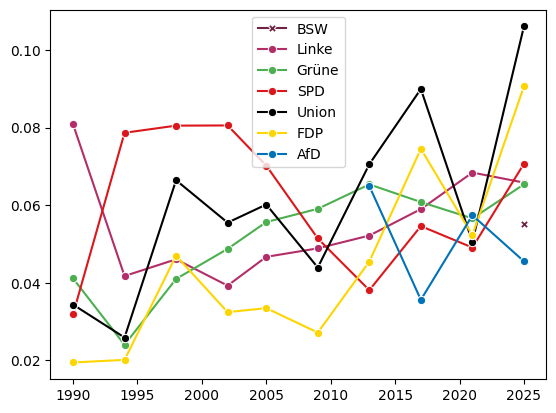

In [311]:
sns.lineplot(data = gpsb_scores, palette = colour_map_parties, markers=["X"]+6*["o"], dashes = False);

In [ ]:
# outlook (same as for gsb)
# we COULD change the threshold at which sentences are classified as positive/negative
# currently, most sentences are classified as neutral
# however, either way, the model just is not particularly well suited to the data at hand

#### PopBERT

From the [documentation](https://huggingface.co/luerhard/PopBERT):

The model outputs a Tensor of length 4. The table connects the position of the predicted probability to its dimension.

- foundational dimensions of populism

    0) 	Anti-Elitism
    1) 	People-Centrism

-  underlying ideological orientation

    2) 	Left-Wing Host-Ideology
    3) 	Right-Wing Host-Ideology

##### Loading & exploring the model

In [312]:
# load tokenizer
tokenizer_pop = AutoTokenizer.from_pretrained("luerhard/PopBERT")
# load model
model_pop = AutoModelForSequenceClassification.from_pretrained("luerhard/PopBERT")

config.json:   0%|          | 0.00/886 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/240k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/729k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [313]:
# text to be analysed
sentences_sample = ["Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
# apply tokeniser & model (at the sentence level!)
encodings_pop = tokenizer_pop(sentences_sample[0], return_tensors="pt")
with torch.inference_mode():
    outputs_pop = model_pop(**encodings_pop)
predictions_pop = torch.nn.functional.sigmoid(outputs_pop.logits)
# output: four probabilities, on for each of the four dimensions above
print(predictions_pop.detach().numpy())

[[0.05062238 0.00458796 0.00374003 0.00431944]]


In [326]:
# at the moment, we have to loop over the sentences and apply the transformer model to each string separately.
# however, it would be more efficient to use a transformers pipeline instead
# but we need to customise the existing pipeline class in order to extract ALL four class probabilities - by default, only one (the max value?) is returned
# we adapt the following guide: https://stackoverflow.com/questions/76434311/how-to-get-the-logits-of-the-model-with-a-text-classification-pipeline-from-hugg
# note: the base pipeline option does not allow us to pass on the option "return_tensors", required to get all four probabilities
# pipe_pop = pipeline("text-classification", model="luerhard/PopBERT", tokenizer="luerhard/PopBERT") # !!! return_tensors="pt")
#
# define a new class from the default one
class pipeline_pop(TextClassificationPipeline):
    def postprocess(self, model_outputs):
        # modify the postprocess
        predictions = torch.nn.functional.sigmoid(model_outputs.logits)
        probabilities = predictions.detach().numpy()
        return probabilities[0]
#
# load tokenizer
tokenizer_pop = AutoTokenizer.from_pretrained("luerhard/PopBERT")
# load model
model_pop = AutoModelForSequenceClassification.from_pretrained("luerhard/PopBERT")
#
# define a pipeline based on this class
pipe_pop = pipeline_pop(model = model_pop, tokenizer = tokenizer_pop, batch_size = 4) # batch size of 4 worked best when trying out now, before it was 16

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [327]:
# apply this to the sample sentences. note the results are the same as when we apply the original model to each sentence separately
pipe_pop(sentences_sample)

[array([0.0506224 , 0.00458795, 0.00374003, 0.00431945], dtype=float32),
 array([0.00501334, 0.01566086, 0.00360484, 0.00494838], dtype=float32),
 array([0.00658387, 0.00743534, 0.00514439, 0.00322039], dtype=float32),
 array([0.0036237 , 0.28474233, 0.00685372, 0.02832531], dtype=float32),
 array([0.00453104, 0.38787   , 0.00701443, 0.03523256], dtype=float32)]

In [328]:
# the four dimensions/classes are:
classes_pop = ["anti-elitism", "people-centrism", "left-wing", "right-wing"]
# the documentation suggests to use the following thresholds for each class - based on the training data used
thresholds_recommended = [0.415961, 0.295400, 0.429109, 0.302714]
# however, since we use a different dataset, way MIGHT want to use the following thresholds instead (will try below)
thresholds_base = [0.5] * 4
# create a dict:
thresholds_pop = {"recommended": {}, "base": {}}
for idx, class_ in enumerate(classes_pop):
    thresholds_pop["recommended"][class_] = thresholds_recommended[idx]
    thresholds_pop["base"][class_] = 0.5
thresholds_pop


{'recommended': {'anti-elitism': 0.415961,
  'people-centrism': 0.2954,
  'left-wing': 0.429109,
  'right-wing': 0.302714},
 'base': {'anti-elitism': 0.5,
  'people-centrism': 0.5,
  'left-wing': 0.5,
  'right-wing': 0.5}}

##### Applying the model

In [ ]:
# OLD: 
# this is the version that manually iterates over sentences. below, we have an alternative using a pipeline. In a first test, this reduces evaluation time from 3min to 10sec, i.e. great efficiency boost!
# load tokenizer
tokenizer_pop = AutoTokenizer.from_pretrained("luerhard/PopBERT")
# load model
model_pop = AutoModelForSequenceClassification.from_pretrained("luerhard/PopBERT")
# for a given manifesto, compute the probabilities for each sentence and return them in a dataframe
def get_df_pop_old(party, election):
    manifesto = manifesto_texts[(party, election)]
    probabilities = []
    for sentence in (pbar := tqdm(manifesto, leave=False)):
        pbar.set_postfix_str("processing sentences")
        inputs = tokenizer_pop(sentence, return_tensors="pt")
        with torch.inference_mode():
            outputs = model_pop(**inputs)
        predictions = torch.nn.functional.sigmoid(outputs.logits)
        probabilities.append(predictions.detach().numpy()[0]) # appends an array with 4 probabilities
    # from the nested list of lists, create a new list for each of the four class probabilities
    prob_elite, prob_people, prob_left, prob_right = list(zip(*probabilities))
    # prob_elite, prob_people, prob_left, prob_right = predictions.detach().numpy()[0]
    df = pd.DataFrame({"sentence": manifesto,
                       "prob_elite": prob_elite, "prob_people": prob_people, "prob_left": prob_left, "prob_right": prob_right
                       })
    return df
# sample use
get_df_pop_old("FDP", 2021)
# took about 3 min

In [329]:
# NEW:
# alternative using a pipeline
def get_df_pop(party, election):
    manifesto = manifesto_texts[(party, election)]
    outputs = pipe_pop(manifesto)
    probabilities = {}
    # create a separate list for each of the four class probabilities
    for idx, dimension in enumerate(classes_pop):
        probabilities[dimension] = [output[idx] for output in outputs]
    # create dataframe with the four class probabilities and add a column with the manifesto sentences
    df = pd.DataFrame(probabilities)
    df.insert(0, "sentence", manifesto)    
    return df
# sample use
get_df_pop("FDP", 2021)
# took about 45 sec

,sentence,anti-elitism,people-centrism,left-wing,right-wing
0,Nie gab es mehr zu tun,0.009768,0.006068,0.003973,0.005048
1,Wahlprogramm der Freien Demokraten,0.010491,0.008565,0.007886,0.006709
2,Wir sind Freie Demokraten.,0.004401,0.018873,0.005722,0.006634
3,"Wir glauben, dass Deutschland jetzt einen Neus...",0.006758,0.015347,0.003369,0.004895
4,"Wir glauben, dass es moderner, digitaler und f...",0.004672,0.011967,0.005686,0.004605
...,...,...,...,...,...
2596,Ältere Menschen sollen auch in Alten- oder Sen...,0.004605,0.012175,0.009367,0.004078
2597,Um digitale Teilhabe für alle Altersgruppen un...,0.005594,0.022776,0.008276,0.003211
2598,Diskriminierende Altersgrenzen abschaffen,0.007999,0.009207,0.006802,0.003645
2599,Wir Freie Demokraten fordern die Abschaffung d...,0.004405,0.017913,0.006476,0.003857


In [ ]:
# future work: wrap the pipe into a tqdm progress tracker
# import datasets
# from transformers.pipelines.pt_utils import KeyDataset
# temp_data = manifesto_texts[("FDP", 2021)].copy()
# #
# # create dataset
# temp_d = datasets.Dataset.from_list([{"sentence": sentence} for sentence in temp_data])
# #
# for out in tqdm(pipe_pop(KeyDataset(temp_d, "sentence")), total = len(temp_d)):
#     continue

In [330]:
# apply model to all manifestos, return a dictionary of dataframes
# note that with the OLD function above (non-pipelined), this may take well over 2h to run!
dfs_pop = {}
for party, election in (pbar := tqdm(manifesto_texts.keys())):
    pbar.set_postfix({"party": party, "election": election})
    df = get_df_pop(party, election)
    dfs_pop[(party, election)] = df
#
# ALTERNATIVELY: load the classification results from a local copy
# with open("interim/text_classifications_pop.pkl", "rb") as pickle_file:
#    dfs_pop = pickle.load(pickle_file)

  0%|          | 0/55 [00:00<?, ?it/s]

In [331]:
# retrieve a specific df
dfs_pop[("FDP", 2021)]

,sentence,anti-elitism,people-centrism,left-wing,right-wing
0,Nie gab es mehr zu tun,0.009768,0.006068,0.003973,0.005048
1,Wahlprogramm der Freien Demokraten,0.010491,0.008565,0.007886,0.006709
2,Wir sind Freie Demokraten.,0.004401,0.018873,0.005722,0.006634
3,"Wir glauben, dass Deutschland jetzt einen Neus...",0.006758,0.015347,0.003369,0.004895
4,"Wir glauben, dass es moderner, digitaler und f...",0.004672,0.011967,0.005686,0.004605
...,...,...,...,...,...
2596,Ältere Menschen sollen auch in Alten- oder Sen...,0.004605,0.012175,0.009367,0.004078
2597,Um digitale Teilhabe für alle Altersgruppen un...,0.005594,0.022776,0.008276,0.003211
2598,Diskriminierende Altersgrenzen abschaffen,0.007999,0.009207,0.006802,0.003645
2599,Wir Freie Demokraten fordern die Abschaffung d...,0.004405,0.017913,0.006476,0.003857


In [332]:
# store the classification dataframe to avoid having to re-run the model every time
with open("interim/text_classifications_pop.pkl", "wb") as pickle_file:
    pickle.dump(dfs_pop, pickle_file)

##### Computing pop scores

We currently have a probability for each sentence and each dimension. For each dimension, we get the share of sentences in the manifesto belonging to that class.

In [333]:
classes_pop

['anti-elitism', 'people-centrism', 'left-wing', 'right-wing']

In [334]:
pop_scores = {}
for pop_type in classes_pop:
    pop_scores[pop_type] = pd.DataFrame(columns = parties_list, index = elections_list)
#
for (party, election), df_pop in dfs_pop.items():
    df = df_pop.copy()
    score = {}
    for pop_type in classes_pop:
        # for each of the four classes, check whether the probability of a sentence belonging to that class is above the respective threshold
        # then get the relative frequency of these sentences compared to the length of the respective manifesto
        score[pop_type] = ((df[pop_type] > thresholds_pop["recommended"][pop_type]).sum()) / df.shape[0]
        pop_scores[pop_type].at[election, party] = score[pop_type]
# let's have a look at one of the class scores
pop_scores["left-wing"]

,BSW,Linke,Grüne,SPD,Union,FDP,AfD
1990,NaN,0.025818,0.028807,0.013944,0.004914,0.002596,NaN
1994,NaN,0.041758,0.02739,0.007982,0.005631,0.004315,NaN
1998,NaN,0.043186,0.020931,0.006061,0.001661,0.006544,NaN
2002,NaN,0.024691,0.006965,0.003555,0.002884,0.005248,NaN
2005,NaN,0.022544,0.02145,0.008511,0.008102,0.01325,NaN
2009,NaN,0.043452,0.02739,0.010658,0.004444,0.005608,NaN
2013,NaN,0.046772,0.022968,0.012589,0.003054,0.004585,0.012987
2017,NaN,0.048104,0.024378,0.004765,0.003487,0.003856,0.011576
2021,NaN,0.043821,0.011181,0.008767,0.003243,0.000769,0.012228
2025,0.041237,0.047371,0.009665,0.004186,0.003551,0.003776,0.012146


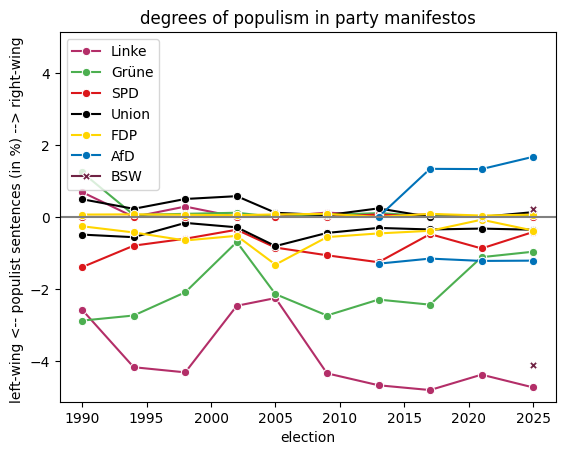

In [342]:
sns.lineplot(data = -pop_scores["left-wing"][[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]]*100, legend=False ,palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False)
sns.lineplot(data = pop_scores["right-wing"][[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]]*100, palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False)
plt.axhline(y = 0, color = "grey")#, linestyle='--')
#plt.yscale('symlog') # to log-scale positive and negative y values
y_bound = np.abs(plt.ylim()).max() # from the automatic bounds of the y-axis, get the one that is larger in absulute terms
plt.ylim(-y_bound, y_bound) # set this limit for BOTH sides of the y axis to make the bounds symmetric
plt.legend(loc="upper left")
plt.title("degrees of populism in party manifestos")
plt.xlabel("election")
plt.ylabel("left-wing <-- populist sentences (in %) --> right-wing ")
plt.show();

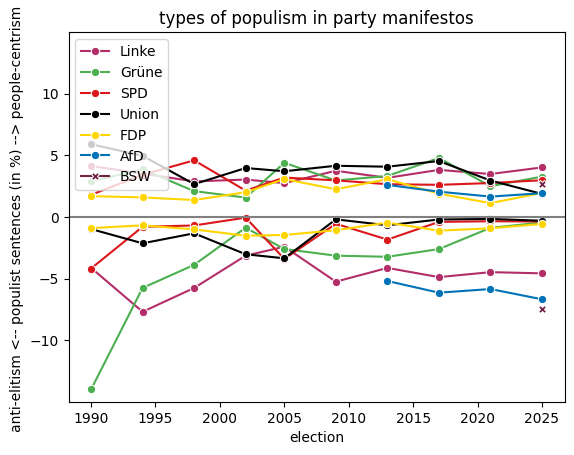

In [343]:
sns.lineplot(data = -pop_scores["anti-elitism"][[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]]*100, legend=False ,palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False)
sns.lineplot(data = pop_scores["people-centrism"][[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]]*100, palette = colour_map_parties, markers=6*["o"]+["X"], dashes = False)
plt.axhline(y = 0, color = "grey")#, linestyle='--')
#plt.yscale('symlog') # to log-scale positive and negative y values
y_bound = np.abs(plt.ylim()).max() # from the automatic bounds of the y-axis, get the one that is larger in absulute terms
plt.ylim(-y_bound, y_bound) # set this limit for BOTH sides of the y axis to make the bounds symmetric
plt.legend(loc="upper left")
plt.title("types of populism in party manifestos")
plt.xlabel("election")
plt.ylabel("anti-elitism <-- populist sentences (in %) --> people-centrism ")
plt.show();

In [344]:
# how to flip this plot, if desired
pop_scores["left-wing"].reset_index(names = "election").melt(id_vars = "election", var_name = "party", value_name = "score")

,election,party,score
0,1990,BSW,NaN
1,1994,BSW,NaN
2,1998,BSW,NaN
3,2002,BSW,NaN
4,2005,BSW,NaN
...,...,...,...
65,2009,AfD,NaN
66,2013,AfD,0.012987
67,2017,AfD,0.011576
68,2021,AfD,0.012228


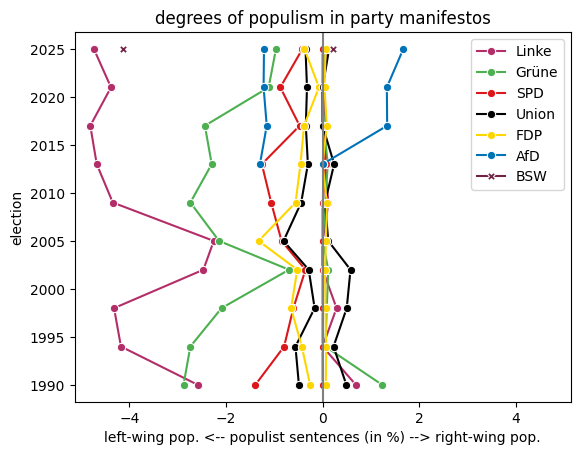

In [345]:
sns.lineplot(
    data = (-1*pop_scores["left-wing"][[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]]*100).reset_index(names = "election").melt(id_vars = "election", var_name = "party", value_name = "score"),
    x= "score",
    y= "election",
    hue = "party",
    orient = "y", 
    style = "party",
    dashes = False,
    markers=6*["o"]+["X"],
    palette = colour_map_parties,
    legend = False)
sns.lineplot(
    data = (pop_scores["right-wing"][[c for c in ropa_scores.columns if c != "BSW"] + ["BSW"]]*100).reset_index(names = "election").melt(id_vars = "election", var_name = "party", value_name = "score"),
    x= "score",
    y= "election",
    hue = "party",
    orient = "y", 
    style = "party",
    dashes = False,
    markers=6*["o"]+["X"],
    palette = colour_map_parties) 
plt.axvline(x = 0, color = "grey")#, linestyle='--')
x_bound = np.abs(plt.xlim()).max() # from the automatic bounds of the y-axis, get the one that is larger in absulute terms
plt.xlim(-x_bound, x_bound) # set this limit for BOTH sides of the y axis to make the bounds symmetric
plt.legend(loc="upper right")
plt.title("degrees of populism in party manifestos")
plt.xlabel("left-wing pop. <-- populist sentences (in %) --> right-wing pop.")
plt.show();

#### xxx continue here

#### XLM-RoBERTa-German-Sentiment (rgs)

[Source](https://huggingface.co/ssary/XLM-RoBERTa-German-sentiment)

##### Loading & exploring the model

In [ ]:
# load tokenizer
tokenizer_rgs = AutoTokenizer.from_pretrained("ssary/XLM-RoBERTa-German-sentiment")
# load model
model_rgs = AutoModelForSequenceClassification.from_pretrained("ssary/XLM-RoBERTa-German-sentiment")
# required installs:
# !pip install protobuf
# !pip install sentencepiece
# may need to empty this model's cache at ~/.cache/huggingface/hub/...
# AND restart the kernel!

In [ ]:
# usage according to the documentation
sentences_sample = ["Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
encodings_rgs = tokenizer_rgs(sentences_sample[1], return_tensors="pt", truncation=True, max_length=512)
with torch.no_grad():
    outputs_rgs = model_rgs(**encodings_rgs)
predictions_rgs = torch.nn.functional.softmax(outputs_rgs.logits, dim=-1)
sentiment_classes = ['negative', 'neutral', 'positive']
print(sentiment_classes[predictions_rgs.argmax()]) # for the class with highest probability
print(predictions_rgs) # for each class probability

neutral
tensor([[0.0638, 0.9268, 0.0094]])


In [ ]:
# create a custom pipeline along the lines of the PopBERT case
class pipeline_rgs(TextClassificationPipeline):
    def postprocess(self, model_outputs):
        # modify the postprocess
        predictions = torch.nn.functional.softmax(model_outputs.logits, dim=-1)
        probabilities = predictions.detach().numpy()
        return probabilities[0]
#
# load tokenizer
tokenizer_rgs = AutoTokenizer.from_pretrained("ssary/XLM-RoBERTa-German-sentiment")
# load model
model_rgs = AutoModelForSequenceClassification.from_pretrained("ssary/XLM-RoBERTa-German-sentiment")
#
# define a pipeline based on this class
pipe_rgs = pipeline_rgs(model = model_rgs, tokenizer = tokenizer_rgs, truncation=True, max_length=512, batch_size = 16) # batch size of 16 worked best when trying out
# NOTE: we included the parameters "truncation" and "max_length" because those were used in the documentation of the model (see above)
# if we create a pipeline without these parameters (i.e. with their default value) and re-run the code, we get the same results (predictions & scores)

Device set to use mps:0


In [ ]:
# apply this to the sample sentences. note the results are the same as when we apply the original model to each sentence separately
pipe_rgs(sentences_sample)

[array([0.03963689, 0.9547845 , 0.00557859], dtype=float32),
 array([0.06379446, 0.926764  , 0.00944154], dtype=float32),
 array([0.00314149, 0.9957158 , 0.00114269], dtype=float32),
 array([0.33954135, 0.47712263, 0.18333602], dtype=float32),
 array([0.3656725 , 0.28676185, 0.3475657 ], dtype=float32)]

##### Applying the model

In [ ]:
# given a manifesto, get the sentiment for each sentence (we could also change the thresholds here)
classes_rgs = ["negative", "neutral", "positive"]
def get_df_rgs(party, election):
    manifesto = manifesto_texts[(party, election)]
    # apply model
    outputs = pipe_rgs(manifesto)
    # get the class with the highest probability:
    sentiments = [classes_rgs[output.argmax()] for output in outputs]
    # store in a dataframe
    df = pd.DataFrame({"sentence": manifesto, "sentiment": sentiments})
    return df
# sample use
get_df_rgs("FDP", 2021)[60:71]
# took about 4 sec

,sentence,sentiment
60,Statt Eigeninitiative und die Übernahme persön...,neutral
61,Und statt für einen handlungsfähigen Rechtssta...,neutral
62,"Wie es ist, darf es nicht bleiben.",neutral
63,Das wissen wir.,neutral
64,Die gute Nachricht: Es muss auch nicht so blei...,neutral
65,Alles kann besser werden.,positive
66,Nichts ist Schicksal.,neutral
67,Wir haben es selbst in der Hand.,positive
68,Das ist unsere Mission:,neutral
69,Nie gab es mehr zu tun!,negative


In [ ]:
# old version
# load tokenizer
tokenizer_rgs = AutoTokenizer.from_pretrained("ssary/XLM-RoBERTa-German-sentiment")
# load model
model_rgs = AutoModelForSequenceClassification.from_pretrained("ssary/XLM-RoBERTa-German-sentiment")
#
def get_df_rgs_old(party, election):
    manifesto = manifesto_texts[(party, election)]
    sentiments = []
    for sentence in manifesto:
        inputs = tokenizer_rgs(sentence, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model_rgs(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        sentiment = sentiment_classes[predictions.argmax()]
        sentiments.append(sentiment)
    df = pd.DataFrame({"sentence": manifesto, "sentiment": sentiments})
    return df
# sample use
get_df_rgs_old("FDP", 2021)
# took >1 min!

,sentence,sentiment
0,Nie gab es mehr zu tun,negative
1,Wahlprogramm der Freien Demokraten,neutral
2,Wir sind Freie Demokraten.,neutral
3,"Wir glauben, dass Deutschland jetzt einen Neus...",neutral
4,"Wir glauben, dass es moderner, digitaler und f...",neutral
...,...,...
2596,Ältere Menschen sollen auch in Alten- oder Sen...,neutral
2597,Um digitale Teilhabe für alle Altersgruppen un...,neutral
2598,Diskriminierende Altersgrenzen abschaffen,negative
2599,Wir Freie Demokraten fordern die Abschaffung d...,neutral


In [ ]:
# apply model to all manifestos, return a dictionary of dataframes
dfs_rgs = {}
for party, election in (pbar := tqdm(manifesto_texts.keys())):
    pbar.set_postfix({"party": party, "election": election})
    df = get_df_rgs(party, election)
    dfs_rgs[(party, election)] = df
#
# ALTERNATIVELY: load the classification results from a local copy
# with open("interim/text_classifications_rgs.pkl", "rb") as pickle_file:
#    dfs_rgs = pickle.load(pickle_file)

  0%|          | 0/55 [00:00<?, ?it/s]

In [ ]:
# store the classification dataframe to avoid having to re-run the model every time
with open("interim/text_classifications_rgs.pkl", "wb") as pickle_file:
    pickle.dump(dfs_rgs, pickle_file)

##### Computing rgs scores

In [ ]:
# first, we compute the frequency of each sentiment in a given manifesto
classes_rgs = ["negative", "neutral", "positive"]
def get_rgs_frequencies(party, election):
    total = dfs_rgs[(party, election)].shape[0]
    frequencies = {}
    for sentiment in classes_rgs:
        count = (dfs_rgs[(party, election)].sentiment == sentiment).sum()
        frequency = count/total
        frequencies[sentiment] = frequency
    return frequencies
# sample use
get_rgs_frequencies("FDP", 2021)

{'negative': np.float64(0.03575547866205306),
 'neutral': np.float64(0.9438677431757017),
 'positive': np.float64(0.020376778162245292)}

In [ ]:
# second we combine the frequencies into a single score
def get_rgs_score(party, election):
    # we define the score as the sum of positive and negative frequencies, i.e. the share of non-neutral sentences in the document
    # we could also use a different metric here
    frequencies = get_rgs_frequencies(party, election)
    score = frequencies["positive"] + frequencies["negative"]
    return score
# sample use
get_rgs_score("FDP", 2021)

np.float64(0.05613225682429835)

In [ ]:
rgs_scores = pd.DataFrame(columns = parties_list, index = elections_list)
for party, election in manifesto_texts.keys():
    score = get_rgs_score(party, election)
    rgs_scores.at[election, party] = score
rgs_scores

,Linke,Grüne,SPD,Union,FDP,AfD,BSW
1990,0.006885,0.016461,0.01992,0.009828,0.012979,NaN,NaN
1994,0.030769,0.010061,0.049031,0.02027,0.012585,NaN,NaN
1998,0.108445,0.133276,0.149784,0.167774,0.107674,NaN,NaN
2002,0.031425,0.049913,0.044431,0.034607,0.020992,NaN,NaN
2005,0.027375,0.042901,0.041489,0.032407,0.013947,NaN,NaN
2009,0.038021,0.055585,0.044949,0.030617,0.024159,NaN,NaN
2013,0.04484,0.039929,0.024838,0.054971,0.016049,0.0,NaN
2017,0.047867,0.043688,0.032258,0.04742,0.046272,0.05699,NaN
2021,0.058043,0.054274,0.035652,0.050908,0.056132,0.071239,NaN
2025,0.052038,0.043025,0.024116,0.054976,0.063492,0.057011,0.032258


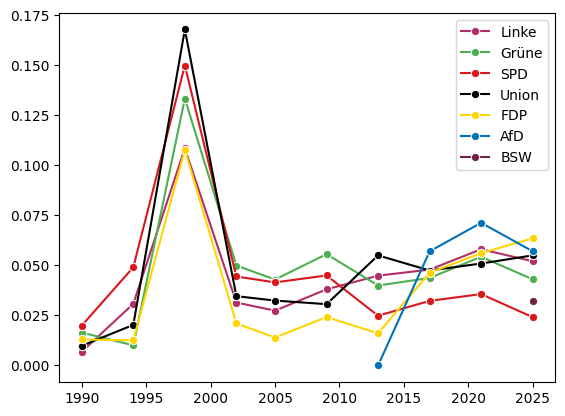

In [ ]:
# looks suspicious!
sns.lineplot(data = rgs_scores, palette = colour_map_parties, markers="o"*7, dashes = False);

In [ ]:
# re-checking the code, we don't find any issues. It rather seems that the model just doesn't fit too well for the data at hand.
# to see this, consider the following predictions:
dfs_rgs[("Grüne", 1998)].query("sentiment == 'negative'")
# a lot of these sentences do not in fact seem negative!

,sentence,sentiment
1,Grün ist der Wechsel,negative
13,Es ist Zeit für einen Wechsel,negative
26,Wir wollen die Erwerbslosigkeit aktiv bekämpfen,negative
31,An den Schlüsselfragen der Zukunft ist das kon...,negative
32,"Die Regierung Kohl hat kein Problem gelöst, ab...",negative
...,...,...
2254,Militär muß für Peace-Keeping-Einsätze umgesch...,negative
2321,Schulden erlassen und die,negative
2324,Für nur wenige Länder hat sich die Verschuldun...,negative
2336,Entwicklungspolitik muß vor Ort ansetzen,negative


#### ParlBERT

#### Zero-shot classification

In [8]:
# model: https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
# sample use:
classifier_mde = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
output_mde = classifier_mde(sequence_to_classify, candidate_labels, multi_label=False)
print(output_mde)

Device set to use mps:0


{'sequence': 'Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU', 'labels': ['politics', 'economy', 'environment', 'entertainment'], 'scores': [0.9658799767494202, 0.022846784442663193, 0.007333978079259396, 0.003939348738640547]}


In [ ]:
sentences_sample = ["Die SPD ist eine Partei.",
                    "Deutschland braucht Migration.",
                    "Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
label_candidates = ["emotive", "factual"]
for sentence in sentences_sample:
    output_mde = classifier_mde(sentence, label_candidates, multi_label=False)
    print(output_mde)
# almost all sentences are classified as emotive/sentiment-driven!

{'sequence': 'Die SPD ist eine Partei.', 'labels': ['factual', 'emotive'], 'scores': [0.5484175682067871, 0.4515824317932129]}
{'sequence': 'Deutschland braucht Migration.', 'labels': ['factual', 'emotive'], 'scores': [0.5075435638427734, 0.49245643615722656]}
{'sequence': 'Politik ist doof.', 'labels': ['emotive', 'factual'], 'scores': [0.8946228623390198, 0.10537713021039963]}
{'sequence': 'Deutschland hat ein Problem.', 'labels': ['emotive', 'factual'], 'scores': [0.7277588844299316, 0.2722410261631012]}
{'sequence': 'Die Wirtschaft schrumpft.', 'labels': ['emotive', 'factual'], 'scores': [0.5705829858779907, 0.4294170141220093]}
{'sequence': 'Den Deutschen geht es gut.', 'labels': ['factual', 'emotive'], 'scores': [0.6196445226669312, 0.38035547733306885]}
{'sequence': 'Den Deutschen geht es zu gut.', 'labels': ['emotive', 'factual'], 'scores': [0.6628593802452087, 0.33714064955711365]}


In [ ]:
classifier_gel = pipeline("zero-shot-classification", model="deepset/gelectra-large")
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
output_gel = classifier_gel(sequence_to_classify, candidate_labels, multi_label=False)
print(output_gel)
# yields the warning: "You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference."

config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at deepset/gelectra-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/240k [00:00<?, ?B/s]

Device set to use mps:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


{'sequence': 'Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU', 'labels': ['entertainment', 'politics', 'economy', 'environment'], 'scores': [0.2526486814022064, 0.2509215474128723, 0.24827973544597626, 0.2481500506401062]}


In [19]:
# https://huggingface.co/joeddav/xlm-roberta-large-xnli
classifier_joe = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
hypothesis_template = "Dieser Text ist {}."# optional
classifier_joe(sequence_to_classify, candidate_labels,
               #hypothesis_template = hypothesis_template # optional
               )

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


{'sequence': 'Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU',
 'labels': ['politics', 'entertainment', 'economy', 'environment'],
 'scores': [0.9683524966239929,
  0.017944177612662315,
  0.007505246438086033,
  0.006198082584887743]}

In [ ]:
sentences_sample = ["Die SPD ist eine Partei.",
                    "Deutschland braucht Migration.",
                    "Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
label_candidates = ["sentiment-driven", "neutral"]
for sentence in sentences_sample:
    output = classifier_joe(sentence, label_candidates, multi_label=False)#, hypothesis_template= )
    print(output)
# trying out different labels; none work particularly well...

{'sequence': 'Die SPD ist eine Partei.', 'labels': ['neutral', 'sentiment-driven'], 'scores': [0.6158009171485901, 0.3841990828514099]}
{'sequence': 'Deutschland braucht Migration.', 'labels': ['sentiment-driven', 'neutral'], 'scores': [0.628051221370697, 0.371948778629303]}
{'sequence': 'Politik ist doof.', 'labels': ['sentiment-driven', 'neutral'], 'scores': [0.7560795545578003, 0.24392040073871613]}
{'sequence': 'Deutschland hat ein Problem.', 'labels': ['sentiment-driven', 'neutral'], 'scores': [0.7439829707145691, 0.2560170292854309]}
{'sequence': 'Die Wirtschaft schrumpft.', 'labels': ['neutral', 'sentiment-driven'], 'scores': [0.5391738414764404, 0.46082615852355957]}
{'sequence': 'Den Deutschen geht es gut.', 'labels': ['sentiment-driven', 'neutral'], 'scores': [0.5222346782684326, 0.477765291929245]}
{'sequence': 'Den Deutschen geht es zu gut.', 'labels': ['neutral', 'sentiment-driven'], 'scores': [0.5376467108726501, 0.46235334873199463]}


In [26]:
from transformers import AutoModelForMaskedLM
tokenizer_gott = AutoTokenizer.from_pretrained("TUM/GottBERT_base_last")
model_gott = AutoModelForMaskedLM.from_pretrained("TUM/GottBERT_base_last")

model.safetensors:   0%|          | 0.00/507M [00:00<?, ?B/s]

Some weights of the model checkpoint at TUM/GottBERT_base_last were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
classifier_gott = pipeline("zero-shot-classification", model=model_gott, tokenizer=tokenizer_gott)
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
classifier_gott(sequence_to_classify, candidate_labels)
# does not work

Device set to use mps:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 24 and the array at index 1 has size 25

In [32]:
classifier_gott_2 = pipeline("text-classification", model=model_gott, tokenizer=tokenizer_gott)
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
classifier_gott_2(sequence_to_classify)
# does not work

Device set to use mps:0
The model 'RobertaForMaskedLM' is not supported for text-classification. Supported models are ['AlbertForSequenceClassification', 'BartForSequenceClassification', 'BertForSequenceClassification', 'BigBirdForSequenceClassification', 'BigBirdPegasusForSequenceClassification', 'BioGptForSequenceClassification', 'BloomForSequenceClassification', 'CamembertForSequenceClassification', 'CanineForSequenceClassification', 'LlamaForSequenceClassification', 'ConvBertForSequenceClassification', 'CTRLForSequenceClassification', 'Data2VecTextForSequenceClassification', 'DebertaForSequenceClassification', 'DebertaV2ForSequenceClassification', 'DiffLlamaForSequenceClassification', 'DistilBertForSequenceClassification', 'ElectraForSequenceClassification', 'ErnieForSequenceClassification', 'ErnieMForSequenceClassification', 'EsmForSequenceClassification', 'FalconForSequenceClassification', 'FlaubertForSequenceClassification', 'FNetForSequenceClassification', 'FunnelForSequenceCla

[{'label': 'LABEL_0', 'score': 1.0}]

In [ ]:
sentences_sample = ["Die SPD ist eine Partei.",
                    "Deutschland braucht Migration.",
                    "Politik ist doof.",
                    "Deutschland hat ein Problem.",
                    "Die Wirtschaft schrumpft.",
                    "Den Deutschen geht es gut.",
                    "Den Deutschen geht es zu gut."]
label_candidates = ["sentiment-driven", "neutral"]
for sentence in sentences_sample:
    output = classifier_joe(sentence, label_candidates, multi_label=False)#, hypothesis_template= )
    print(output)
# trying out different labels; none work particularly well...